# IFRS 9 Expected Credit Loss (ECL) Engine

## Quantitative Credit Risk Modelling Project

### Objective

Build a Python-based Expected Credit Loss engine under IFRS 9 that estimates credit losses using:

- Probability of Default (PD)
- Loss Given Default (LGD)
- Exposure at Default (EAD)
- IFRS 9 Stage 1, Stage 2 and Stage 3 classification
- Forward-looking macroeconomic scenarios
- Probability-weighted expected losses
- Portfolio-level stress testing

### Project Pipeline

Loan Portfolio  
↓  
Data Cleaning  
↓  
Feature Engineering  
↓  
PD Model  
↓  
Credit Risk Assessment  
↓  
IFRS 9 Staging  
↓  
LGD  
↓  
EAD  
↓  
ECL  
↓  
Macroeconomic Scenarios  
↓  
Stress Testing  
↓  
Portfolio Dashboard

# 1. IFRS 9 Conceptual Framework

## What is Expected Credit Loss?

Expected Credit Loss (ECL) is an estimate of credit losses that a financial institution expects to incur on its financial assets.

The model considers:

- Historical information
- Current borrower conditions
- Forecast economic conditions
- Probability of different outcomes
- Time value of money

## Key Credit Risk Variables

### Probability of Default (PD)

The probability that a borrower will default.

### Loss Given Default (LGD)

The percentage of exposure that the institution expects to lose if default occurs.

### Exposure at Default (EAD)

The amount exposed to loss when default occurs.

### Basic Credit Loss Relationship

ECL is conceptually related to:

PD × LGD × EAD

However, the full IFRS 9 framework also considers timing, probability weighting, forward-looking information and discounting.

## IFRS 9 Stages

### Stage 1
Credit risk has not increased significantly since initial recognition.

→ 12-month ECL

### Stage 2
Credit risk has increased significantly since initial recognition.

→ Lifetime ECL

### Stage 3
The financial asset is credit-impaired.

→ Lifetime ECL

In [535]:
# ============================================================
# CELL 3 — IMPORT PYTHON LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [536]:
# ============================================================
# CELL 4 — PROJECT CONFIGURATION
# ============================================================

import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)

print("Project configuration loaded.")
print("Random seed:", RANDOM_STATE)

Project configuration loaded.
Random seed: 42


# 2. Project Assumptions

This project uses a synthetic loan portfolio for borrower-level modelling.

### Why synthetic data?

Real bank-level loan performance data is generally confidential.

Therefore, this project creates a realistic research dataset containing:

- Borrower income
- Loan amount
- Credit score
- Debt-to-income ratio
- Employment history
- Loan term
- Collateral value
- Loan-to-value ratio
- Interest rate
- Sector
- Region
- Initial PD
- Current PD
- Default outcome

Macroeconomic data can later be connected to FRED.

### Important limitation

This project is an educational quantitative research prototype.

It is not a bank's production IFRS 9 accounting system.

# 3. Credit Risk Calculation

For a simple borrower:

Loan Exposure = ₹10,00,000

PD = 5%

LGD = 40%

Simple Expected Loss:

ECL = PD × LGD × EAD

ECL = 5% × 40% × ₹10,00,000

ECL = ₹20,000

The complete project will make this calculation more realistic by adding:

1. IFRS 9 stages
2. 12-month vs lifetime horizons
3. Discounting
4. Macroeconomic scenarios
5. Probability weighting
6. Portfolio aggregation

# 4. Building the Synthetic Loan Portfolio

A real bank would use internal loan-level data.

Because real borrower-level bank data is generally confidential, this project uses a synthetic portfolio for research and education.

Each row will represent one loan.

Each column will represent a characteristic of the borrower or loan.

The portfolio will contain 30,000 simulated loans.v

In [537]:
# ============================================================
# CELL 7 — CREATE SYNTHETIC LOAN PORTFOLIO
# ============================================================

import numpy as np
import pandas as pd

# Number of loans in our simulated bank portfolio
N_LOANS = 30_000

# Random number generator
# Using a fixed seed makes our results reproducible.
rng = np.random.default_rng(42)

print("Creating synthetic loan portfolio...")
print("Number of loans:", N_LOANS)

Creating synthetic loan portfolio...
Number of loans: 30000


In [538]:
# ============================================================
# CELL 8 — BORROWER INCOME
# ============================================================

# Create annual income for each borrower.
# We use a log-normal distribution because income is usually
# positively skewed: most people are around the middle,
# while a smaller number earn substantially more.

income = np.exp(
    rng.normal(
        np.log(65_000),
        0.55,
        N_LOANS
    )
)

# Round income to two decimal places
income = np.round(income, 2)

print("Income data created.")
print("Average income: ₹{:,.0f}".format(income.mean()))
print("Minimum income: ₹{:,.0f}".format(income.min()))
print("Maximum income: ₹{:,.0f}".format(income.max()))

Income data created.
Average income: ₹76,059
Minimum income: ₹5,815
Maximum income: ₹637,510


In [539]:
# ============================================================
# CELL 9 — LOAN AMOUNTS
# ============================================================

# Create loan amounts based partly on borrower income.
# This prevents completely unrealistic combinations such
# as a low-income borrower receiving an enormous loan.

loan_amount = income * rng.uniform(
    0.10,
    0.90,
    N_LOANS
)

# Set reasonable minimum and maximum loan amounts
loan_amount = np.clip(
    loan_amount,
    3_000,
    250_000
)

loan_amount = np.round(
    loan_amount,
    2
)

print("Loan amount data created.")
print("Average loan: ₹{:,.0f}".format(loan_amount.mean()))
print("Minimum loan: ₹{:,.0f}".format(loan_amount.min()))
print("Maximum loan: ₹{:,.0f}".format(loan_amount.max()))

Loan amount data created.
Average loan: ₹38,090
Minimum loan: ₹3,000
Maximum loan: ₹250,000


In [540]:
# ============================================================
# CELL 10 — CREDIT SCORE
# ============================================================

# Generate borrower credit scores.
# Higher scores will generally represent stronger credit quality.

credit_score = rng.normal(
    690,
    55,
    N_LOANS
)

# Keep scores within a reasonable range
credit_score = np.clip(
    credit_score,
    450,
    820
)

credit_score = np.round(
    credit_score
).astype(int)

print("Credit score data created.")
print("Average credit score:", credit_score.mean())
print("Minimum credit score:", credit_score.min())
print("Maximum credit score:", credit_score.max())

Credit score data created.
Average credit score: 689.5876333333333
Minimum credit score: 476
Maximum credit score: 820


In [541]:
# ============================================================
# CELL 11 — DEBT-TO-INCOME RATIO
# ============================================================

# Generate DTI values between approximately 3% and 85%.
# DTI represents the borrower's debt burden relative to income.

dti = rng.beta(
    2.2,
    4.0,
    N_LOANS
) * 0.85

dti = np.clip(
    dti,
    0.03,
    0.85
)

print("DTI data created.")
print("Average DTI: {:.2%}".format(dti.mean()))
print("Minimum DTI: {:.2%}".format(dti.min()))
print("Maximum DTI: {:.2%}".format(dti.max()))

DTI data created.
Average DTI: 30.12%
Minimum DTI: 3.00%
Maximum DTI: 80.54%


In [542]:
# ============================================================
# CELL 12 — EMPLOYMENT HISTORY
# ============================================================

# Generate approximate years of employment.
# Longer employment history can be a useful indicator
# of income stability.

employment_years = rng.gamma(
    2.5,
    2.5,
    N_LOANS
)

employment_years = np.clip(
    employment_years,
    0,
    30
)

employment_years = np.round(
    employment_years,
    1
)

print("Employment history created.")
print(
    "Average employment history: {:.1f} years".format(
        employment_years.mean()
    )
)

Employment history created.
Average employment history: 6.2 years


In [543]:
# ============================================================
# CELL 13 — LOAN TERM
# ============================================================

# Possible loan terms in months
possible_terms = [24, 36, 48, 60, 72]

term_months = rng.choice(
    possible_terms,
    size=N_LOANS,
    p=[0.10, 0.30, 0.25, 0.25, 0.10]
)

print("Loan terms created.")
print()
print(
    pd.Series(term_months)
    .value_counts()
    .sort_index()
)

Loan terms created.

24    2951
36    9066
48    7536
60    7527
72    2920
Name: count, dtype: int64


In [544]:
# ============================================================
# CELL 14 — COLLATERAL VALUE
# ============================================================

# Create collateral values for the loans.
# Collateral provides potential recovery if a borrower defaults.

collateral_value = np.maximum(
    loan_amount / rng.uniform(
        0.45,
        1.10,
        N_LOANS
    ),
    1_000
)

collateral_value = np.round(
    collateral_value,
    2
)

print("Collateral data created.")
print(
    "Average collateral value: ₹{:,.0f}".format(
        collateral_value.mean()
    )
)

Collateral data created.
Average collateral value: ₹52,498


In [545]:
# ============================================================
# CELL 15 — LOAN-TO-VALUE RATIO
# ============================================================

# LTV = Loan Amount / Collateral Value

ltv = loan_amount / collateral_value

# Keep the values within a reasonable modelling range
ltv = np.clip(
    ltv,
    0.05,
    1.50
)

print("LTV calculated.")
print("Average LTV: {:.2%}".format(ltv.mean()))
print("Minimum LTV: {:.2%}".format(ltv.min()))
print("Maximum LTV: {:.2%}".format(ltv.max()))

LTV calculated.
Average LTV: 77.47%
Minimum LTV: 45.00%
Maximum LTV: 110.00%


In [546]:
# ============================================================
# CELL 15 — LOAN-TO-VALUE RATIO
# ============================================================

# LTV = Loan Amount / Collateral Value

ltv = loan_amount / collateral_value

# Keep the values within a reasonable modelling range
ltv = np.clip(
    ltv,
    0.05,
    1.50
)

print("LTV calculated.")
print("Average LTV: {:.2%}".format(ltv.mean()))
print("Minimum LTV: {:.2%}".format(ltv.min()))
print("Maximum LTV: {:.2%}".format(ltv.max()))

LTV calculated.
Average LTV: 77.47%
Minimum LTV: 45.00%
Maximum LTV: 110.00%


In [547]:
# ============================================================
# CELL 16 — INTEREST RATE
# ============================================================

# Create interest rates.
# Riskier borrowers can receive higher rates in this
# simplified research portfolio.

interest_rate = (
    0.045
    + 0.00005 * (700 - credit_score)
    + 0.045 * dti
    + rng.normal(0, 0.006, N_LOANS)
)

interest_rate = np.clip(
    interest_rate,
    0.025,
    0.25
)

print(
    "Average interest rate: {:.2%}".format(
        interest_rate.mean()
    )
)

print(
    "Minimum interest rate: {:.2%}".format(
        interest_rate.min()
    )
)

print(
    "Maximum interest rate: {:.2%}".format(
        interest_rate.max()
    )
)

Average interest rate: 5.91%
Minimum interest rate: 2.62%
Maximum interest rate: 9.49%


In [548]:
# ============================================================
# CELL 17 — BORROWER SECTOR
# ============================================================

sectors = [
    "Manufacturing",
    "Retail",
    "Technology",
    "Healthcare",
    "Services"
]

sector = rng.choice(
    sectors,
    size=N_LOANS
)

print("Sector data created.")
print()

print(
    pd.Series(sector)
    .value_counts()
)

Sector data created.

Retail           6069
Services         6037
Technology       6037
Healthcare       5980
Manufacturing    5877
Name: count, dtype: int64


In [549]:
# ============================================================
# CELL 18 — BORROWER REGION
# ============================================================

regions = [
    "North",
    "South",
    "East",
    "West"
]

region = rng.choice(
    regions,
    size=N_LOANS
)

print("Region data created.")
print()

print(
    pd.Series(region)
    .value_counts()
)

Region data created.

East     7641
South    7500
West     7450
North    7409
Name: count, dtype: int64


In [550]:
# ============================================================
# CELL 19 — LOAN IDENTIFIERS
# ============================================================

loan_id = [
    f"L{str(i).zfill(7)}"
    for i in range(1, N_LOANS + 1)
]

print("Loan IDs created.")
print()

print("First five IDs:")
print(loan_id[:5])

Loan IDs created.

First five IDs:
['L0000001', 'L0000002', 'L0000003', 'L0000004', 'L0000005']


In [551]:
# ============================================================
# CELL 20 — BUILD LOAN PORTFOLIO DATAFRAME
# ============================================================

loans = pd.DataFrame({
    "loan_id": loan_id,
    "income": income,
    "loan_amount": loan_amount,
    "credit_score": credit_score,
    "dti": dti,
    "employment_years": employment_years,
    "term_months": term_months,
    "collateral_value": collateral_value,
    "ltv": ltv,
    "interest_rate": interest_rate,
    "sector": sector,
    "region": region
})

print("Loan portfolio created successfully.")
print()
print("Number of loans:", len(loans))
print("Number of variables:", len(loans.columns))

Loan portfolio created successfully.

Number of loans: 30000
Number of variables: 12


In [552]:
# ============================================================
# CELL 21 — VIEW THE LOAN PORTFOLIO
# ============================================================

display(
    loans.head(10)
)

,loan_id,income,loan_amount,credit_score,dti,employment_years,term_months,collateral_value,ltv,interest_rate,sector,region
0,L0000001,76859.70,65680.72,674,0.097527,2.7,72,87370.41,0.751750,0.042620,Healthcare,South
1,L0000002,36686.03,22233.80,672,0.459361,4.6,36,39837.53,0.558112,0.067974,Healthcare,West
2,L0000003,98212.69,46173.65,653,0.174078,10.0,60,69029.57,0.668897,0.061744,Manufacturing,West
3,L0000004,109038.15,16193.16,730,0.195912,3.8,72,15251.67,1.061730,0.055166,Technology,East
4,L0000005,22227.23,7124.23,590,0.167496,12.8,24,6536.74,1.089875,0.060156,Healthcare,South
5,L0000006,31759.39,26629.91,705,0.399729,20.8,72,29196.84,0.912082,0.063176,Manufacturing,West
6,L0000007,69734.80,39492.02,761,0.549265,10.7,36,71892.62,0.549320,0.062190,Retail,North
7,L0000008,54622.93,20436.72,757,0.400463,7.4,60,39199.98,0.521345,0.050325,Technology,South
8,L0000009,64402.13,19259.68,746,0.200232,1.0,60,39450.88,0.488194,0.036550,Retail,East
9,L0000010,40658.71,7762.79,654,0.361097,7.6,48,12737.54,0.609442,0.062435,Healthcare,East


# 5. Loan Portfolio Variables

| Variable | Meaning |
|---|---|
| loan_id | Unique identifier for each loan |
| income | Borrower's annual income |
| loan_amount | Amount borrowed |
| credit_score | Borrower's credit quality indicator |
| dti | Debt-to-income ratio |
| employment_years | Approximate employment history |
| term_months | Loan duration |
| collateral_value | Estimated collateral value |
| ltv | Loan-to-value ratio |
| interest_rate | Interest rate on the loan |
| sector | Borrower's economic sector |
| region | Borrower's geographic region |

## Credit Risk Intuition

Higher credit score → generally lower risk.

Higher DTI → generally higher repayment pressure.

Higher LTV → generally lower collateral protection.

Higher interest rate → potentially higher repayment burden.

More collateral → potentially lower loss severity.# 5. Loan Portfolio Variables

| Variable | Meaning |
|---|---|
| loan_id | Unique identifier for each loan |
| income | Borrower's annual income |
| loan_amount | Amount borrowed |
| credit_score | Borrower's credit quality indicator |
| dti | Debt-to-income ratio |
| employment_years | Approximate employment history |
| term_months | Loan duration |
| collateral_value | Estimated collateral value |
| ltv | Loan-to-value ratio |
| interest_rate | Interest rate on the loan |
| sector | Borrower's economic sector |
| region | Borrower's geographic region |

## Credit Risk Intuition

Higher credit score → generally lower risk.

Higher DTI → generally higher repayment pressure.

Higher LTV → generally lower collateral protection.

Higher interest rate → potentially higher repayment burden.

More collateral → potentially lower loss severity.

In [553]:
# ============================================================
# CELL 23 — PORTFOLIO SUMMARY
# ============================================================

print("=" * 55)
print("                 PORTFOLIO SUMMARY")
print("=" * 55)

print(
    f"Total loans: {len(loans):,}"
)

print(
    "Total loan exposure: ₹{:,.0f}".format(
        loans["loan_amount"].sum()
    )
)

print(
    "Average loan amount: ₹{:,.0f}".format(
        loans["loan_amount"].mean()
    )
)

print(
    "Average borrower income: ₹{:,.0f}".format(
        loans["income"].mean()
    )
)

print(
    "Average credit score: {:.0f}".format(
        loans["credit_score"].mean()
    )
)

print(
    "Average DTI: {:.2%}".format(
        loans["dti"].mean()
    )
)

print(
    "Average LTV: {:.2%}".format(
        loans["ltv"].mean()
    )
)

print(
    "Average interest rate: {:.2%}".format(
        loans["interest_rate"].mean()
    )
)

                 PORTFOLIO SUMMARY
Total loans: 30,000
Total loan exposure: ₹1,142,698,251
Average loan amount: ₹38,090
Average borrower income: ₹76,059
Average credit score: 690
Average DTI: 30.12%
Average LTV: 77.47%
Average interest rate: 5.91%


In [554]:
# ============================================================
# CELL 24 — SECTOR EXPOSURE
# ============================================================

sector_exposure = (
    loans
    .groupby("sector")
    .agg(
        loans=("loan_id", "count"),
        exposure=("loan_amount", "sum")
    )
    .reset_index()
)

sector_exposure["exposure_share"] = (
    sector_exposure["exposure"]
    / sector_exposure["exposure"].sum()
)

display(
    sector_exposure.style.format({
        "exposure": "₹{:,.0f}",
        "exposure_share": "{:.2%}"
    })
)

,sector,loans,exposure,exposure_share
0,Healthcare,5980,"₹227,086,947",19.87%
1,Manufacturing,5877,"₹224,974,901",19.69%
2,Retail,6069,"₹229,537,195",20.09%
3,Services,6037,"₹230,453,007",20.17%
4,Technology,6037,"₹230,646,202",20.18%


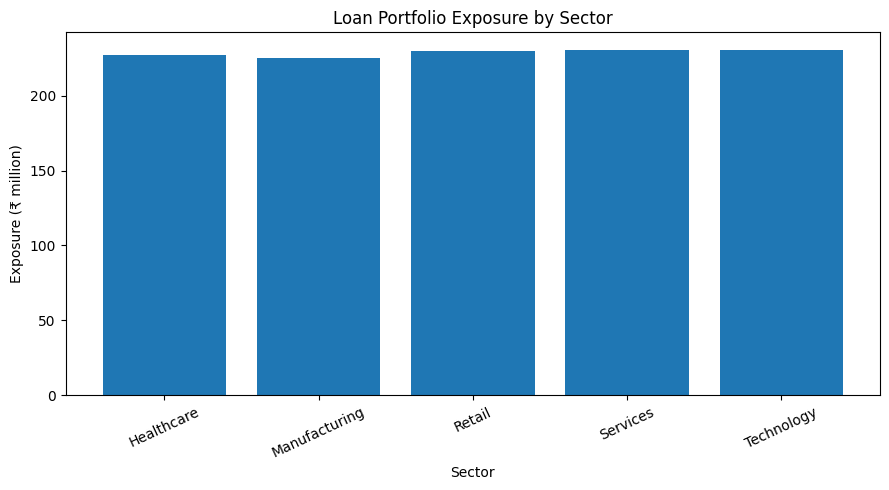

In [555]:
# ============================================================
# CELL 25 — SECTOR EXPOSURE CHART
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    sector_exposure["sector"].astype(str),
    sector_exposure["exposure"] / 1_000_000
)

ax.set_title("Loan Portfolio Exposure by Sector")
ax.set_xlabel("Sector")
ax.set_ylabel("Exposure (₹ million)")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

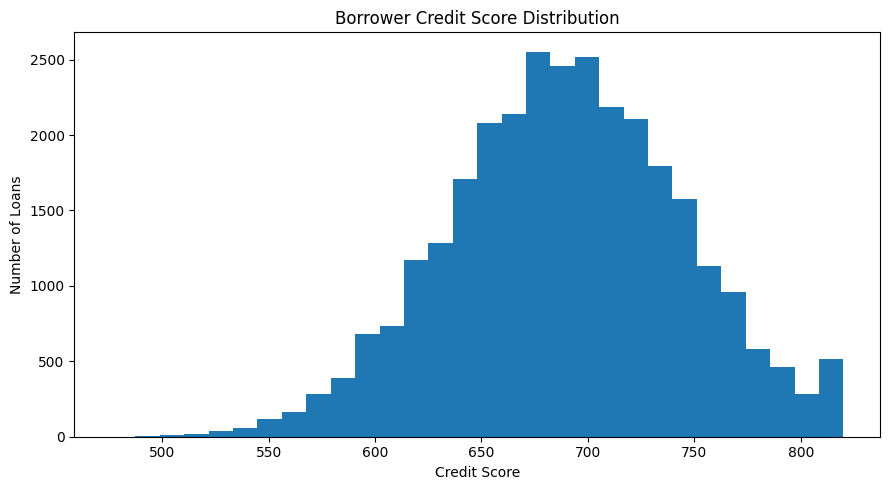

In [556]:
# ============================================================
# CELL 26 — CREDIT SCORE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    loans["credit_score"],
    bins=30
)

ax.set_title("Borrower Credit Score Distribution")
ax.set_xlabel("Credit Score")
ax.set_ylabel("Number of Loans")

plt.tight_layout()
plt.show()

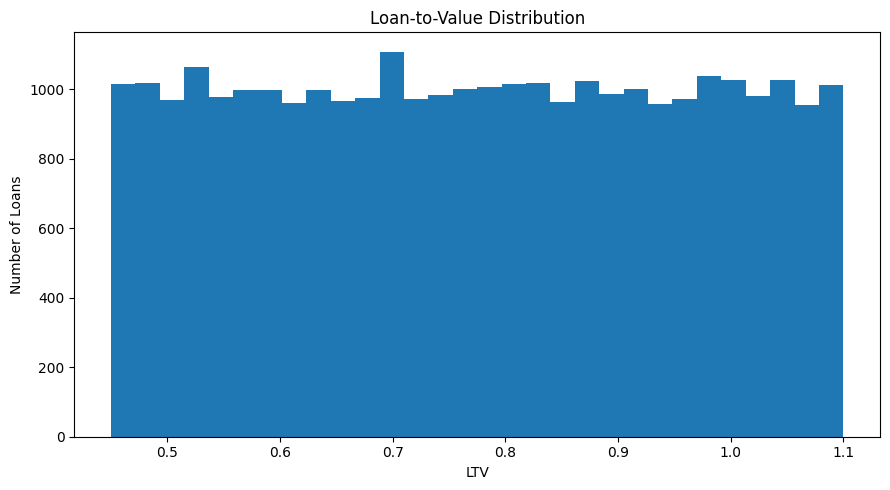

In [557]:
# ============================================================
# CELL 27 — LOAN-TO-VALUE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    loans["ltv"],
    bins=30
)

ax.set_title("Loan-to-Value Distribution")
ax.set_xlabel("LTV")
ax.set_ylabel("Number of Loans")

plt.tight_layout()
plt.show()

In [558]:
# ============================================================
# CELL 28 — SAVE SYNTHETIC LOAN PORTFOLIO
# ============================================================

output_file = "synthetic_loan_portfolio.csv"

loans.to_csv(
    output_file,
    index=False
)

print(
    f"Portfolio saved successfully as: {output_file}"
)

Portfolio saved successfully as: synthetic_loan_portfolio.csv


In [559]:
# ============================================================
# CELL 29 — CREATE SIMULATED DEFAULT PROBABILITY
# ============================================================

# Create an underlying probability of default for each loan.
# This is synthetic data generation, NOT our final PD model.

default_logit = (
    -4.0
    + 0.010 * (680 - credit_score)
    + 2.5 * dti
    + 1.1 * np.maximum(ltv - 0.80, 0)
    - 0.025 * employment_years
    + 0.20 * (interest_rate - 0.10)
)

default_probability = 1 / (
    1 + np.exp(-default_logit)
)

# Keep probabilities within a reasonable range.
default_probability = np.clip(
    default_probability,
    0.001,
    0.50
)

print("Default probabilities created.")
print(
    "Average default probability: {:.2%}".format(
        default_probability.mean()
    )
)
print(
    "Minimum default probability: {:.2%}".format(
        default_probability.min()
    )
)
print(
    "Maximum default probability: {:.2%}".format(
        default_probability.max()
    )
)

Default probabilities created.
Average default probability: 3.85%
Minimum default probability: 0.32%
Maximum default probability: 32.71%


In [560]:
# ============================================================
# CELL 30 — GENERATE DEFAULT OUTCOME
# ============================================================

# Generate one random number between 0 and 1 for each loan.
random_draw = rng.random(N_LOANS)

# A loan defaults when its random draw is below
# its simulated probability of default.
default_12m = (
    random_draw < default_probability
).astype(int)

print("Default outcomes created.")
print()
print("0 = No Default")
print("1 = Default")

Default outcomes created.

0 = No Default
1 = Default


In [561]:
# ============================================================
# CELL 31 — CHECK DEFAULT RATE
# ============================================================

default_rate = default_12m.mean()

number_of_defaults = default_12m.sum()
number_of_non_defaults = (default_12m == 0).sum()

print("=" * 50)
print("DEFAULT RATE ANALYSIS")
print("=" * 50)

print(
    f"Total loans: {N_LOANS:,}"
)

print(
    f"Number of defaults: {number_of_defaults:,}"
)

print(
    f"Number of non-defaults: {number_of_non_defaults:,}"
)

print(
    f"12-month default rate: {default_rate:.2%}"
)

DEFAULT RATE ANALYSIS
Total loans: 30,000
Number of defaults: 1,167
Number of non-defaults: 28,833
12-month default rate: 3.89%


In [562]:
# ============================================================
# CELL 32 — ADD DEFAULT OUTCOME TO PORTFOLIO
# ============================================================

loans["default_12m"] = default_12m

print("Default outcome added to loan portfolio.")
print()

display(
    loans[
        [
            "loan_id",
            "credit_score",
            "dti",
            "ltv",
            "interest_rate",
            "default_12m"
        ]
    ].head(10)
)

Default outcome added to loan portfolio.



,loan_id,credit_score,dti,ltv,interest_rate,default_12m
0,L0000001,674,0.097527,0.751750,0.042620,0
1,L0000002,672,0.459361,0.558112,0.067974,0
2,L0000003,653,0.174078,0.668897,0.061744,0
3,L0000004,730,0.195912,1.061730,0.055166,0
4,L0000005,590,0.167496,1.089875,0.060156,0
5,L0000006,705,0.399729,0.912082,0.063176,0
6,L0000007,761,0.549265,0.549320,0.062190,0
7,L0000008,757,0.400463,0.521345,0.050325,0
8,L0000009,746,0.200232,0.488194,0.036550,0
9,L0000010,654,0.361097,0.609442,0.062435,0


In [563]:
# ============================================================
# CELL 33 — MISSING VALUE CHECK
# ============================================================

missing_values = loans.isnull().sum()

missing_percentage = (
    loans.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing %": missing_percentage
})

display(
    missing_report
    .sort_values(
        "Missing %",
        ascending=False
    )
)

,Missing Values,Missing %
loan_id,0,0.0
income,0,0.0
loan_amount,0,0.0
credit_score,0,0.0
dti,0,0.0
employment_years,0,0.0
term_months,0,0.0
collateral_value,0,0.0
ltv,0,0.0
interest_rate,0,0.0


In [564]:
# ============================================================
# CELL 34 — DUPLICATE LOAN CHECK
# ============================================================

duplicate_count = (
    loans["loan_id"]
    .duplicated()
    .sum()
)

print(
    "Duplicate loan IDs:",
    duplicate_count
)

if duplicate_count == 0:
    print("✓ No duplicate loan IDs found.")
else:
    print("⚠ Duplicate loan IDs detected.")

Duplicate loan IDs: 0
✓ No duplicate loan IDs found.


In [565]:
# ============================================================
# CELL 35 — INVALID VALUE CHECK
# ============================================================

checks = {
    "Negative income":
        (loans["income"] < 0).sum(),

    "Negative loan amount":
        (loans["loan_amount"] < 0).sum(),

    "Credit score below 450":
        (loans["credit_score"] < 450).sum(),

    "Credit score above 820":
        (loans["credit_score"] > 820).sum(),

    "DTI below 0":
        (loans["dti"] < 0).sum(),

    "DTI above 100%":
        (loans["dti"] > 1).sum(),

    "Negative collateral":
        (loans["collateral_value"] < 0).sum(),

    "Negative interest rate":
        (loans["interest_rate"] < 0).sum(),

    "Invalid default value":
        (~loans["default_12m"].isin([0, 1])).sum()
}

validation_report = pd.DataFrame(
    checks.items(),
    columns=[
        "Validation Check",
        "Number of Problems"
    ]
)

display(validation_report)

,Validation Check,Number of Problems
0,Negative income,0
1,Negative loan amount,0
2,Credit score below 450,0
3,Credit score above 820,0
4,DTI below 0,0
5,DTI above 100%,0
6,Negative collateral,0
7,Negative interest rate,0
8,Invalid default value,0


In [566]:
# ============================================================
# CELL 36 — PORTFOLIO STATISTICS
# ============================================================

portfolio_stats = pd.DataFrame({
    "Metric": [
        "Number of Loans",
        "Total Loan Exposure",
        "Average Loan",
        "Average Income",
        "Average Credit Score",
        "Average DTI",
        "Average LTV",
        "Average Interest Rate",
        "12-Month Default Rate"
    ],

    "Value": [
        len(loans),
        loans["loan_amount"].sum(),
        loans["loan_amount"].mean(),
        loans["income"].mean(),
        loans["credit_score"].mean(),
        loans["dti"].mean(),
        loans["ltv"].mean(),
        loans["interest_rate"].mean(),
        loans["default_12m"].mean()
    ]
})

display(portfolio_stats)


,Metric,Value
0,Number of Loans,3.000000e+04
1,Total Loan Exposure,1.142698e+09
2,Average Loan,3.808994e+04
3,Average Income,7.605857e+04
4,Average Credit Score,6.895876e+02
5,Average DTI,3.011824e-01
6,Average LTV,7.747083e-01
7,Average Interest Rate,5.908239e-02
8,12-Month Default Rate,3.890000e-02


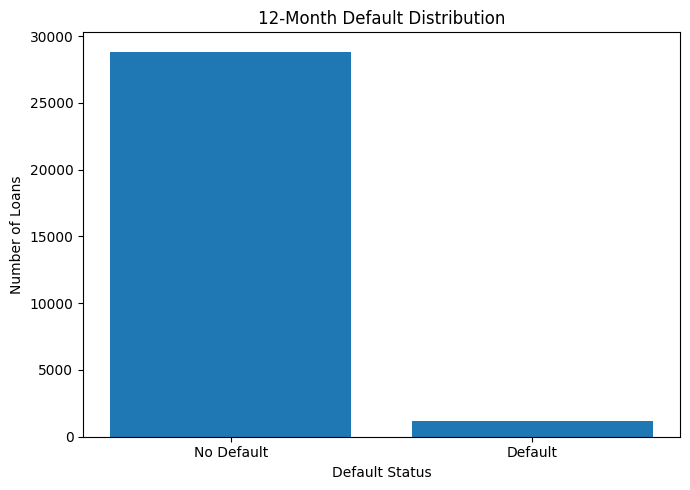

In [567]:
# ============================================================
# CELL 37 — DEFAULT DISTRIBUTION
# ============================================================

default_counts = (
    loans["default_12m"]
    .value_counts()
    .sort_index()
)

labels = [
    "No Default",
    "Default"
]

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    labels,
    default_counts.values
)

ax.set_title(
    "12-Month Default Distribution"
)

ax.set_xlabel(
    "Default Status"
)

ax.set_ylabel(
    "Number of Loans"
)

plt.tight_layout()
plt.show()

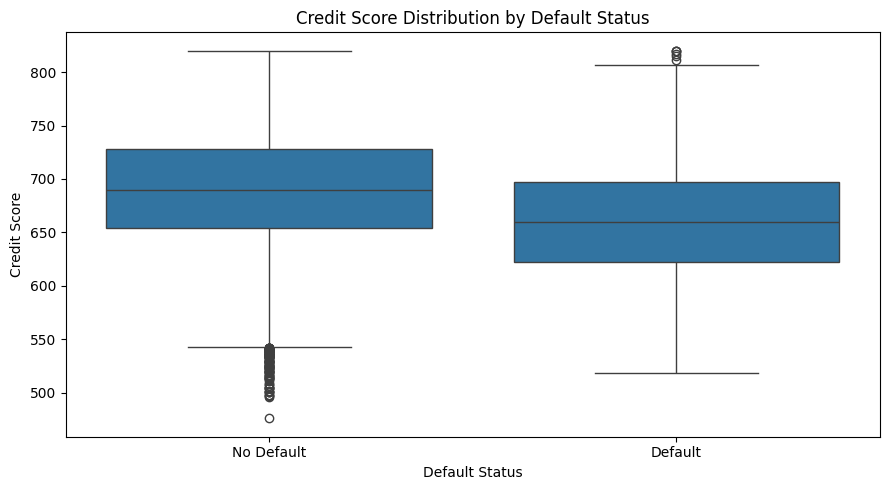

In [568]:
# ============================================================
# CELL 38 — CREDIT SCORE VS DEFAULT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=loans,
    x="default_12m",
    y="credit_score",
    ax=ax
)

ax.set_title(
    "Credit Score Distribution by Default Status"
)

ax.set_xlabel(
    "Default Status"
)

ax.set_ylabel(
    "Credit Score"
)

ax.set_xticklabels([
    "No Default",
    "Default"
])

plt.tight_layout()
plt.show()

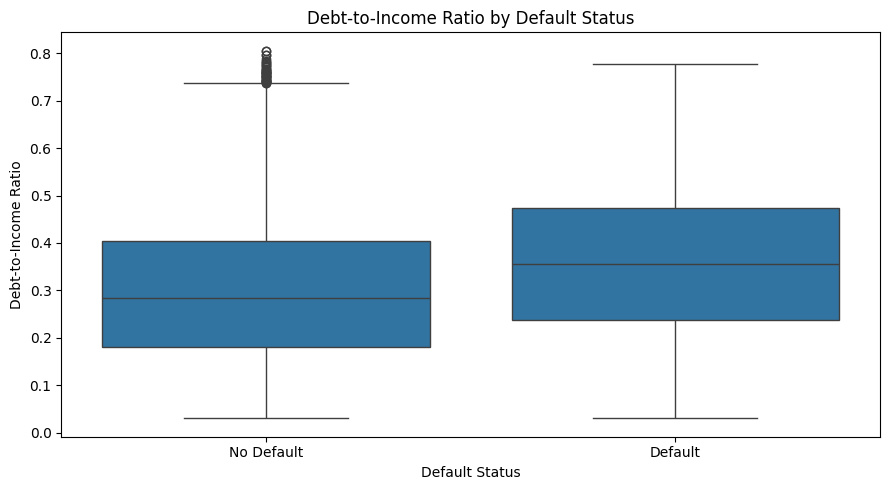

In [569]:
# ============================================================
# CELL 39 — DTI VS DEFAULT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=loans,
    x="default_12m",
    y="dti",
    ax=ax
)

ax.set_title(
    "Debt-to-Income Ratio by Default Status"
)

ax.set_xlabel(
    "Default Status"
)

ax.set_ylabel(
    "Debt-to-Income Ratio"
)

ax.set_xticklabels([
    "No Default",
    "Default"
])

plt.tight_layout()
plt.show()

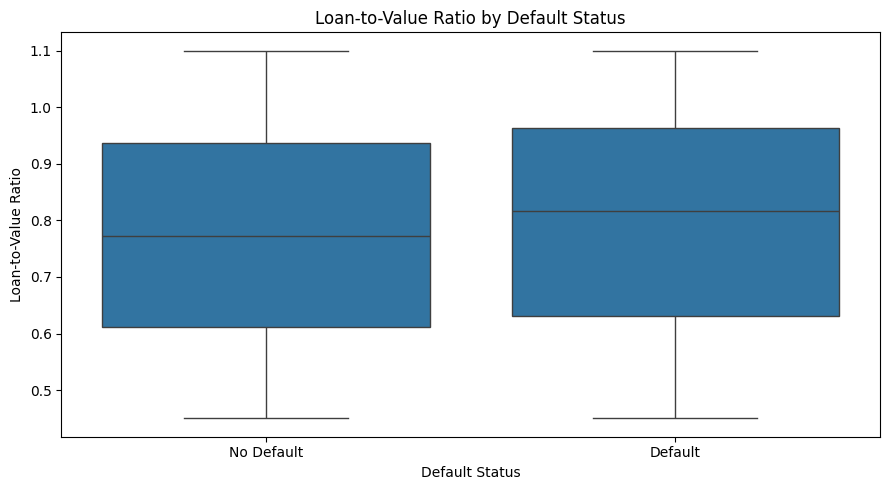

In [570]:
# ============================================================
# CELL 40 — LTV VS DEFAULT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=loans,
    x="default_12m",
    y="ltv",
    ax=ax
)

ax.set_title(
    "Loan-to-Value Ratio by Default Status"
)

ax.set_xlabel(
    "Default Status"
)

ax.set_ylabel(
    "Loan-to-Value Ratio"
)

ax.set_xticklabels([
    "No Default",
    "Default"
])

plt.tight_layout()
plt.show()

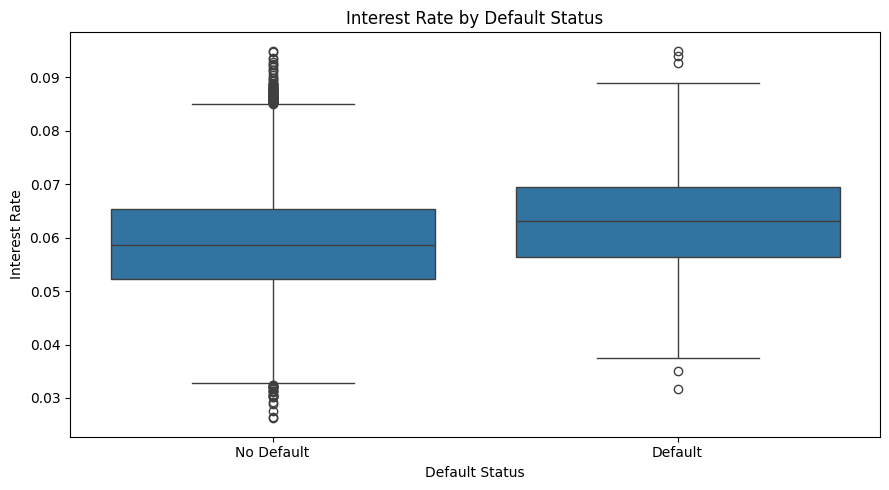

In [571]:
# ============================================================
# CELL 41 — INTEREST RATE VS DEFAULT
# ============================================================

# Check that the required columns exist
required_columns = [
    "default_12m",
    "interest_rate"
]

missing_columns = [
    col for col in required_columns
    if col not in loans.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Create the chart
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=loans,
    x="default_12m",
    y="interest_rate",
    ax=ax
)

ax.set_title(
    "Interest Rate by Default Status"
)

ax.set_xlabel(
    "Default Status"
)

ax.set_ylabel(
    "Interest Rate"
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "No Default",
    "Default"
])

plt.tight_layout()
plt.show()

In [572]:
# ============================================================
# CELL 42 — CREDIT RISK FEATURE ENGINEERING
# ============================================================

# Loan-to-Income:
# Measures loan size relative to annual borrower income.
loans["loan_to_income"] = (
    loans["loan_amount"] /
    loans["income"]
)

# Collateral Coverage:
# Measures collateral available for each unit of loan exposure.
loans["collateral_coverage"] = (
    loans["collateral_value"] /
    loans["loan_amount"]
)

print("New credit-risk features created.")

display(
    loans[
        [
            "loan_amount",
            "income",
            "loan_to_income",
            "collateral_value",
            "collateral_coverage"
        ]
    ].head(10)
)

New credit-risk features created.


,loan_amount,income,loan_to_income,collateral_value,collateral_coverage
0,65680.72,76859.70,0.854553,87370.41,1.330229
1,22233.80,36686.03,0.606056,39837.53,1.791755
2,46173.65,98212.69,0.470139,69029.57,1.494999
3,16193.16,109038.15,0.148509,15251.67,0.941859
4,7124.23,22227.23,0.320518,6536.74,0.917536
5,26629.91,31759.39,0.838489,29196.84,1.096393
6,39492.02,69734.80,0.566317,71892.62,1.820434
7,20436.72,54622.93,0.374142,39199.98,1.918115
8,19259.68,64402.13,0.299053,39450.88,2.048366
9,7762.79,40658.71,0.190926,12737.54,1.640846


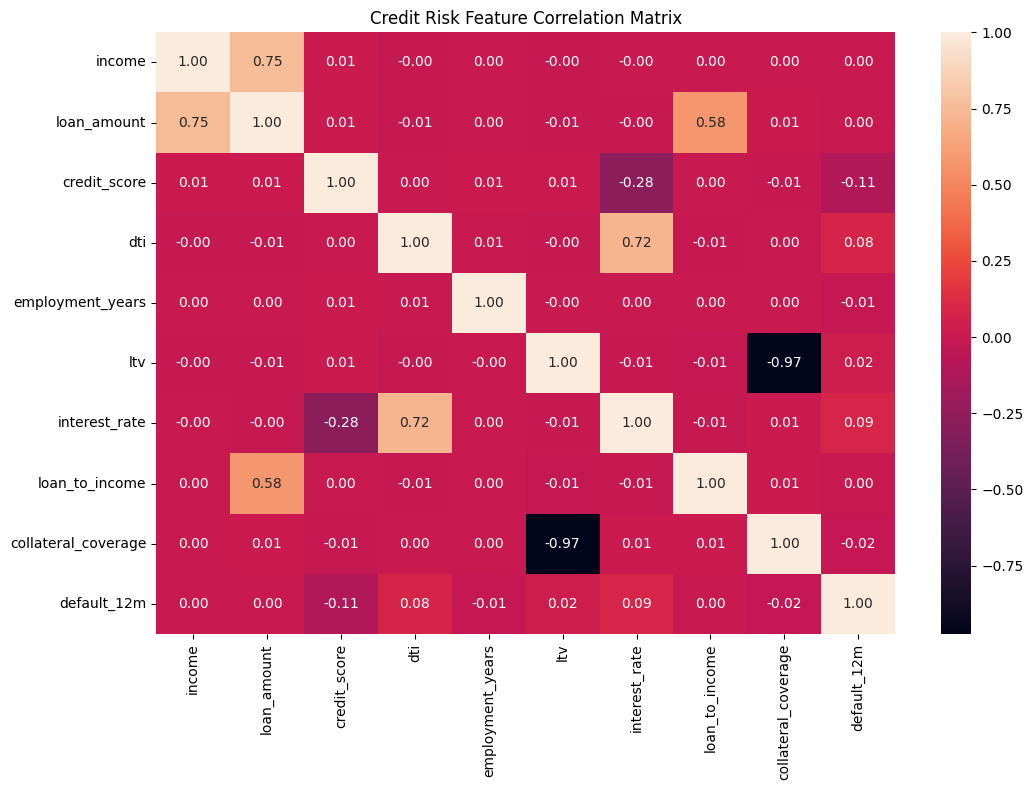

In [573]:
# ============================================================
# CELL 43 — CREDIT RISK CORRELATION MATRIX
# ============================================================

risk_variables = [
    "income",
    "loan_amount",
    "credit_score",
    "dti",
    "employment_years",
    "ltv",
    "interest_rate",
    "loan_to_income",
    "collateral_coverage",
    "default_12m"
]

correlation_matrix = (
    loans[risk_variables]
    .corr()
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    ax=ax
)

ax.set_title(
    "Credit Risk Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [574]:
# ============================================================
# CELL 44 — DEFAULT RATE BY CREDIT SCORE
# ============================================================

loans["credit_score_bucket"] = pd.cut(
    loans["credit_score"],
    bins=[
        0,
        600,
        680,
        740,
        900
    ],
    labels=[
        "Below 600",
        "600–680",
        "680–740",
        "Above 740"
    ]
)

risk_summary = (
    loans
    .groupby(
        "credit_score_bucket",
        observed=False
    )
    .agg(
        loans=("loan_id", "count"),
        average_credit_score=("credit_score", "mean"),
        default_rate=("default_12m", "mean"),
        average_dti=("dti", "mean"),
        average_ltv=("ltv", "mean")
    )
    .reset_index()
)

display(
    risk_summary.style.format({
        "average_credit_score": "{:.0f}",
        "default_rate": "{:.2%}",
        "average_dti": "{:.2%}",
        "average_ltv": "{:.2%}"
    })
)

,credit_score_bucket,loans,average_credit_score,default_rate,average_dti,average_ltv
0,Below 600,1643,578,10.16%,29.78%,77.11%
1,600–680,11364,649,5.20%,30.18%,77.27%
2,680–740,11650,709,2.82%,30.15%,77.63%
3,Above 740,5343,770,1.50%,30.02%,77.66%


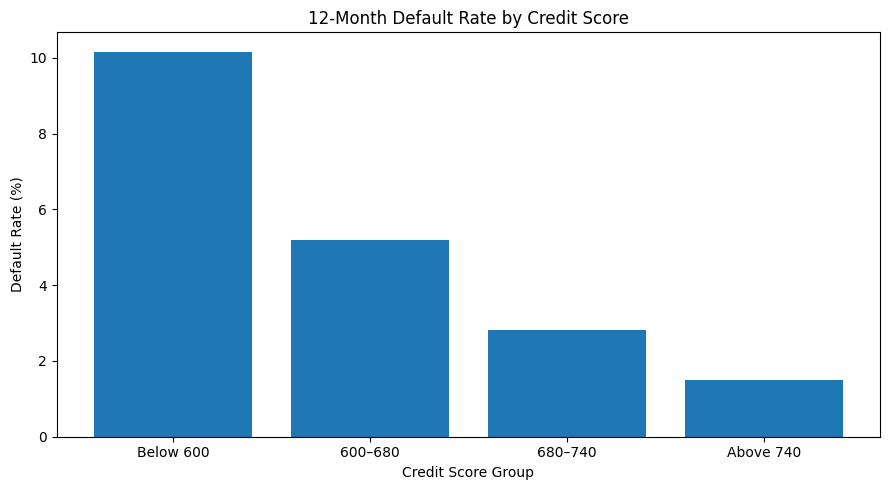

In [575]:
# ============================================================
# CELL 45 — DEFAULT RATE BY CREDIT SCORE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    risk_summary["credit_score_bucket"].astype(str),
    risk_summary["default_rate"] * 100
)

ax.set_title(
    "12-Month Default Rate by Credit Score"
)

ax.set_xlabel(
    "Credit Score Group"
)

ax.set_ylabel(
    "Default Rate (%)"
)

plt.tight_layout()
plt.show()

In [576]:
# ============================================================
# CELL 47 — PREPARE MODELLING DATASET
# ============================================================

# Create a separate dataset for modelling.
model_data = loans.copy()

print("Modelling dataset created.")
print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))

display(model_data.head())

Modelling dataset created.
Rows: 30000
Columns: 16


,loan_id,income,loan_amount,credit_score,dti,employment_years,term_months,collateral_value,ltv,interest_rate,sector,region,default_12m,loan_to_income,collateral_coverage,credit_score_bucket
0,L0000001,76859.70,65680.72,674,0.097527,2.7,72,87370.41,0.751750,0.042620,Healthcare,South,0,0.854553,1.330229,600–680
1,L0000002,36686.03,22233.80,672,0.459361,4.6,36,39837.53,0.558112,0.067974,Healthcare,West,0,0.606056,1.791755,600–680
2,L0000003,98212.69,46173.65,653,0.174078,10.0,60,69029.57,0.668897,0.061744,Manufacturing,West,0,0.470139,1.494999,600–680
3,L0000004,109038.15,16193.16,730,0.195912,3.8,72,15251.67,1.061730,0.055166,Technology,East,0,0.148509,0.941859,680–740
4,L0000005,22227.23,7124.23,590,0.167496,12.8,24,6536.74,1.089875,0.060156,Healthcare,South,0,0.320518,0.917536,Below 600


In [577]:
# ============================================================
# CELL 48 — SELECT MODEL FEATURES
# ============================================================

features = [
    "income",
    "loan_amount",
    "credit_score",
    "dti",
    "employment_years",
    "term_months",
    "ltv",
    "interest_rate",
    "sector",
    "region"
]

target = "default_12m"

X = model_data[features]
y = model_data[target]

print("Features selected:")
print(features)

print()
print("Target variable:")
print(target)

print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Features selected:
['income', 'loan_amount', 'credit_score', 'dti', 'employment_years', 'term_months', 'ltv', 'interest_rate', 'sector', 'region']

Target variable:
default_12m

X shape: (30000, 10)
y shape: (30000,)


In [578]:
# ============================================================
# CELL 49 — TARGET DISTRIBUTION
# ============================================================

target_counts = y.value_counts().sort_index()

print("Target distribution:")
print()

print(
    f"No Default: {target_counts.get(0, 0):,}"
)

print(
    f"Default: {target_counts.get(1, 0):,}"
)

print(
    f"Default Rate: {y.mean():.2%}"
)

Target distribution:

No Default: 28,833
Default: 1,167
Default Rate: 3.89%


In [579]:
# ============================================================
# CELL 50 — TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print()
print(
    "Training default rate: {:.2%}".format(
        y_train.mean()
    )
)

print(
    "Testing default rate: {:.2%}".format(
        y_test.mean()
    )
)

Training observations: 24000
Testing observations: 6000

Training default rate: 3.89%
Testing default rate: 3.88%


In [580]:
# ============================================================
# CELL 51 — PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "income",
    "loan_amount",
    "credit_score",
    "dti",
    "employment_years",
    "term_months",
    "ltv",
    "interest_rate"
]

categorical_features = [
    "sector",
    "region"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [581]:
# ============================================================
# CELL 52 — LOGISTIC REGRESSION PD MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# For a Probability of Default model, we do NOT use
# class_weight="balanced" because we want the predicted
# probabilities to reflect the actual portfolio default rate.

pd_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression PD model created.")

Logistic Regression PD model created.


In [582]:
# ============================================================
# CELL 53 — TRAIN PD MODEL
# ============================================================

print("Training Logistic Regression model...")

pd_model.fit(
    X_train,
    y_train
)

print("Model training completed successfully.")

Training Logistic Regression model...
Model training completed successfully.


In [583]:
# ============================================================
# CELL 54 — GENERATE PD PREDICTIONS
# ============================================================

# Probability of default = probability assigned to class 1.
predicted_pd = pd_model.predict_proba(
    X_test
)[:, 1]

print("PD predictions generated.")

print()
print(
    "Minimum predicted PD: {:.2%}".format(
        predicted_pd.min()
    )
)

print(
    "Average predicted PD: {:.2%}".format(
        predicted_pd.mean()
    )
)

print(
    "Maximum predicted PD: {:.2%}".format(
        predicted_pd.max()
    )
)

PD predictions generated.

Minimum predicted PD: 0.35%
Average predicted PD: 3.86%
Maximum predicted PD: 34.17%


In [584]:
# ============================================================
# CELL 55 — INSPECT PD PREDICTIONS
# ============================================================

pd_results = X_test.copy()

pd_results["actual_default"] = y_test.values

pd_results["predicted_pd"] = predicted_pd

display(
    pd_results[
        [
            "credit_score",
            "dti",
            "ltv",
            "interest_rate",
            "actual_default",
            "predicted_pd"
        ]
    ].head(20)
)

,credit_score,dti,ltv,interest_rate,actual_default,predicted_pd
7536,635,0.415289,0.600975,0.061307,0,0.080804
3751,679,0.057361,0.526315,0.049709,0,0.018640
3066,617,0.206922,0.476504,0.061135,0,0.042411
19010,758,0.373369,0.772635,0.053776,0,0.017750
13607,780,0.247318,0.809766,0.054409,0,0.009404
26247,588,0.370437,0.842925,0.071974,0,0.121823
26886,736,0.175980,0.831262,0.061186,0,0.017164
19241,635,0.205737,0.484895,0.058459,0,0.031385
15047,639,0.281153,0.785036,0.057061,0,0.041084
2880,781,0.273818,0.819724,0.051048,0,0.010335


In [585]:
# ============================================================
# CELL 56 — PREDICTED VS ACTUAL DEFAULT RATE
# ============================================================

actual_default_rate = y_test.mean()
average_predicted_pd = predicted_pd.mean()

comparison = pd.DataFrame({
    "Metric": [
        "Actual Default Rate",
        "Average Predicted PD"
    ],
    "Value": [
        actual_default_rate,
        average_predicted_pd
    ]
})

display(
    comparison.style.format({
        "Value": "{:.2%}"
    })
)

,Metric,Value
0,Actual Default Rate,3.88%
1,Average Predicted PD,3.86%


In [586]:
# ============================================================
# CELL 57 — SAVE PD MODEL RESULTS
# ============================================================

pd_results.to_csv(
    "pd_model_test_predictions.csv",
    index=False
)

print(
    "PD predictions saved successfully."
)

PD predictions saved successfully.


In [587]:
# ============================================================
# CELL 58 — IMPORT MODEL VALIDATION TOOLS
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Model validation tools imported successfully.")

Model validation tools imported successfully.


In [588]:
# ============================================================
# CELL 59 — ROC-AUC
# ============================================================

roc_auc = roc_auc_score(
    y_test,
    predicted_pd
)

print(
    "ROC-AUC: {:.4f}".format(
        roc_auc
    )
)

ROC-AUC: 0.6912


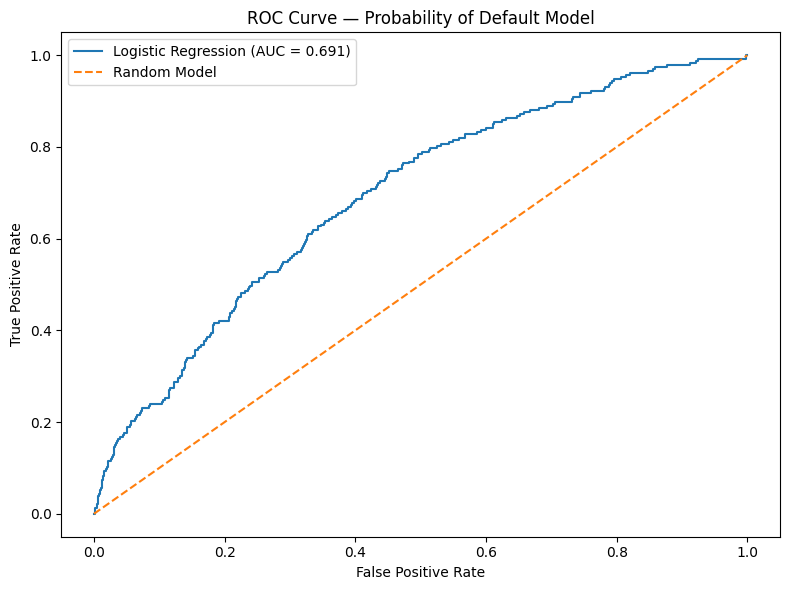

In [589]:
# ============================================================
# CELL 60 — ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    predicted_pd
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

ax.set_title(
    "ROC Curve — Probability of Default Model"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend()

plt.tight_layout()
plt.show()

In [590]:
# ============================================================
# CELL 61 — GINI COEFFICIENT
# ============================================================

gini = (
    2 * roc_auc
) - 1

print(
    "ROC-AUC: {:.4f}".format(
        roc_auc
    )
)

print(
    "Gini Coefficient: {:.4f}".format(
        gini
    )
)

ROC-AUC: 0.6912
Gini Coefficient: 0.3825


KS Statistic: 0.2947
KS Percentage: 29.47%


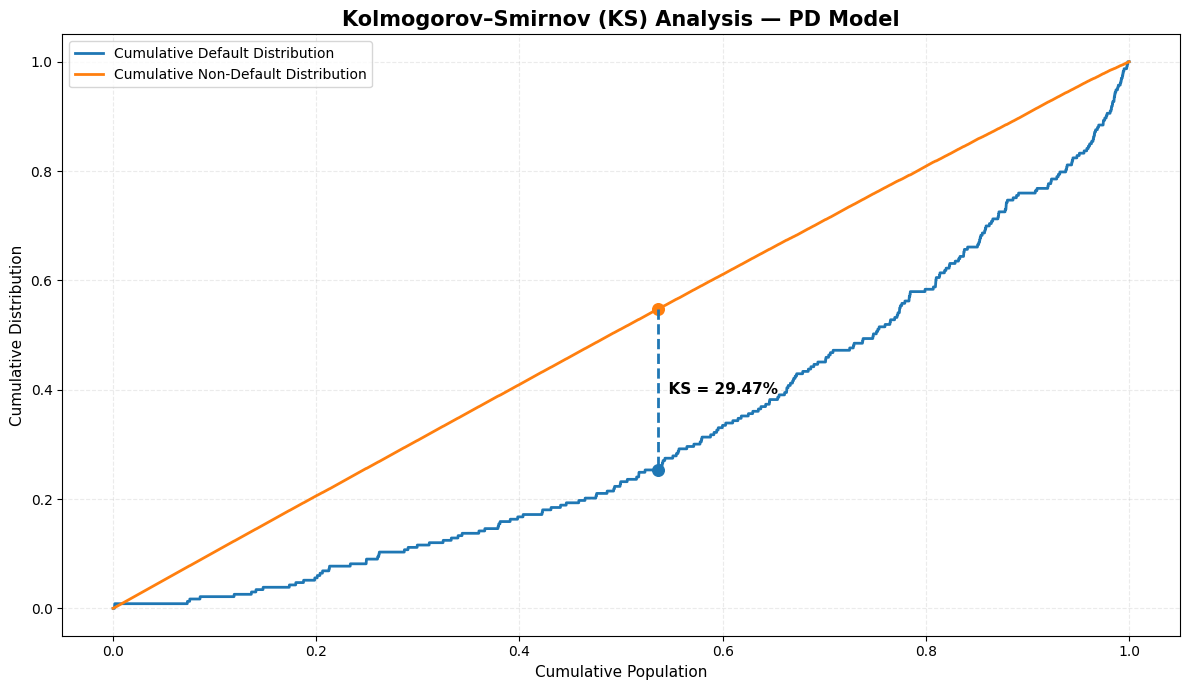

In [591]:
# ============================================================
# CELL 62 — KS STATISTIC & PD SEPARATION
# ============================================================

# Sort observations by predicted PD
ks_data = pd.DataFrame({
    "actual": y_test.values,
    "predicted_pd": predicted_pd
}).sort_values("predicted_pd")

# Cumulative distributions
total_defaults = ks_data["actual"].sum()
total_non_defaults = len(ks_data) - total_defaults

ks_data["cum_default"] = (
    ks_data["actual"].cumsum() / total_defaults
)

ks_data["cum_non_default"] = (
    ((1 - ks_data["actual"]).cumsum()) / total_non_defaults
)

# KS distance
ks_data["ks_distance"] = (
    ks_data["cum_default"] -
    ks_data["cum_non_default"]
)

ks_statistic = ks_data["ks_distance"].abs().max()
ks_percentage = ks_statistic * 100

print(f"KS Statistic: {ks_statistic:.4f}")
print(f"KS Percentage: {ks_percentage:.2f}%")

# ------------------------------------------------------------
# KS VISUALIZATION
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    np.arange(1, len(ks_data) + 1) / len(ks_data),
    ks_data["cum_default"],
    label="Cumulative Default Distribution",
    linewidth=2
)

ax.plot(
    np.arange(1, len(ks_data) + 1) / len(ks_data),
    ks_data["cum_non_default"],
    label="Cumulative Non-Default Distribution",
    linewidth=2
)

# Locate KS point
ks_index = ks_data["ks_distance"].abs().idxmax()

ks_x = (
    ks_data.index.get_loc(ks_index) + 1
) / len(ks_data)

ks_default_y = ks_data.loc[
    ks_index, "cum_default"
]

ks_non_default_y = ks_data.loc[
    ks_index, "cum_non_default"
]

# Draw KS separation
ax.vlines(
    ks_x,
    ks_non_default_y,
    ks_default_y,
    linestyle="--",
    linewidth=2
)

ax.scatter(
    [ks_x],
    [ks_default_y],
    s=70
)

ax.scatter(
    [ks_x],
    [ks_non_default_y],
    s=70
)

ax.text(
    ks_x,
    (ks_default_y + ks_non_default_y) / 2,
    f"  KS = {ks_percentage:.2f}%",
    va="center",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Kolmogorov–Smirnov (KS) Analysis — PD Model",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Cumulative Population",
    fontsize=11
)

ax.set_ylabel(
    "Cumulative Distribution",
    fontsize=11
)

ax.legend()

ax.grid(
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()
plt.show()

Classification threshold: 5.00%



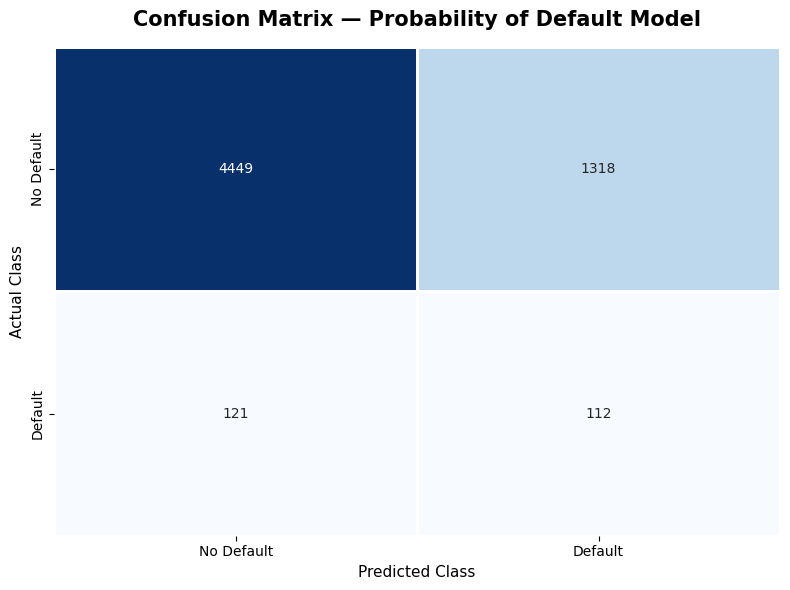

Model Classification Summary
-----------------------------------
True Negatives : 4,449
False Positives: 1,318
False Negatives: 121
True Positives : 112


In [592]:
# ============================================================
# CELL 63 — CONFUSION MATRIX VISUALIZATION
# ============================================================

classification_threshold = 0.05

predicted_default = (
    predicted_pd >= classification_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    predicted_default
)

print(f"Classification threshold: {classification_threshold:.2%}")
print()

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="white",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],
    ax=ax
)

ax.set_title(
    "Confusion Matrix — Probability of Default Model",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=11
)

ax.set_ylabel(
    "Actual Class",
    fontsize=11
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

tn, fp, fn, tp = cm.ravel()

print("Model Classification Summary")
print("-" * 35)
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives : {tp:,}")

Precision: 7.83%
Recall: 48.07%
F1 Score: 13.47%


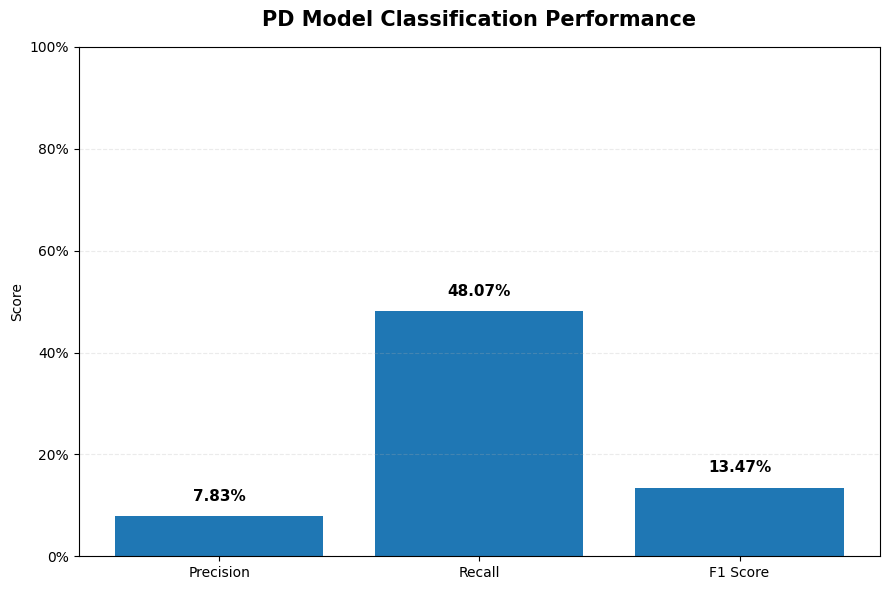

In [593]:
# ============================================================
# CELL 64 — PRECISION, RECALL & F1 SCORE
# ============================================================

report = classification_report(
    y_test,
    predicted_default,
    target_names=[
        "No Default",
        "Default"
    ],
    output_dict=True,
    zero_division=0
)

precision = report["Default"]["precision"]
recall = report["Default"]["recall"]
f1_score = report["Default"]["f1-score"]

print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1_score:.2%}")

# ------------------------------------------------------------
# MODEL PERFORMANCE VISUALIZATION
# ------------------------------------------------------------

metrics = {
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_score
}

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    metrics.keys(),
    metrics.values()
)

ax.set_title(
    "PD Model Classification Performance",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

# Add values above bars
for bar, value in zip(bars, metrics.values()):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [594]:
# ============================================================
# CELL 65 — BRIER SCORE
# ============================================================

brier_score = brier_score_loss(
    y_test,
    predicted_pd
)

print(
    "Brier Score: {:.6f}".format(
        brier_score
    )
)

Brier Score: 0.036578


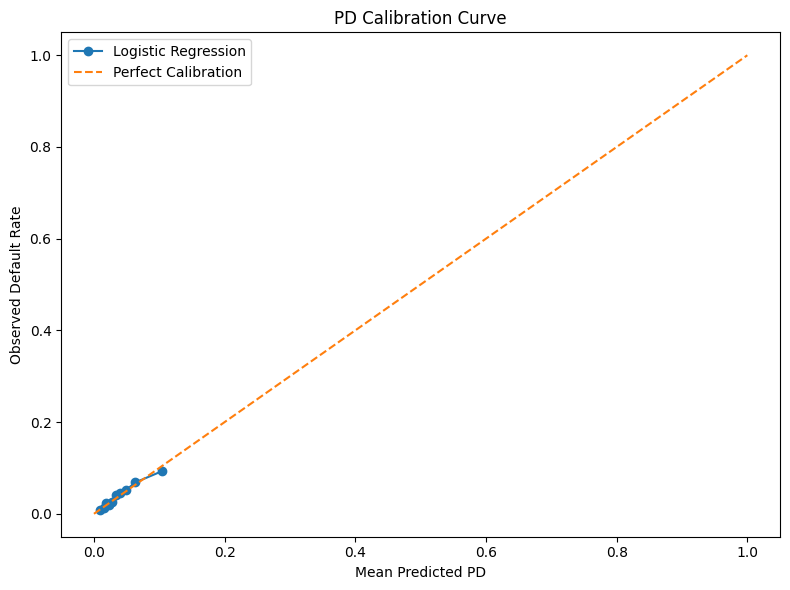

In [595]:
# ============================================================
# CELL 66 — PD CALIBRATION CURVE
# ============================================================

prob_true, prob_pred = calibration_curve(
    y_test,
    predicted_pd,
    n_bins=10,
    strategy="quantile"
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

ax.set_title(
    "PD Calibration Curve"
)

ax.set_xlabel(
    "Mean Predicted PD"
)

ax.set_ylabel(
    "Observed Default Rate"
)

ax.legend()

plt.tight_layout()
plt.show()

In [596]:
# ============================================================
# CELL 67 — PREDICTED VS ACTUAL DEFAULT RATE
# ============================================================

actual_default_rate = y_test.mean()

average_predicted_pd = predicted_pd.mean()

comparison = pd.DataFrame({
    "Metric": [
        "Actual Default Rate",
        "Average Predicted PD",
        "Difference"
    ],
    "Value": [
        actual_default_rate,
        average_predicted_pd,
        average_predicted_pd - actual_default_rate
    ]
})

display(
    comparison.style.format({
        "Value": "{:.2%}"
    })
)

,Metric,Value
0,Actual Default Rate,3.88%
1,Average Predicted PD,3.86%
2,Difference,-0.02%


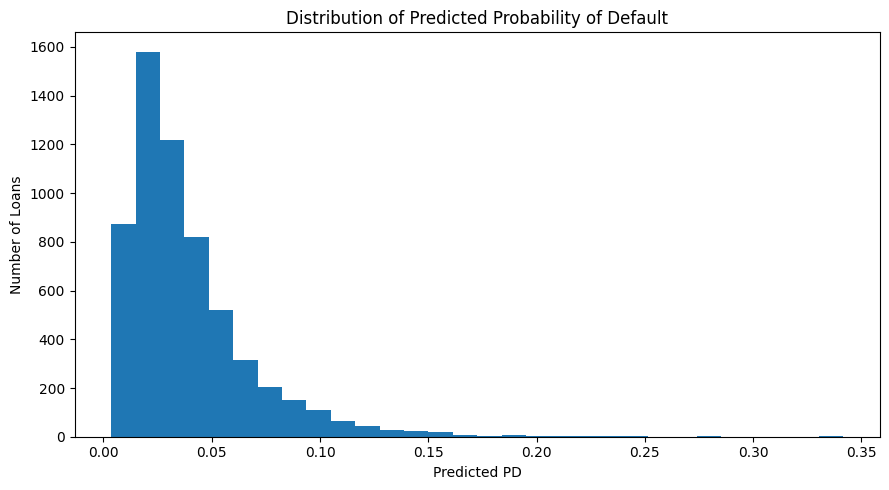

In [597]:
# ============================================================
# CELL 68 — PREDICTED PD DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.hist(
    predicted_pd,
    bins=30
)

ax.set_title(
    "Distribution of Predicted Probability of Default"
)

ax.set_xlabel(
    "Predicted PD"
)

ax.set_ylabel(
    "Number of Loans"
)

plt.tight_layout()
plt.show()

In [598]:
# ============================================================
# CELL 69 — FINAL PD MODEL VALIDATION SCORECARD
# ============================================================

validation_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Gini Coefficient",
        "KS Statistic",
        "Brier Score",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [
        roc_auc,
        gini,
        ks_statistic,
        brier_score,
        precision,
        recall,
        f1_score
    ]
})

# ------------------------------------------------------------
# FORMAT VALUES
# ------------------------------------------------------------

formatted_summary = validation_summary.copy()

formatted_summary["Value"] = formatted_summary["Value"].map(
    lambda x: f"{x:.4f}"
)

# ------------------------------------------------------------
# DISPLAY SCORECARD
# ------------------------------------------------------------

styled_summary = (
    formatted_summary
    .style
    .set_caption("PD Model Validation Scorecard")
    .set_properties(
        **{
            "font-size": "12pt",
            "text-align": "center",
            "padding": "8px"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16pt"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "10px 0px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        }
    ])
)

display(styled_summary)

# ------------------------------------------------------------
# KEY MODEL RESULTS
# ------------------------------------------------------------

print()
print("Key PD Model Results")
print("-" * 35)
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"Gini    : {gini:.4f}")
print(f"KS      : {ks_statistic:.4f}")
print(f"Brier   : {brier_score:.4f}")

,Metric,Value
0,ROC-AUC,0.6912
1,Gini Coefficient,0.3825
2,KS Statistic,0.2947
3,Brier Score,0.0366
4,Precision,0.0783
5,Recall,0.4807
6,F1 Score,0.1347



Key PD Model Results
-----------------------------------
ROC-AUC : 0.6912
Gini    : 0.3825
KS      : 0.2947
Brier   : 0.0366


In [599]:
# ============================================================
# CELL 70 — SAVE PD MODEL VALIDATION RESULTS
# ============================================================

validation_summary.to_csv(
    "pd_model_validation_metrics.csv",
    index=False
)

print(
    "PD model validation results saved successfully."
)

PD model validation results saved successfully.


In [600]:
# ============================================================
# CELL 71 — CREATE INITIAL PD PROXY
# ============================================================

# In a real IFRS 9 model, initial PD would come from the
# borrower's credit-risk assessment at initial recognition.
#
# Our dataset is synthetic and does not contain historical
# origination PDs, so we create an educational proxy.
#
# The multiplier is deliberately wide enough to create both
# stable and deteriorated credit-risk profiles.

initial_pd = (
    predicted_pd *
    rng.uniform(
        0.45,
        0.85,
        len(predicted_pd)
    )
)

# Keep PD within a sensible range.
initial_pd = np.clip(
    initial_pd,
    0.001,
    0.50
)

print("Initial PD proxy created.")

print(
    "Average initial PD: {:.2%}".format(
        initial_pd.mean()
    )
)

print(
    "Average current PD: {:.2%}".format(
        predicted_pd.mean()
    )
)

Initial PD proxy created.
Average initial PD: 2.50%
Average current PD: 3.86%


In [601]:
# ============================================================
# CELL 72 — CALCULATE PD DETERIORATION
# ============================================================

pd_change_absolute = (
    predicted_pd - initial_pd
)

pd_change_relative = (
    predicted_pd / initial_pd
) - 1

print("PD deterioration calculated.")

print(
    "Average absolute PD change: {:.2%}".format(
        pd_change_absolute.mean()
    )
)

print(
    "Average relative PD change: {:.2%}".format(
        pd_change_relative.mean()
    )
)

PD deterioration calculated.
Average absolute PD change: 1.35%
Average relative PD change: 59.48%


In [602]:
# ============================================================
# CELL 73 — CREATE STAGING DATASET
# ============================================================

staging_data = X_test.copy()

staging_data["actual_default"] = y_test.values

staging_data["initial_pd"] = initial_pd

staging_data["current_pd"] = predicted_pd

staging_data["pd_change_absolute"] = (
    pd_change_absolute
)

staging_data["pd_change_relative"] = (
    pd_change_relative
)

print("Staging dataset created.")

display(
    staging_data.head(10)
)

Staging dataset created.


,income,loan_amount,credit_score,dti,employment_years,term_months,ltv,interest_rate,sector,region,actual_default,initial_pd,current_pd,pd_change_absolute,pd_change_relative
7536,360890.51,207352.18,635,0.415289,4.8,60,0.600975,0.061307,Retail,East,0,0.049337,0.080804,0.031467,0.637793
3751,45919.44,30342.79,679,0.057361,3.6,36,0.526315,0.049709,Manufacturing,West,0,0.013708,0.018640,0.004931,0.359734
3066,74847.89,64601.10,617,0.206922,0.8,48,0.476504,0.061135,Services,South,0,0.023172,0.042411,0.019239,0.830233
19010,64673.71,30591.09,758,0.373369,7.2,36,0.772635,0.053776,Retail,East,0,0.013275,0.017750,0.004475,0.337084
13607,109888.71,44122.14,780,0.247318,15.3,36,0.809766,0.054409,Retail,East,0,0.004653,0.009404,0.004751,1.021063
26247,71047.40,59084.69,588,0.370437,6.0,36,0.842925,0.071974,Manufacturing,East,0,0.065675,0.121823,0.056148,0.854940
26886,120020.27,94789.16,736,0.175980,7.8,72,0.831262,0.061186,Healthcare,East,0,0.010807,0.017164,0.006357,0.588187
19241,70227.59,53518.15,635,0.205737,1.1,36,0.484895,0.058459,Services,West,0,0.025867,0.031385,0.005519,0.213351
15047,72294.99,20694.90,639,0.281153,4.2,36,0.785036,0.057061,Services,East,0,0.021575,0.041084,0.019509,0.904251
2880,76896.19,51528.49,781,0.273818,10.1,36,0.819724,0.051048,Technology,South,0,0.006323,0.010335,0.004011,0.634368


In [603]:
# ============================================================
# CELL 74 — SICR PROXY
# ============================================================

staging_data["sicr_flag"] = (
    staging_data["pd_change_relative"] >= 1.0
).astype(int)

print(
    "SICR proxy flag created."
)

print()
print(
    "Loans flagged for significant credit deterioration:",
    staging_data["sicr_flag"].sum()
)

print(
    "Percentage flagged: {:.2%}".format(
        staging_data["sicr_flag"].mean()
    )
)

SICR proxy flag created.

Loans flagged for significant credit deterioration: 797
Percentage flagged: 13.28%


In [604]:
# ============================================================
# CELL 75 — CREDIT-IMPAIRED FLAG
# ============================================================

staging_data["credit_impaired"] = (
    staging_data["actual_default"] == 1
).astype(int)

print(
    "Credit-impaired proxy created."
)

print(
    "Credit-impaired loans:",
    staging_data["credit_impaired"].sum()
)

Credit-impaired proxy created.
Credit-impaired loans: 233


In [605]:
# ============================================================
# CELL 76 — IFRS 9 STAGE CLASSIFICATION
# ============================================================

def assign_stage(row):

    # Stage 3:
    # Credit-impaired / defaulted loans
    if row["credit_impaired"] == 1:
        return 3

    # Stage 2:
    # Significant increase in credit risk
    elif row["sicr_flag"] == 1:
        return 2

    # Stage 1:
    # No significant increase in credit risk
    else:
        return 1


staging_data["ifrs9_stage"] = (
    staging_data.apply(
        assign_stage,
        axis=1
    )
)

print("IFRS 9 stage classification completed.")

display(
    staging_data[
        [
            "initial_pd",
            "current_pd",
            "pd_change_relative",
            "sicr_flag",
            "credit_impaired",
            "ifrs9_stage"
        ]
    ].head(15)
)

IFRS 9 stage classification completed.


,initial_pd,current_pd,pd_change_relative,sicr_flag,credit_impaired,ifrs9_stage
7536,0.049337,0.080804,0.637793,0,0,1
3751,0.013708,0.018640,0.359734,0,0,1
3066,0.023172,0.042411,0.830233,0,0,1
19010,0.013275,0.017750,0.337084,0,0,1
13607,0.004653,0.009404,1.021063,1,0,2
26247,0.065675,0.121823,0.854940,0,0,1
26886,0.010807,0.017164,0.588187,0,0,1
19241,0.025867,0.031385,0.213351,0,0,1
15047,0.021575,0.041084,0.904251,0,0,1
2880,0.006323,0.010335,0.634368,0,0,1


In [606]:
# ============================================================
# CELL 77 — STAGE DISTRIBUTION
# ============================================================

stage_distribution = (
    staging_data["ifrs9_stage"]
    .value_counts()
    .sort_index()
)

stage_summary = pd.DataFrame({
    "Stage": [
        "Stage 1",
        "Stage 2",
        "Stage 3"
    ],

    "Number of Loans": [
        stage_distribution.get(1, 0),
        stage_distribution.get(2, 0),
        stage_distribution.get(3, 0)
    ]
})

stage_summary["Portfolio Share"] = (
    stage_summary["Number of Loans"]
    / len(staging_data)
)

display(
    stage_summary.style.format({
        "Portfolio Share": "{:.2%}"
    })
)

,Stage,Number of Loans,Portfolio Share
0,Stage 1,4998,83.30%
1,Stage 2,769,12.82%
2,Stage 3,233,3.88%


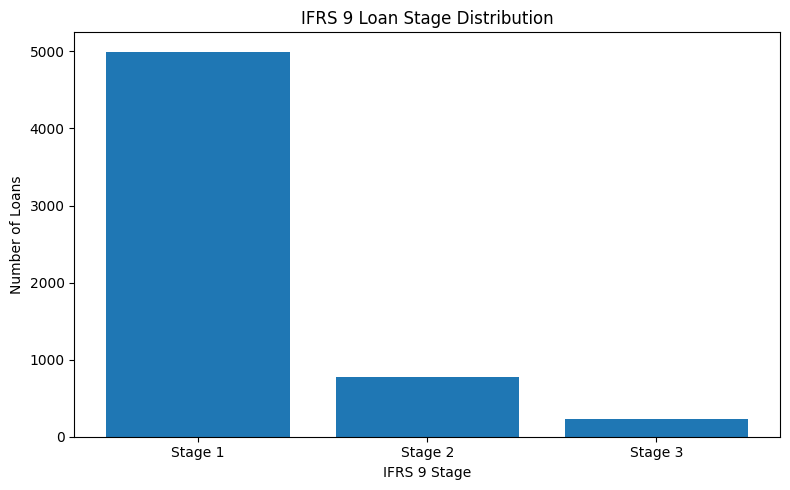

In [607]:
# ============================================================
# CELL 78 — IFRS 9 STAGE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    stage_summary["Stage"],
    stage_summary["Number of Loans"]
)

ax.set_title(
    "IFRS 9 Loan Stage Distribution"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Number of Loans"
)

plt.tight_layout()
plt.show()

In [608]:
# ============================================================
# CELL 79 — DEFAULT RATE BY IFRS 9 STAGE
# ============================================================

stage_default_analysis = (
    staging_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("actual_default", "count"),
        default_rate=("actual_default", "mean"),
        average_initial_pd=("initial_pd", "mean"),
        average_current_pd=("current_pd", "mean")
    )
    .reset_index()
)

display(
    stage_default_analysis.style.format({
        "default_rate": "{:.2%}",
        "average_initial_pd": "{:.2%}",
        "average_current_pd": "{:.2%}"
    })
)

,ifrs9_stage,loans,default_rate,average_initial_pd,average_current_pd
0,1,4998,0.00%,2.56%,3.79%
1,2,769,0.00%,1.76%,3.70%
2,3,233,100.00%,3.80%,5.89%


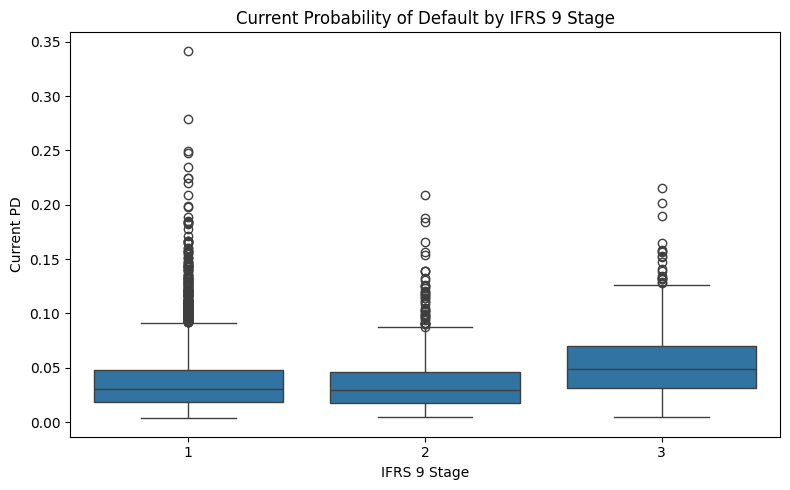

In [609]:
# ============================================================
# CELL 80 — CURRENT PD BY IFRS 9 STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=staging_data,
    x="ifrs9_stage",
    y="current_pd",
    ax=ax
)

ax.set_title(
    "Current Probability of Default by IFRS 9 Stage"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Current PD"
)

plt.tight_layout()
plt.show()

In [610]:
# ============================================================
# CELL 81 — ADD LOAN EXPOSURE TO STAGING DATA
# ============================================================

staging_data["loan_amount"] = (
    loans.loc[
        X_test.index,
        "loan_amount"
    ].values
)

print("Loan exposure added to staging dataset.")

display(
    staging_data[
        [
            "loan_amount",
            "initial_pd",
            "current_pd",
            "ifrs9_stage"
        ]
    ].head(10)
)# ============================================================
# CELL 81 — ADD LOAN EXPOSURE TO STAGING DATA
# ============================================================

staging_data["loan_amount"] = (
    loans.loc[
        X_test.index,
        "loan_amount"
    ].values
)

print("Loan exposure added to staging dataset.")

display(
    staging_data[
        [
            "loan_amount",
            "initial_pd",
            "current_pd",
            "ifrs9_stage"
        ]
    ].head(10)
)

Loan exposure added to staging dataset.


,loan_amount,initial_pd,current_pd,ifrs9_stage
7536,207352.18,0.049337,0.080804,1
3751,30342.79,0.013708,0.018640,1
3066,64601.10,0.023172,0.042411,1
19010,30591.09,0.013275,0.017750,1
13607,44122.14,0.004653,0.009404,2
26247,59084.69,0.065675,0.121823,1
26886,94789.16,0.010807,0.017164,1
19241,53518.15,0.025867,0.031385,1
15047,20694.90,0.021575,0.041084,1
2880,51528.49,0.006323,0.010335,1


Loan exposure added to staging dataset.


,loan_amount,initial_pd,current_pd,ifrs9_stage
7536,207352.18,0.049337,0.080804,1
3751,30342.79,0.013708,0.018640,1
3066,64601.10,0.023172,0.042411,1
19010,30591.09,0.013275,0.017750,1
13607,44122.14,0.004653,0.009404,2
26247,59084.69,0.065675,0.121823,1
26886,94789.16,0.010807,0.017164,1
19241,53518.15,0.025867,0.031385,1
15047,20694.90,0.021575,0.041084,1
2880,51528.49,0.006323,0.010335,1


In [611]:
# ============================================================
# DIAGNOSTIC — CHECK IFRS 9 STAGE COUNTS
# ============================================================

print(
    staging_data["ifrs9_stage"]
    .value_counts()
    .sort_index()
)

print("\nCredit-impaired loans:")
print(
    staging_data["credit_impaired"].value_counts()
)


ifrs9_stage
1    4998
2     769
3     233
Name: count, dtype: int64

Credit-impaired loans:
credit_impaired
0    5767
1     233
Name: count, dtype: int64


In [612]:
# ============================================================
# CELL 82 — EXPOSURE BY IFRS 9 STAGE
# ============================================================

stage_exposure = (
    staging_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("loan_amount", "count"),
        exposure=("loan_amount", "sum"),
        average_exposure=("loan_amount", "mean")
    )
    .reset_index()
)

display(
    stage_exposure.style.format({
        "exposure": "₹{:,.0f}",
        "average_exposure": "₹{:,.0f}"
    })
)

,ifrs9_stage,loans,exposure,average_exposure
0,1,4998,"₹192,915,674","₹38,599"
1,2,769,"₹30,511,032","₹39,676"
2,3,233,"₹8,486,405","₹36,422"


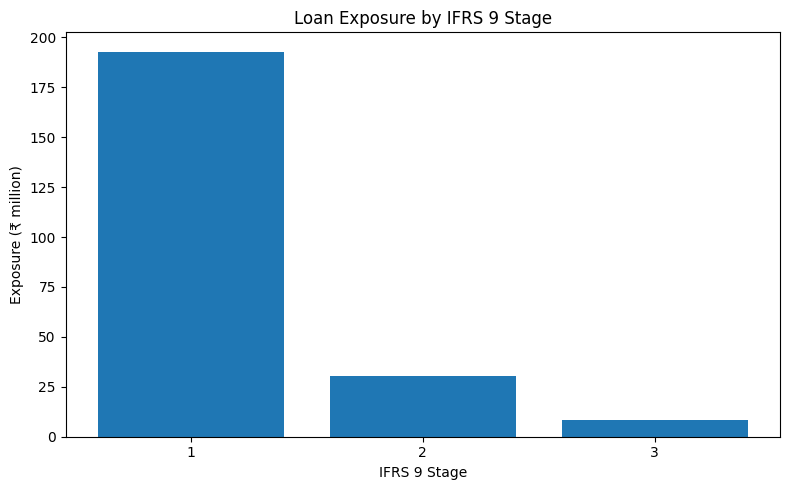

In [613]:
# ============================================================
# CELL 83 — EXPOSURE BY IFRS 9 STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    stage_exposure["ifrs9_stage"].astype(str),
    stage_exposure["exposure"] / 1_000_000
)

ax.set_title(
    "Loan Exposure by IFRS 9 Stage"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Exposure (₹ million)"
)

plt.tight_layout()
plt.show()

In [614]:
# ============================================================
# CELL 84 — IFRS 9 STAGE SUMMARY
# ============================================================

stage_final_summary = (
    staging_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("loan_amount", "count"),
        exposure=("loan_amount", "sum"),
        average_pd=("current_pd", "mean"),
        default_rate=("actual_default", "mean")
    )
    .reset_index()
)

# Calculate the percentage of total portfolio exposure
stage_final_summary["exposure_share"] = (
    stage_final_summary["exposure"]
    / staging_data["loan_amount"].sum()
)

display(
    stage_final_summary.style.format({
        "exposure": "₹{:,.0f}",
        "average_pd": "{:.2%}",
        "default_rate": "{:.2%}",
        "exposure_share": "{:.2%}"
    })
)

,ifrs9_stage,loans,exposure,average_pd,default_rate,exposure_share
0,1,4998,"₹192,915,674",3.79%,0.00%,83.18%
1,2,769,"₹30,511,032",3.70%,0.00%,13.16%
2,3,233,"₹8,486,405",5.89%,100.00%,3.66%


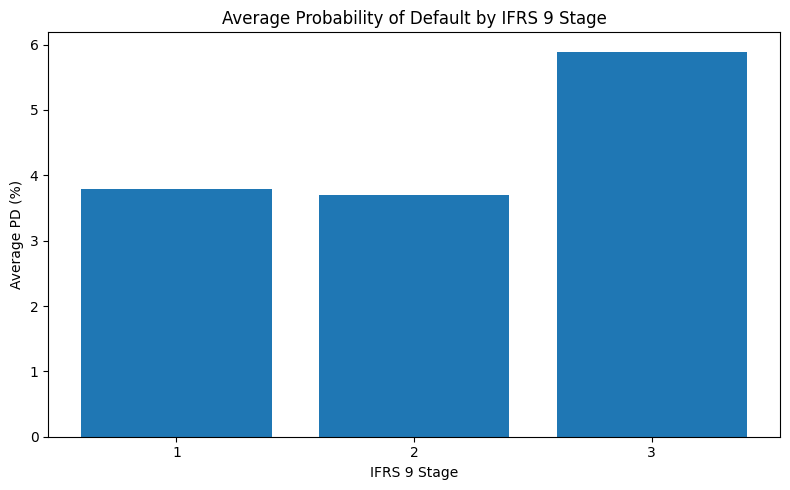

In [615]:
# ============================================================
# CELL 85 — AVERAGE PD BY IFRS 9 STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    stage_final_summary["ifrs9_stage"].astype(str),
    stage_final_summary["average_pd"] * 100
)

ax.set_title(
    "Average Probability of Default by IFRS 9 Stage"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Average PD (%)"
)

plt.tight_layout()
plt.show()

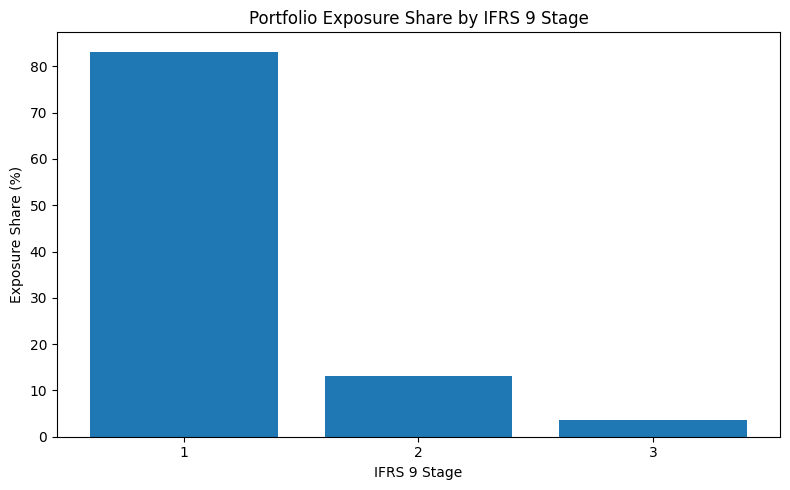

In [616]:
# ============================================================
# CELL 86 — PORTFOLIO EXPOSURE SHARE BY STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    stage_final_summary["ifrs9_stage"].astype(str),
    stage_final_summary["exposure_share"] * 100
)

ax.set_title(
    "Portfolio Exposure Share by IFRS 9 Stage"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Exposure Share (%)"
)

plt.tight_layout()
plt.show()

In [617]:
# ============================================================
# CELL 87 — SAVE IFRS 9 STAGING DATA
# ============================================================

staging_data.to_csv(
    "ifrs9_stage_classification.csv",
    index=False
)

stage_final_summary.to_csv(
    "ifrs9_stage_summary.csv",
    index=False
)

print("IFRS 9 staging datasets saved successfully.")

print(
    f"Loans saved: {len(staging_data):,}"
)

print(
    f"Columns saved: {len(staging_data.columns)}"
)

IFRS 9 staging datasets saved successfully.
Loans saved: 6,000
Columns saved: 18


In [618]:
# ============================================================
# CELL 88 — STAGING VALIDATION CHECK
# ============================================================

print("=" * 60)
print("IFRS 9 STAGING VALIDATION")
print("=" * 60)

# Check that every loan has exactly one stage
missing_stage = staging_data["ifrs9_stage"].isna().sum()

# Check that only stages 1, 2 and 3 exist
invalid_stage = (
    ~staging_data["ifrs9_stage"].isin([1, 2, 3])
).sum()

# Check that Stage 3 loans are credit-impaired
stage_3_without_impairment = (
    (
        staging_data["ifrs9_stage"] == 3
    )
    &
    (
        staging_data["credit_impaired"] != 1
    )
).sum()

print(
    f"Loans without a stage: {missing_stage}"
)

print(
    f"Invalid stage values: {invalid_stage}"
)

print(
    f"Stage 3 loans without credit-impaired flag: "
    f"{stage_3_without_impairment}"
)

if (
    missing_stage == 0
    and invalid_stage == 0
    and stage_3_without_impairment == 0
):
    print()
    print("✓ Staging validation passed.")
else:
    print()
    print("⚠ Staging validation requires review.")

IFRS 9 STAGING VALIDATION
Loans without a stage: 0
Invalid stage values: 0
Stage 3 loans without credit-impaired flag: 0

✓ Staging validation passed.


In [619]:
# ============================================================
# CELL 89 — PREPARE LGD DATASET
# ============================================================

# Create a copy of the existing staging dataset.
lgd_data = staging_data.copy()

# Add collateral information from the original loan portfolio.
lgd_data["collateral_value"] = (
    loans.loc[
        X_test.index,
        "collateral_value"
    ].values
)

print("LGD dataset created successfully.")

display(
    lgd_data[
        [
            "loan_amount",
            "collateral_value",
            "ltv",
            "actual_default",
            "ifrs9_stage"
        ]
    ].head(10)
)

LGD dataset created successfully.


,loan_amount,collateral_value,ltv,actual_default,ifrs9_stage
7536,207352.18,345026.33,0.600975,0,1
3751,30342.79,57651.41,0.526315,0,1
3066,64601.10,135573.04,0.476504,0,1
19010,30591.09,39593.21,0.772635,0,1
13607,44122.14,54487.52,0.809766,0,2
26247,59084.69,70094.82,0.842925,0,1
26886,94789.16,114030.40,0.831262,0,1
19241,53518.15,110370.57,0.484895,0,1
15047,20694.90,26361.73,0.785036,0,1
2880,51528.49,62860.78,0.819724,0,1


In [620]:
# ============================================================
# CHECK IFRS 9 STAGES IN LGD DATASET
# ============================================================

print("IFRS 9 Stage distribution in LGD dataset:")
print(
    lgd_data["ifrs9_stage"]
    .value_counts()
    .sort_index()
)

print("\nStage 3 loans:")
print(
    lgd_data[
        lgd_data["ifrs9_stage"] == 3
    ][
        [
            "loan_amount",
            "collateral_value",
            "ltv",
            "actual_default",
            "ifrs9_stage"
        ]
    ].head(10)
)

IFRS 9 Stage distribution in LGD dataset:
ifrs9_stage
1    4998
2     769
3     233
Name: count, dtype: int64

Stage 3 loans:
       loan_amount  collateral_value       ltv  actual_default  ifrs9_stage
3723      19616.54          30406.47  0.645144               1            3
24615     58696.10          74722.79  0.785518               1            3
5003      16725.46          32147.06  0.520280               1            3
21760     23359.67          21452.63  1.088895               1            3
28267     19852.93          21356.77  0.929585               1            3
6006      15129.74          16304.10  0.927971               1            3
619       30486.68          63971.99  0.476563               1            3
28839     78359.63          79112.62  0.990482               1            3
8364      11283.17          17504.34  0.644593               1            3
2631      33630.79          49691.27  0.676795               1            3


In [621]:
# ============================================================
# CELL 90 — CALCULATE NET COLLATERAL VALUE
# ============================================================

# Recovery haircut represents costs and losses during
# collateral liquidation.
#
# We use a 25% haircut for this educational model.
# This is a modelling assumption, NOT an IFRS 9 requirement.

collateral_haircut = 0.25

lgd_data["net_collateral_value"] = (
    lgd_data["collateral_value"]
    * (1 - collateral_haircut)
)

print(
    f"Collateral haircut assumed: {collateral_haircut:.0%}"
)

display(
    lgd_data[
        [
            "loan_amount",
            "collateral_value",
            "net_collateral_value"
        ]
    ].head(10)
)

Collateral haircut assumed: 25%


,loan_amount,collateral_value,net_collateral_value
7536,207352.18,345026.33,258769.7475
3751,30342.79,57651.41,43238.5575
3066,64601.10,135573.04,101679.7800
19010,30591.09,39593.21,29694.9075
13607,44122.14,54487.52,40865.6400
26247,59084.69,70094.82,52571.1150
26886,94789.16,114030.40,85522.8000
19241,53518.15,110370.57,82777.9275
15047,20694.90,26361.73,19771.2975
2880,51528.49,62860.78,47145.5850


In [622]:
# ============================================================
# CELL 91 — CALCULATE RECOVERY RATE
# ============================================================

lgd_data["recovery_rate"] = (
    lgd_data["net_collateral_value"]
    / lgd_data["loan_amount"]
)

# Recovery cannot exceed 100%.
lgd_data["recovery_rate"] = np.clip(
    lgd_data["recovery_rate"],
    0,
    1
)

print("Recovery rates calculated successfully.")

print(
    "Average recovery rate: {:.2%}".format(
        lgd_data["recovery_rate"].mean()
    )
)

display(
    lgd_data[
        [
            "loan_amount",
            "net_collateral_value",
            "recovery_rate"
        ]
    ].head(10)
)

Recovery rates calculated successfully.
Average recovery rate: 90.45%


,loan_amount,net_collateral_value,recovery_rate
7536,207352.18,258769.7475,1.000000
3751,30342.79,43238.5575,1.000000
3066,64601.10,101679.7800,1.000000
19010,30591.09,29694.9075,0.970704
13607,44122.14,40865.6400,0.926194
26247,59084.69,52571.1150,0.889759
26886,94789.16,85522.8000,0.902242
19241,53518.15,82777.9275,1.000000
15047,20694.90,19771.2975,0.955371
2880,51528.49,47145.5850,0.914942


In [623]:
# ============================================================
# CELL 92 — CALCULATE LOSS GIVEN DEFAULT
# ============================================================

lgd_data["lgd"] = (
    1 - lgd_data["recovery_rate"]
)

# Keep LGD between 0% and 100%.
lgd_data["lgd"] = np.clip(
    lgd_data["lgd"],
    0,
    1
)

print("LGD calculated successfully.")

print(
    "Average LGD: {:.2%}".format(
        lgd_data["lgd"].mean()
    )
)

print(
    "Minimum LGD: {:.2%}".format(
        lgd_data["lgd"].min()
    )
)

print(
    "Maximum LGD: {:.2%}".format(
        lgd_data["lgd"].max()
    )
)

LGD calculated successfully.
Average LGD: 9.55%
Minimum LGD: 0.00%
Maximum LGD: 31.81%


In [624]:
# ============================================================
# CELL 93 — DEFAULTED LOAN LGD ANALYSIS
# ============================================================

defaulted_loans = lgd_data[
    lgd_data["actual_default"] == 1
].copy()

print(
    "Number of defaulted loans:",
    len(defaulted_loans)
)

print(
    "Average LGD for defaulted loans: {:.2%}".format(
        defaulted_loans["lgd"].mean()
    )
)

print(
    "Average recovery rate for defaulted loans: {:.2%}".format(
        defaulted_loans["recovery_rate"].mean()
    )
)

Number of defaulted loans: 233
Average LGD for defaulted loans: 11.08%
Average recovery rate for defaulted loans: 88.92%


In [625]:
# ============================================================
# CELL 94 — LGD BY LTV BUCKET
# ============================================================

defaulted_loans["ltv_bucket"] = pd.cut(
    defaulted_loans["ltv"],
    bins=[
        0,
        0.60,
        0.80,
        1.00,
        1.20,
        1.50
    ],
    labels=[
        "≤60%",
        "60–80%",
        "80–100%",
        "100–120%",
        ">120%"
    ],
    include_lowest=True
)

lgd_by_ltv = (
    defaulted_loans
    .groupby(
        "ltv_bucket",
        observed=False
    )
    .agg(
        loans=("loan_amount", "count"),
        average_lgd=("lgd", "mean"),
        average_recovery=("recovery_rate", "mean"),
        average_loan=("loan_amount", "mean")
    )
    .reset_index()
)

display(
    lgd_by_ltv.style.format({
        "average_lgd": "{:.2%}",
        "average_recovery": "{:.2%}",
        "average_loan": "₹{:,.0f}"
    })
)

,ltv_bucket,loans,average_lgd,average_recovery,average_loan
0,≤60%,50,0.00%,100.00%,"₹38,197"
1,60–80%,55,0.51%,99.49%,"₹42,064"
2,80–100%,94,16.65%,83.35%,"₹34,180"
3,100–120%,34,29.04%,70.96%,"₹30,886"
4,>120%,0,nan%,nan%,₹nan


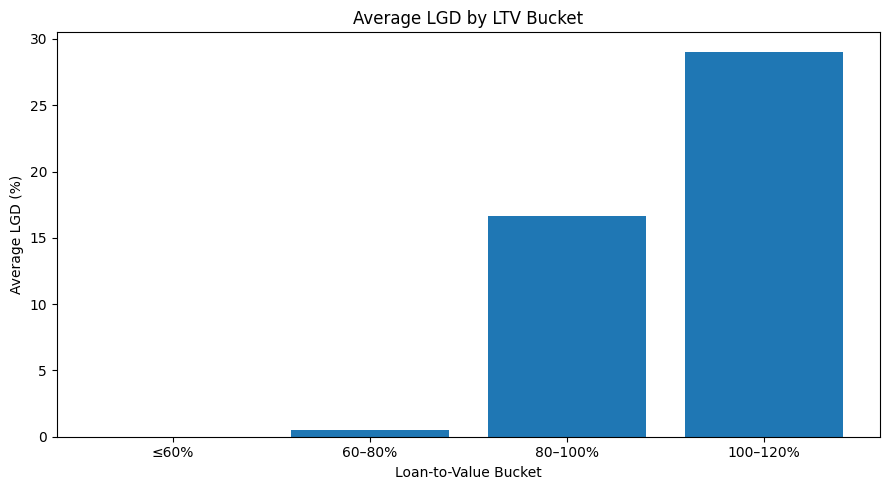

In [626]:
# ============================================================
# CELL 95 — LGD BY LTV BUCKET
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    lgd_by_ltv["ltv_bucket"].astype(str),
    lgd_by_ltv["average_lgd"] * 100
)

ax.set_title(
    "Average LGD by LTV Bucket"
)

ax.set_xlabel(
    "Loan-to-Value Bucket"
)

ax.set_ylabel(
    "Average LGD (%)"
)

plt.tight_layout()
plt.show()

In [627]:
# ============================================================
# CELL 96 — LGD BY IFRS 9 STAGE
# ============================================================

lgd_by_stage = (
    defaulted_loans
    .groupby("ifrs9_stage", as_index=False)
    .agg(
        defaulted_loans=("loan_amount", "count"),
        average_lgd=("lgd", "mean"),
        average_recovery=("recovery_rate", "mean"),
        exposure=("loan_amount", "sum")
    )
)

display(
    lgd_by_stage.style.format({
        "average_lgd": "{:.2%}",
        "average_recovery": "{:.2%}",
        "exposure": "₹{:,.0f}"
    })
)

,ifrs9_stage,defaulted_loans,average_lgd,average_recovery,exposure
0,3,233,11.08%,88.92%,"₹8,486,405"


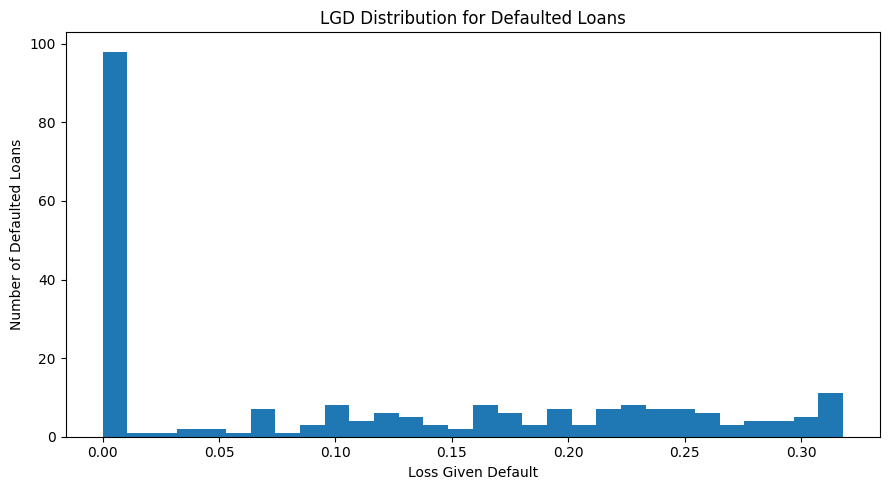

In [628]:
# ============================================================
# CELL 97 — LGD DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    defaulted_loans["lgd"],
    bins=30
)

ax.set_title(
    "LGD Distribution for Defaulted Loans"
)

ax.set_xlabel(
    "Loss Given Default"
)

ax.set_ylabel(
    "Number of Defaulted Loans"
)

plt.tight_layout()
plt.show()

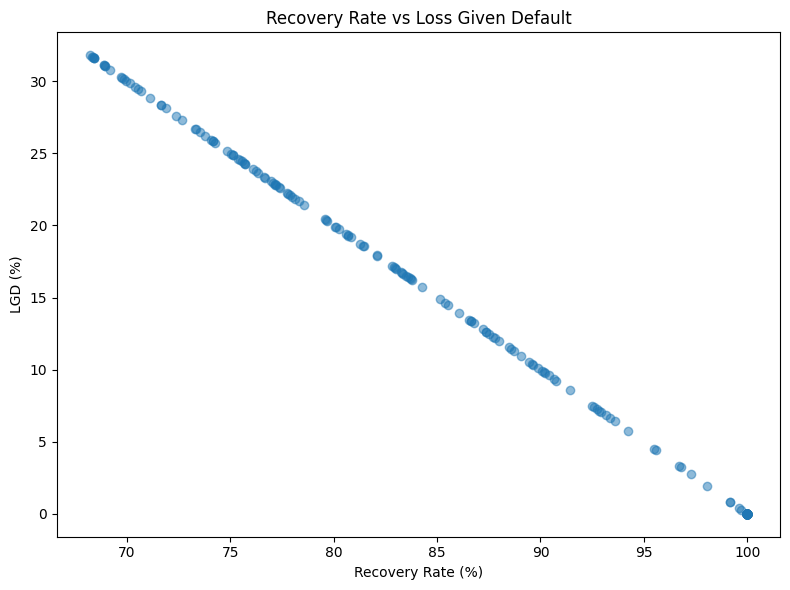

In [629]:
# ============================================================
# CELL 98 — RECOVERY RATE VS LGD
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    defaulted_loans["recovery_rate"] * 100,
    defaulted_loans["lgd"] * 100,
    alpha=0.5
)

ax.set_title(
    "Recovery Rate vs Loss Given Default"
)

ax.set_xlabel(
    "Recovery Rate (%)"
)

ax.set_ylabel(
    "LGD (%)"
)

plt.tight_layout()
plt.show()

In [630]:
# ============================================================
# CELL 99 — LGD VALIDATION
# ============================================================

print("=" * 60)
print("LGD VALIDATION")
print("=" * 60)

invalid_recovery = (
    (
        (lgd_data["recovery_rate"] < 0)
        |
        (lgd_data["recovery_rate"] > 1)
    )
    .sum()
)

invalid_lgd = (
    (
        (lgd_data["lgd"] < 0)
        |
        (lgd_data["lgd"] > 1)
    )
    .sum()
)

missing_lgd = (
    lgd_data["lgd"]
    .isna()
    .sum()
)

print(
    "Invalid recovery rates:",
    invalid_recovery
)

print(
    "Invalid LGD values:",
    invalid_lgd
)

print(
    "Missing LGD values:",
    missing_lgd
)

if (
    invalid_recovery == 0
    and invalid_lgd == 0
    and missing_lgd == 0
):
    print()
    print("✓ LGD validation passed.")
else:
    print()
    print("⚠ LGD validation requires review.")

LGD VALIDATION
Invalid recovery rates: 0
Invalid LGD values: 0
Missing LGD values: 0

✓ LGD validation passed.


In [631]:
# ============================================================
# CELL 100 — SAVE LGD RESULTS
# ============================================================

lgd_data.to_csv(
    "lgd_loan_level_results.csv",
    index=False
)

lgd_by_ltv.to_csv(
    "lgd_by_ltv_bucket.csv",
    index=False
)

lgd_by_stage.to_csv(
    "lgd_by_ifrs9_stage.csv",
    index=False
)

print("LGD datasets saved successfully.")

LGD datasets saved successfully.


In [632]:
# ============================================================
# CELL 101 — PREPARE EAD DATASET
# ============================================================

# Create a copy of the LGD dataset.
ead_data = lgd_data.copy()

print("EAD dataset created successfully.")

display(
    ead_data[
        [
            "loan_amount",
            "actual_default",
            "ifrs9_stage",
            "current_pd",
            "lgd"
        ]
    ].head(10)
)

EAD dataset created successfully.


,loan_amount,actual_default,ifrs9_stage,current_pd,lgd
7536,207352.18,0,1,0.080804,0.000000
3751,30342.79,0,1,0.018640,0.000000
3066,64601.10,0,1,0.042411,0.000000
19010,30591.09,0,1,0.017750,0.029296
13607,44122.14,0,2,0.009404,0.073806
26247,59084.69,0,1,0.121823,0.110241
26886,94789.16,0,1,0.017164,0.097758
19241,53518.15,0,1,0.031385,0.000000
15047,20694.90,0,1,0.041084,0.044629
2880,51528.49,0,1,0.010335,0.085058


In [633]:

# ============================================================
# CELL 102 — CREDIT CONVERSION FACTOR
# ============================================================

# CCF represents the percentage of an undrawn credit
# commitment that is expected to be drawn before default.
#
# This is a modelling assumption for our synthetic portfolio.

ccf = 0.20

print(
    f"Credit Conversion Factor (CCF): {ccf:.0%}"
)

Credit Conversion Factor (CCF): 20%


In [634]:
# ============================================================
# CELL 103 — BUILD REALISTIC EAD COMPONENTS
# ============================================================

# Create a synthetic credit limit.
# We assume the approved credit limit is higher than
# the current loan balance.

ead_data["credit_limit"] = (
    ead_data["loan_amount"] * 1.25
)

# Current drawn exposure.
ead_data["current_exposure"] = (
    ead_data["loan_amount"]
)

# Undrawn commitment.
ead_data["undrawn_commitment"] = (
    ead_data["credit_limit"]
    - ead_data["current_exposure"]
)

# Expected additional exposure before default.
ead_data["potential_additional_exposure"] = (
    ead_data["undrawn_commitment"] * ccf
)

# Exposure at Default.
ead_data["ead"] = (
    ead_data["current_exposure"]
    + ead_data["potential_additional_exposure"]
)

print("EAD calculated using current exposure + CCF × undrawn commitment.")

display(
    ead_data[
        [
            "loan_amount",
            "credit_limit",
            "current_exposure",
            "undrawn_commitment",
            "potential_additional_exposure",
            "ead"
        ]
    ].head(10)
)

EAD calculated using current exposure + CCF × undrawn commitment.


,loan_amount,credit_limit,current_exposure,undrawn_commitment,potential_additional_exposure,ead
7536,207352.18,259190.2250,207352.18,51838.0450,10367.6090,217719.7890
3751,30342.79,37928.4875,30342.79,7585.6975,1517.1395,31859.9295
3066,64601.10,80751.3750,64601.10,16150.2750,3230.0550,67831.1550
19010,30591.09,38238.8625,30591.09,7647.7725,1529.5545,32120.6445
13607,44122.14,55152.6750,44122.14,11030.5350,2206.1070,46328.2470
26247,59084.69,73855.8625,59084.69,14771.1725,2954.2345,62038.9245
26886,94789.16,118486.4500,94789.16,23697.2900,4739.4580,99528.6180
19241,53518.15,66897.6875,53518.15,13379.5375,2675.9075,56194.0575
15047,20694.90,25868.6250,20694.90,5173.7250,1034.7450,21729.6450
2880,51528.49,64410.6125,51528.49,12882.1225,2576.4245,54104.9145


In [635]:
# ============================================================
# CELL 104 — EAD EXPOSURE RATIO
# ============================================================

ead_data["ead_ratio"] = (
    ead_data["ead"]
    / ead_data["current_exposure"]
)

print(
    "Average EAD / Current Exposure: {:.2f}x".format(
        ead_data["ead_ratio"].mean()
    )
)

print(
    "Minimum EAD / Current Exposure: {:.2f}x".format(
        ead_data["ead_ratio"].min()
    )
)

print(
    "Maximum EAD / Current Exposure: {:.2f}x".format(
        ead_data["ead_ratio"].max()
    )
)

Average EAD / Current Exposure: 1.05x
Minimum EAD / Current Exposure: 1.05x
Maximum EAD / Current Exposure: 1.05x


In [636]:
# ============================================================
# CELL 105 — EAD BY IFRS 9 STAGE
# ============================================================

ead_by_stage = (
    ead_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("ead", "count"),
        total_ead=("ead", "sum"),
        average_ead=("ead", "mean")
    )
    .reset_index()
)

display(
    ead_by_stage.style.format({
        "total_ead": "₹{:,.0f}",
        "average_ead": "₹{:,.0f}"
    })
)

,ifrs9_stage,loans,total_ead,average_ead
0,1,4998,"₹202,561,458","₹40,529"
1,2,769,"₹32,036,584","₹41,660"
2,3,233,"₹8,910,725","₹38,243"


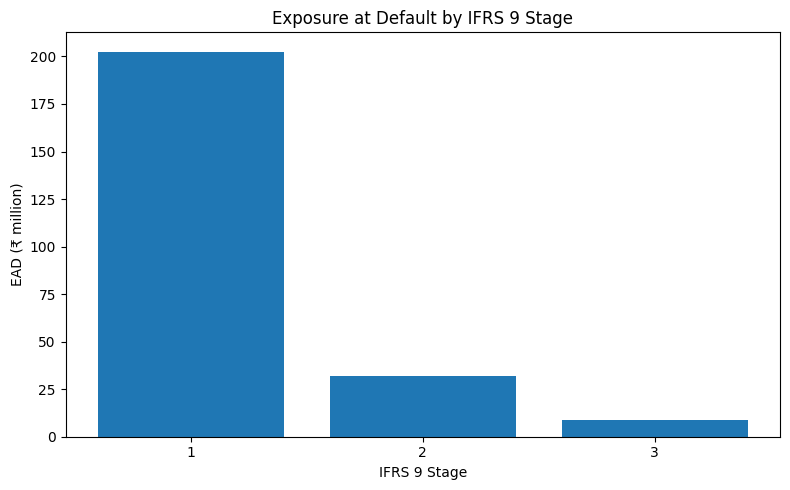

In [637]:
# ============================================================
# CELL 106 — EAD BY IFRS 9 STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    ead_by_stage["ifrs9_stage"].astype(str),
    ead_by_stage["total_ead"] / 1_000_000
)

ax.set_title(
    "Exposure at Default by IFRS 9 Stage"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "EAD (₹ million)"
)

plt.tight_layout()
plt.show()

In [638]:
# ============================================================
# CELL 107 — EAD BY DEFAULT STATUS
# ============================================================

ead_by_default = (
    ead_data
    .groupby("actual_default")
    .agg(
        loans=("ead", "count"),
        total_ead=("ead", "sum"),
        average_ead=("ead", "mean")
    )
    .reset_index()
)

ead_by_default["status"] = (
    ead_by_default["actual_default"]
    .map({
        0: "Non-Defaulted",
        1: "Defaulted"
    })
)

display(
    ead_by_default[
        [
            "status",
            "loans",
            "total_ead",
            "average_ead"
        ]
    ].style.format({
        "total_ead": "₹{:,.0f}",
        "average_ead": "₹{:,.0f}"
    })
)

,status,loans,total_ead,average_ead
0,Non-Defaulted,5767,"₹234,598,042","₹40,679"
1,Defaulted,233,"₹8,910,725","₹38,243"


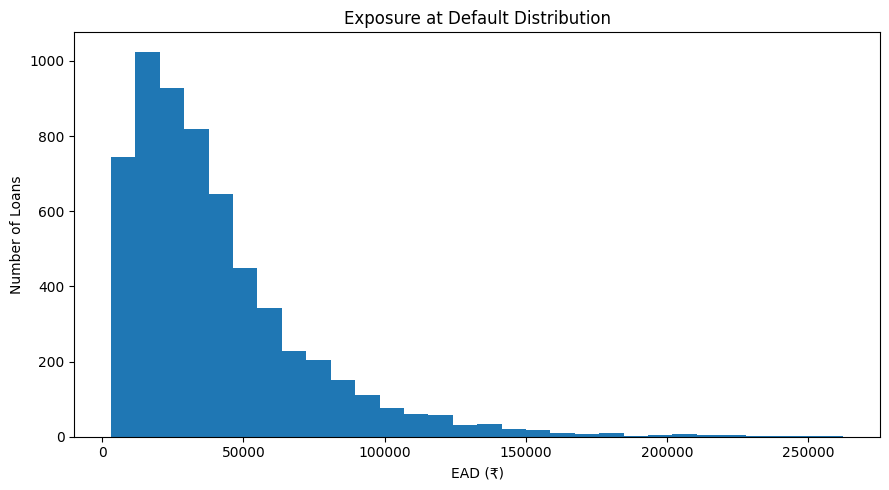

In [639]:
# ============================================================
# CELL 108 — EAD DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    ead_data["ead"],
    bins=30
)

ax.set_title(
    "Exposure at Default Distribution"
)

ax.set_xlabel(
    "EAD (₹)"
)

ax.set_ylabel(
    "Number of Loans"
)

plt.tight_layout()
plt.show()

In [640]:
# ============================================================
# CELL 109 — EAD VALIDATION
# ============================================================

print("=" * 60)
print("EAD VALIDATION")
print("=" * 60)

missing_ead = (
    ead_data["ead"]
    .isna()
    .sum()
)

negative_ead = (
    ead_data["ead"] < 0
).sum()

invalid_ead_ratio = (
    (
        ead_data["ead_ratio"] < 0
    )
    |
    (
        ead_data["ead_ratio"] > 2
    )
).sum()

print(
    "Missing EAD values:",
    missing_ead
)

print(
    "Negative EAD values:",
    negative_ead
)

print(
    "Suspicious EAD ratios:",
    invalid_ead_ratio
)

if (
    missing_ead == 0
    and negative_ead == 0
    and invalid_ead_ratio == 0
):
    print()
    print("✓ EAD validation passed.")
else:
    print()
    print("⚠ EAD validation requires review.")

EAD VALIDATION
Missing EAD values: 0
Negative EAD values: 0
Suspicious EAD ratios: 0

✓ EAD validation passed.


In [641]:
# ============================================================
# CELL 110 — EAD SUMMARY
# ============================================================

# Calculate the average EAD-to-loan ratio.
average_ead_ratio = (
    ead_data["ead"] / ead_data["loan_amount"]
).mean()

ead_summary = pd.DataFrame({
    "Metric": [
        "Total Loans",
        "Total Current Exposure",
        "Total EAD",
        "Average EAD",
        "Average EAD / Loan",
        "CCF"
    ],

    "Value": [
        len(ead_data),
        ead_data["current_exposure"].sum(),
        ead_data["ead"].sum(),
        ead_data["ead"].mean(),
        average_ead_ratio,
        ccf
    ]
})

display(ead_summary)

,Metric,Value
0,Total Loans,6.000000e+03
1,Total Current Exposure,2.319131e+08
2,Total EAD,2.435088e+08
3,Average EAD,4.058479e+04
4,Average EAD / Loan,1.050000e+00
5,CCF,2.000000e-01


In [642]:
# ============================================================
# CELL 111 — SAVE EAD RESULTS
# ============================================================

ead_data.to_csv(
    "ead_loan_level_results.csv",
    index=False
)

ead_by_stage.to_csv(
    "ead_by_ifrs9_stage.csv",
    index=False
)

ead_by_default.to_csv(
    "ead_by_default_status.csv",
    index=False
)

ead_summary.to_csv(
    "ead_summary.csv",
    index=False
)

print("EAD datasets and reports saved successfully.")

EAD datasets and reports saved successfully.


In [643]:
# ============================================================
# CELL 112 — DAY 8 EAD SUMMARY
# ============================================================

print("=" * 60)
print("DAY 8 — EXPOSURE AT DEFAULT SUMMARY")
print("=" * 60)

print(
    f"Total portfolio exposure: "
    f"₹{ead_data['current_exposure'].sum():,.0f}"
)

print(
    f"Total EAD: "
    f"₹{ead_data['ead'].sum():,.0f}"
)

print(
    f"Average EAD: "
    f"₹{ead_data['ead'].mean():,.0f}"
)

print(
    f"CCF assumption: "
    f"{ccf:.0%}"
)

print()
print("✓ EAD model completed successfully.")

DAY 8 — EXPOSURE AT DEFAULT SUMMARY
Total portfolio exposure: ₹231,913,111
Total EAD: ₹243,508,767
Average EAD: ₹40,585
CCF assumption: 20%

✓ EAD model completed successfully.


In [644]:
# ============================================================
# CELL 113 — PREPARE ECL DATASET
# ============================================================

# Combine all information required for ECL calculation:
# PD + LGD + EAD + IFRS 9 Stage.

ecl_data = ead_data.copy()

print("ECL dataset created successfully.")

display(
    ecl_data[
        [
            "loan_amount",
            "current_pd",
            "lgd",
            "ead",
            "ifrs9_stage"
        ]
    ].head(10)
)

ECL dataset created successfully.


,loan_amount,current_pd,lgd,ead,ifrs9_stage
7536,207352.18,0.080804,0.000000,217719.7890,1
3751,30342.79,0.018640,0.000000,31859.9295,1
3066,64601.10,0.042411,0.000000,67831.1550,1
19010,30591.09,0.017750,0.029296,32120.6445,1
13607,44122.14,0.009404,0.073806,46328.2470,2
26247,59084.69,0.121823,0.110241,62038.9245,1
26886,94789.16,0.017164,0.097758,99528.6180,1
19241,53518.15,0.031385,0.000000,56194.0575,1
15047,20694.90,0.041084,0.044629,21729.6450,1
2880,51528.49,0.010335,0.085058,54104.9145,1


In [645]:
# ============================================================
# CELL 114 — DEFINE LIFETIME ECL HORIZON
# ============================================================

# For this educational model, we assume a 5-year lifetime
# horizon for Stage 2 and Stage 3 calculations.
#
# This is a modelling assumption for the synthetic portfolio.
# In a real bank, the horizon would depend on contractual
# maturity, expected life and other product-specific factors.

lifetime_years = 5

print(
    f"Lifetime ECL horizon: {lifetime_years} years"
)

Lifetime ECL horizon: 5 years


In [646]:
# ============================================================
# CELL 115 — CALCULATE LIFETIME PD
# ============================================================

ecl_data["lifetime_pd"] = (
    1
    - (
        1 - ecl_data["current_pd"]
    ) ** lifetime_years
)

# Keep PD between 0% and 100%.
ecl_data["lifetime_pd"] = np.clip(
    ecl_data["lifetime_pd"],
    0,
    1
)

print("Lifetime PD calculated successfully.")

display(
    ecl_data[
        [
            "current_pd",
            "lifetime_pd"
        ]
    ].head(10).style.format({
        "current_pd": "{:.2%}",
        "lifetime_pd": "{:.2%}"
    })
)

Lifetime PD calculated successfully.


,current_pd,lifetime_pd
7536,8.08%,34.38%
3751,1.86%,8.98%
3066,4.24%,19.48%
19010,1.78%,8.57%
13607,0.94%,4.61%
26247,12.18%,47.77%
26886,1.72%,8.29%
19241,3.14%,14.74%
15047,4.11%,18.92%
2880,1.03%,5.06%


In [647]:
# ============================================================
# CELL 116 — STAGE-SPECIFIC PD FOR ECL
# ============================================================

# Stage 1:
# Use 12-month PD.
#
# Stage 2:
# Use lifetime PD.
#
# Stage 3:
# Borrower is already credit-impaired, so for this simplified
# ECL engine we use a conditional default probability of 100%.

ecl_data["ecl_pd"] = np.select(
    [
        ecl_data["ifrs9_stage"] == 1,
        ecl_data["ifrs9_stage"] == 2,
        ecl_data["ifrs9_stage"] == 3
    ],
    [
        ecl_data["current_pd"],
        ecl_data["lifetime_pd"],
        1.0
    ],
    default=np.nan
)

print("Stage-specific ECL PD assigned.")

display(
    ecl_data[
        [
            "ifrs9_stage",
            "current_pd",
            "lifetime_pd",
            "ecl_pd"
        ]
    ].head(15).style.format({
        "current_pd": "{:.2%}",
        "lifetime_pd": "{:.2%}",
        "ecl_pd": "{:.2%}"
    })
)

Stage-specific ECL PD assigned.


,ifrs9_stage,current_pd,lifetime_pd,ecl_pd
7536,1,8.08%,34.38%,8.08%
3751,1,1.86%,8.98%,1.86%
3066,1,4.24%,19.48%,4.24%
19010,1,1.78%,8.57%,1.78%
13607,2,0.94%,4.61%,4.61%
26247,1,12.18%,47.77%,12.18%
26886,1,1.72%,8.29%,1.72%
19241,1,3.14%,14.74%,3.14%
15047,1,4.11%,18.92%,4.11%
2880,1,1.03%,5.06%,1.03%


In [648]:
# ============================================================
# CELL 117 — VALIDATE STAGE-SPECIFIC PD
# ============================================================

pd_stage_check = (
    ecl_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("ecl_pd", "count"),
        average_current_pd=("current_pd", "mean"),
        average_lifetime_pd=("lifetime_pd", "mean"),
        average_ecl_pd=("ecl_pd", "mean")
    )
    .reset_index()
)

display(
    pd_stage_check.style.format({
        "average_current_pd": "{:.2%}",
        "average_lifetime_pd": "{:.2%}",
        "average_ecl_pd": "{:.2%}"
    })
)

,ifrs9_stage,loans,average_current_pd,average_lifetime_pd,average_ecl_pd
0,1,4998,3.79%,16.90%,3.79%
1,2,769,3.70%,16.54%,16.54%
2,3,233,5.89%,24.99%,100.00%


In [649]:
# ============================================================
# CELL 118 — CALCULATE EXPECTED CREDIT LOSS
# ============================================================

# Core simplified ECL formula:
#
# ECL = PD × LGD × EAD

ecl_data["expected_credit_loss"] = (
    ecl_data["ecl_pd"]
    * ecl_data["lgd"]
    * ecl_data["ead"]
)

print("Expected Credit Loss calculated successfully.")

display(
    ecl_data[
        [
            "ifrs9_stage",
            "ecl_pd",
            "lgd",
            "ead",
            "expected_credit_loss"
        ]
    ].head(10).style.format({
        "ecl_pd": "{:.2%}",
        "lgd": "{:.2%}",
        "ead": "₹{:,.0f}",
        "expected_credit_loss": "₹{:,.0f}"
    })
)

Expected Credit Loss calculated successfully.


,ifrs9_stage,ecl_pd,lgd,ead,expected_credit_loss
7536,1,8.08%,0.00%,"₹217,720",₹0
3751,1,1.86%,0.00%,"₹31,860",₹0
3066,1,4.24%,0.00%,"₹67,831",₹0
19010,1,1.78%,2.93%,"₹32,121",₹17
13607,2,4.61%,7.38%,"₹46,328",₹158
26247,1,12.18%,11.02%,"₹62,039",₹833
26886,1,1.72%,9.78%,"₹99,529",₹167
19241,1,3.14%,0.00%,"₹56,194",₹0
15047,1,4.11%,4.46%,"₹21,730",₹40
2880,1,1.03%,8.51%,"₹54,105",₹48


In [650]:
# ============================================================
# CELL 119 — ECL RATE
# ============================================================

ecl_data["ecl_rate"] = (
    ecl_data["expected_credit_loss"]
    / ecl_data["ead"]
)

print(
    "Average ECL rate: {:.2%}".format(
        ecl_data["ecl_rate"].mean()
    )
)

display(
    ecl_data[
        [
            "ifrs9_stage",
            "ead",
            "expected_credit_loss",
            "ecl_rate"
        ]
    ].head(10).style.format({
        "ead": "₹{:,.0f}",
        "expected_credit_loss": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

Average ECL rate: 0.98%


,ifrs9_stage,ead,expected_credit_loss,ecl_rate
7536,1,"₹217,720",₹0,0.00%
3751,1,"₹31,860",₹0,0.00%
3066,1,"₹67,831",₹0,0.00%
19010,1,"₹32,121",₹17,0.05%
13607,2,"₹46,328",₹158,0.34%
26247,1,"₹62,039",₹833,1.34%
26886,1,"₹99,529",₹167,0.17%
19241,1,"₹56,194",₹0,0.00%
15047,1,"₹21,730",₹40,0.18%
2880,1,"₹54,105",₹48,0.09%


In [651]:
# ============================================================
# CELL 120 — PORTFOLIO ECL
# ============================================================

total_ead = ecl_data["ead"].sum()

total_ecl = (
    ecl_data["expected_credit_loss"]
    .sum()
)

portfolio_ecl_rate = (
    total_ecl / total_ead
)

print("=" * 60)
print("PORTFOLIO EXPECTED CREDIT LOSS")
print("=" * 60)

print(
    f"Total EAD: ₹{total_ead:,.0f}"
)

print(
    f"Total Expected Credit Loss: ₹{total_ecl:,.0f}"
)

print(
    f"Portfolio ECL Rate: {portfolio_ecl_rate:.2%}"
)

PORTFOLIO EXPECTED CREDIT LOSS
Total EAD: ₹243,508,767
Total Expected Credit Loss: ₹2,293,504
Portfolio ECL Rate: 0.94%


In [652]:
# ============================================================
# CELL 121 — ECL BY IFRS 9 STAGE
# ============================================================

ecl_by_stage = (
    ecl_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("expected_credit_loss", "count"),
        total_ead=("ead", "sum"),
        total_ecl=("expected_credit_loss", "sum"),
        average_pd=("ecl_pd", "mean"),
        average_lgd=("lgd", "mean")
    )
    .reset_index()
)

ecl_by_stage["ecl_rate"] = (
    ecl_by_stage["total_ecl"]
    / ecl_by_stage["total_ead"]
)

display(
    ecl_by_stage.style.format({
        "total_ead": "₹{:,.0f}",
        "total_ecl": "₹{:,.0f}",
        "average_pd": "{:.2%}",
        "average_lgd": "{:.2%}",
        "ecl_rate": "{:.2%}"
    })
)

,ifrs9_stage,loans,total_ead,total_ecl,average_pd,average_lgd,ecl_rate
0,1,4998,"₹202,561,458","₹836,776",3.79%,9.52%,0.41%
1,2,769,"₹32,036,584","₹564,253",16.54%,9.25%,1.76%
2,3,233,"₹8,910,725","₹892,474",100.00%,11.08%,10.02%


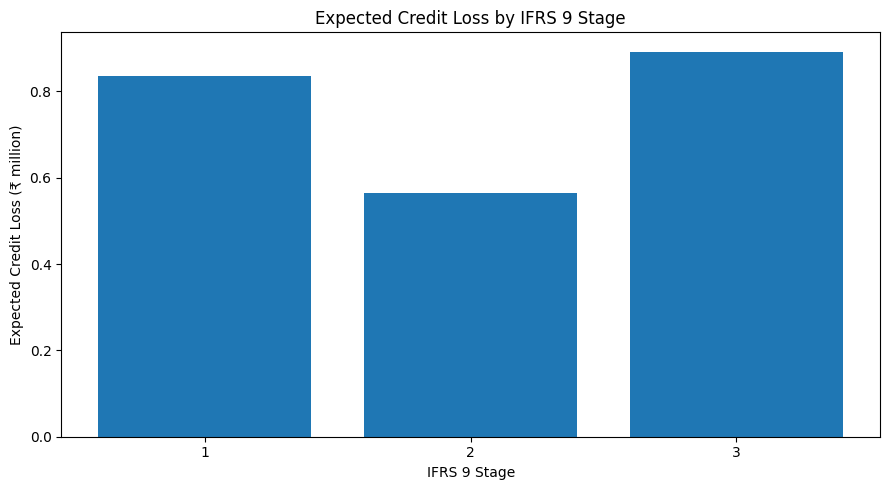

In [653]:
# ============================================================
# CELL 122 — ECL BY IFRS 9 STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    ecl_by_stage["ifrs9_stage"].astype(str),
    ecl_by_stage["total_ecl"] / 1_000_000
)

ax.set_title(
    "Expected Credit Loss by IFRS 9 Stage"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.tight_layout()
plt.show()

In [654]:
# ============================================================
# CELL 123 — ECL CONTRIBUTION BY STAGE
# ============================================================

ecl_by_stage["ecl_contribution"] = (
    ecl_by_stage["total_ecl"]
    / total_ecl
)

display(
    ecl_by_stage[
        [
            "ifrs9_stage",
            "total_ecl",
            "ecl_contribution"
        ]
    ].style.format({
        "total_ecl": "₹{:,.0f}",
        "ecl_contribution": "{:.2%}"
    })
)

,ifrs9_stage,total_ecl,ecl_contribution
0,1,"₹836,776",36.48%
1,2,"₹564,253",24.60%
2,3,"₹892,474",38.91%


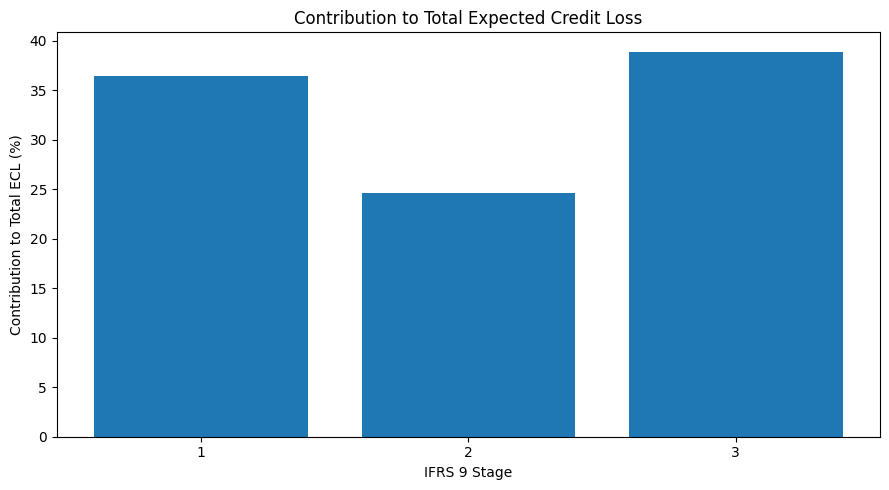

In [655]:
# ============================================================
# CELL 124 — ECL CONTRIBUTION BY STAGE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    ecl_by_stage["ifrs9_stage"].astype(str),
    ecl_by_stage["ecl_contribution"] * 100
)

ax.set_title(
    "Contribution to Total Expected Credit Loss"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Contribution to Total ECL (%)"
)

plt.tight_layout()
plt.show()

In [656]:
# ============================================================
# CELL 125 — ECL BY SECTOR
# ============================================================

ecl_by_sector = (
    ecl_data
    .groupby("sector")
    .agg(
        loans=("expected_credit_loss", "count"),
        total_ead=("ead", "sum"),
        total_ecl=("expected_credit_loss", "sum")
    )
    .reset_index()
)

ecl_by_sector["ecl_rate"] = (
    ecl_by_sector["total_ecl"]
    / ecl_by_sector["total_ead"]
)

display(
    ecl_by_sector.style.format({
        "total_ead": "₹{:,.0f}",
        "total_ecl": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,sector,loans,total_ead,total_ecl,ecl_rate
0,Healthcare,1197,"₹48,210,795","₹447,662",0.93%
1,Manufacturing,1205,"₹49,124,453","₹535,820",1.09%
2,Retail,1211,"₹47,542,301","₹508,774",1.07%
3,Services,1170,"₹49,611,068","₹395,104",0.80%
4,Technology,1217,"₹49,020,149","₹406,143",0.83%


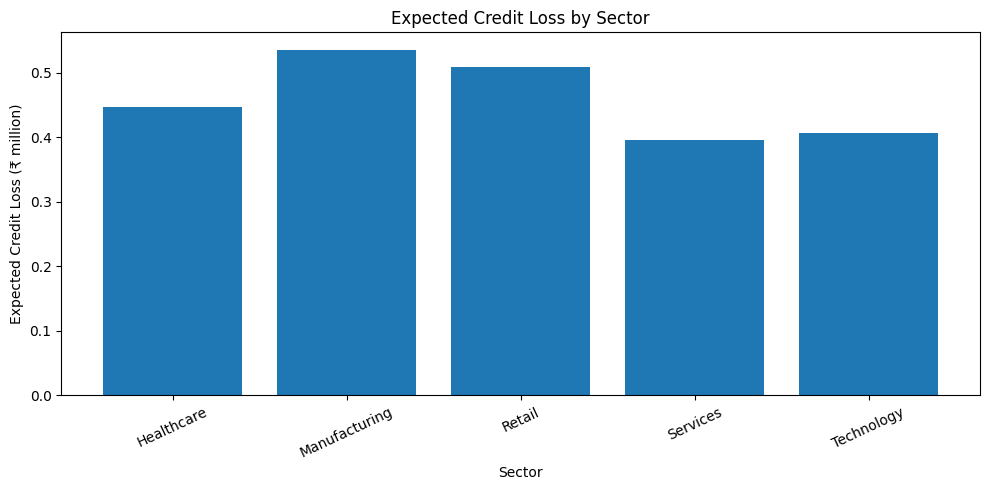

In [657]:
# ============================================================
# CELL 126 — ECL BY SECTOR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    ecl_by_sector["sector"],
    ecl_by_sector["total_ecl"] / 1_000_000
)

ax.set_title(
    "Expected Credit Loss by Sector"
)

ax.set_xlabel(
    "Sector"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [658]:
# ============================================================
# CELL 127 — ECL VALIDATION
# ============================================================

print("=" * 60)
print("ECL MODEL VALIDATION")
print("=" * 60)

missing_ecl = (
    ecl_data["expected_credit_loss"]
    .isna()
    .sum()
)

negative_ecl = (
    ecl_data["expected_credit_loss"] < 0
).sum()

ecl_above_ead = (
    ecl_data["expected_credit_loss"]
    > ecl_data["ead"]
).sum()

invalid_stage_pd = (
    (
        ecl_data["ecl_pd"] < 0
    )
    |
    (
        ecl_data["ecl_pd"] > 1
    )
).sum()

print(
    "Missing ECL values:",
    missing_ecl
)

print(
    "Negative ECL values:",
    negative_ecl
)

print(
    "ECL greater than EAD:",
    ecl_above_ead
)

print(
    "Invalid ECL PD values:",
    invalid_stage_pd
)

if (
    missing_ecl == 0
    and negative_ecl == 0
    and ecl_above_ead == 0
    and invalid_stage_pd == 0
):
    print()
    print("✓ ECL validation passed.")
else:
    print()
    print("⚠ ECL validation requires review.")

ECL MODEL VALIDATION
Missing ECL values: 0
Negative ECL values: 0
ECL greater than EAD: 0
Invalid ECL PD values: 0

✓ ECL validation passed.


In [659]:
# ============================================================
# CELL 128 — ECL SUMMARY
# ============================================================

ecl_summary = pd.DataFrame({
    "Metric": [
        "Total Loans",
        "Total EAD",
        "Total Expected Credit Loss",
        "Portfolio ECL Rate",
        "Stage 1 ECL",
        "Stage 2 ECL",
        "Stage 3 ECL"
    ],

    "Value": [
        len(ecl_data),
        total_ead,
        total_ecl,
        portfolio_ecl_rate,
        ecl_by_stage.loc[
            ecl_by_stage["ifrs9_stage"] == 1,
            "total_ecl"
        ].sum(),
        ecl_by_stage.loc[
            ecl_by_stage["ifrs9_stage"] == 2,
            "total_ecl"
        ].sum(),
        ecl_by_stage.loc[
            ecl_by_stage["ifrs9_stage"] == 3,
            "total_ecl"
        ].sum()
    ]
})

display(ecl_summary)

,Metric,Value
0,Total Loans,6.000000e+03
1,Total EAD,2.435088e+08
2,Total Expected Credit Loss,2.293504e+06
3,Portfolio ECL Rate,9.418567e-03
4,Stage 1 ECL,8.367763e+05
5,Stage 2 ECL,5.642534e+05
6,Stage 3 ECL,8.924739e+05


In [660]:
# ============================================================
# CELL 129 — SAVE ECL RESULTS
# ============================================================

ecl_data.to_csv(
    "ecl_loan_level_results.csv",
    index=False
)

ecl_by_stage.to_csv(
    "ecl_by_ifrs9_stage.csv",
    index=False
)

ecl_by_sector.to_csv(
    "ecl_by_sector.csv",
    index=False
)

ecl_summary.to_csv(
    "ecl_summary.csv",
    index=False
)

print("ECL datasets and reports saved successfully.")

ECL datasets and reports saved successfully.


In [661]:
# ============================================================
# CELL 130 — FINAL ECL CHECK
# ============================================================

print("=" * 60)
print("EXPECTED CREDIT LOSS ENGINE")
print("=" * 60)

print(
    f"Portfolio EAD: ₹{total_ead:,.0f}"
)

print(
    f"Portfolio ECL: ₹{total_ecl:,.0f}"
)

print(
    f"Portfolio ECL Rate: {portfolio_ecl_rate:.2%}"
)

print()

print("ECL methodology:")
print("Stage 1 → 12-month ECL")
print("Stage 2 → Lifetime ECL")
print("Stage 3 → Credit-impaired ECL")

print()

print("Core formula:")
print("ECL = PD × LGD × EAD")

print()

print("✓ ECL engine completed.")

EXPECTED CREDIT LOSS ENGINE
Portfolio EAD: ₹243,508,767
Portfolio ECL: ₹2,293,504
Portfolio ECL Rate: 0.94%

ECL methodology:
Stage 1 → 12-month ECL
Stage 2 → Lifetime ECL
Stage 3 → Credit-impaired ECL

Core formula:
ECL = PD × LGD × EAD

✓ ECL engine completed.


In [662]:
# ============================================================
# CELL 131 — CREATE MACROECONOMIC SCENARIO DATASET
# ============================================================

scenario_data = ecl_data.copy()

print("Scenario dataset created successfully.")

display(
    scenario_data[
        [
            "ifrs9_stage",
            "current_pd",
            "lifetime_pd",
            "lgd",
            "ead",
            "expected_credit_loss"
        ]
    ].head(10)
)

Scenario dataset created successfully.


,ifrs9_stage,current_pd,lifetime_pd,lgd,ead,expected_credit_loss
7536,1,0.080804,0.343792,0.000000,217719.7890,0.000000
3751,1,0.018640,0.089788,0.000000,31859.9295,0.000000
3066,1,0.042411,0.194815,0.000000,67831.1550,0.000000
19010,1,0.017750,0.085656,0.029296,32120.6445,16.702935
13607,2,0.009404,0.046145,0.073806,46328.2470,157.783568
26247,1,0.121823,0.477712,0.110241,62038.9245,833.179078
26886,1,0.017164,0.082923,0.097758,99528.6180,166.998015
19241,1,0.031385,0.147381,0.000000,56194.0575,0.000000
15047,1,0.041084,0.189222,0.044629,21729.6450,39.842893
2880,1,0.010335,0.050617,0.085058,54104.9145,47.561548


In [663]:
# ============================================================
# CELL 132 — DEFINE MACROECONOMIC SCENARIOS
# ============================================================

scenarios = {
    "Optimistic": {
        "pd_multiplier": 0.80,
        "lgd_multiplier": 0.90
    },

    "Base": {
        "pd_multiplier": 1.00,
        "lgd_multiplier": 1.00
    },

    "Downside": {
        "pd_multiplier": 1.50,
        "lgd_multiplier": 1.20
    }
}

print("Macroeconomic scenarios defined:")

for scenario, assumptions in scenarios.items():
    print(
        f"{scenario}: "
        f"PD × {assumptions['pd_multiplier']:.2f}, "
        f"LGD × {assumptions['lgd_multiplier']:.2f}"
    )

Macroeconomic scenarios defined:
Optimistic: PD × 0.80, LGD × 0.90
Base: PD × 1.00, LGD × 1.00
Downside: PD × 1.50, LGD × 1.20


In [664]:
# ============================================================
# CELL 133 — CALCULATE SCENARIO ECL
# ============================================================

scenario_results = []

for scenario_name, assumptions in scenarios.items():

    temp = scenario_data.copy()

    # Apply the scenario PD shock.
    temp["scenario_pd"] = (
        temp["ecl_pd"]
        * assumptions["pd_multiplier"]
    )

    # Cap PD at 100%.
    temp["scenario_pd"] = np.clip(
        temp["scenario_pd"],
        0,
        1
    )

    # Apply the scenario LGD shock.
    temp["scenario_lgd"] = (
        temp["lgd"]
        * assumptions["lgd_multiplier"]
    )

    # Cap LGD at 100%.
    temp["scenario_lgd"] = np.clip(
        temp["scenario_lgd"],
        0,
        1
    )

    # Calculate scenario ECL.
    temp["scenario_ecl"] = (
        temp["scenario_pd"]
        * temp["scenario_lgd"]
        * temp["ead"]
    )

    temp["scenario"] = scenario_name

    scenario_results.append(temp)

scenario_data_all = pd.concat(
    scenario_results,
    ignore_index=True
)

print("Scenario ECL calculations completed.")

display(
    scenario_data_all[
        [
            "scenario",
            "ifrs9_stage",
            "scenario_pd",
            "scenario_lgd",
            "ead",
            "scenario_ecl"
        ]
    ].head(10).style.format({
        "scenario_pd": "{:.2%}",
        "scenario_lgd": "{:.2%}",
        "ead": "₹{:,.0f}",
        "scenario_ecl": "₹{:,.0f}"
    })
)

Scenario ECL calculations completed.


,scenario,ifrs9_stage,scenario_pd,scenario_lgd,ead,scenario_ecl
0,Optimistic,1,6.46%,0.00%,"₹217,720",₹0
1,Optimistic,1,1.49%,0.00%,"₹31,860",₹0
2,Optimistic,1,3.39%,0.00%,"₹67,831",₹0
3,Optimistic,1,1.42%,2.64%,"₹32,121",₹12
4,Optimistic,2,3.69%,6.64%,"₹46,328",₹114
5,Optimistic,1,9.75%,9.92%,"₹62,039",₹600
6,Optimistic,1,1.37%,8.80%,"₹99,529",₹120
7,Optimistic,1,2.51%,0.00%,"₹56,194",₹0
8,Optimistic,1,3.29%,4.02%,"₹21,730",₹29
9,Optimistic,1,0.83%,7.66%,"₹54,105",₹34


In [665]:
# ============================================================
# CELL 134 — TOTAL ECL BY SCENARIO
# ============================================================

scenario_summary = (
    scenario_data_all
    .groupby("scenario")
    .agg(
        total_ead=("ead", "sum"),
        total_ecl=("scenario_ecl", "sum")
    )
    .reset_index()
)

scenario_summary["ecl_rate"] = (
    scenario_summary["total_ecl"]
    / scenario_summary["total_ead"]
)

display(
    scenario_summary.style.format({
        "total_ead": "₹{:,.0f}",
        "total_ecl": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,scenario,total_ead,total_ecl,ecl_rate
0,Base,"₹243,508,767","₹2,293,504",0.94%
1,Downside,"₹243,508,767","₹3,592,344",1.48%
2,Optimistic,"₹243,508,767","₹1,651,323",0.68%


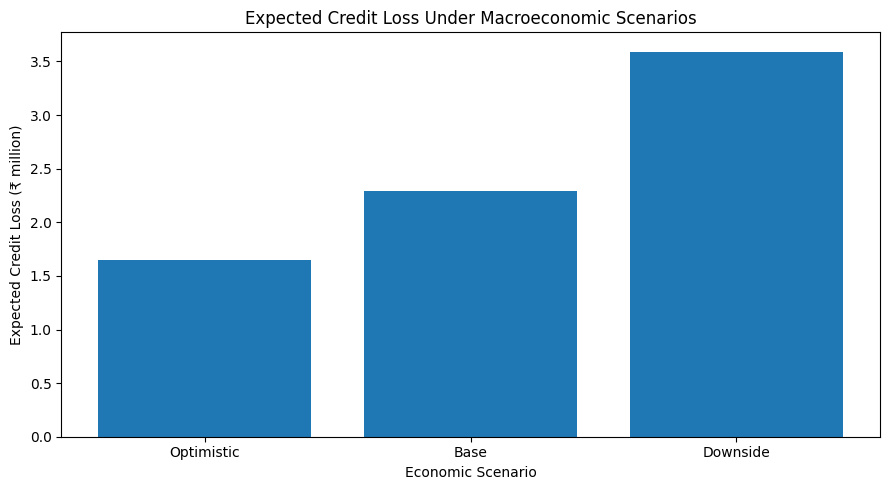

In [666]:
# ============================================================
# CELL 135 — SCENARIO ECL COMPARISON
# ============================================================

scenario_order = [
    "Optimistic",
    "Base",
    "Downside"
]

plot_data = (
    scenario_summary
    .set_index("scenario")
    .loc[scenario_order]
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_data["scenario"],
    plot_data["total_ecl"] / 1_000_000
)

ax.set_title(
    "Expected Credit Loss Under Macroeconomic Scenarios"
)

ax.set_xlabel(
    "Economic Scenario"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.tight_layout()
plt.show()

In [667]:
# ============================================================
# CELL 136 — ECL BY STAGE AND SCENARIO
# ============================================================

scenario_stage = (
    scenario_data_all
    .groupby(
        [
            "scenario",
            "ifrs9_stage"
        ]
    )
    .agg(
        total_ecl=("scenario_ecl", "sum")
    )
    .reset_index()
)

display(
    scenario_stage.style.format({
        "total_ecl": "₹{:,.0f}"
    })
)

,scenario,ifrs9_stage,total_ecl
0,Base,1,"₹836,776"
1,Base,2,"₹564,253"
2,Base,3,"₹892,474"
3,Downside,1,"₹1,506,197"
4,Downside,2,"₹1,015,178"
5,Downside,3,"₹1,070,969"
6,Optimistic,1,"₹602,479"
7,Optimistic,2,"₹406,262"
8,Optimistic,3,"₹642,581"


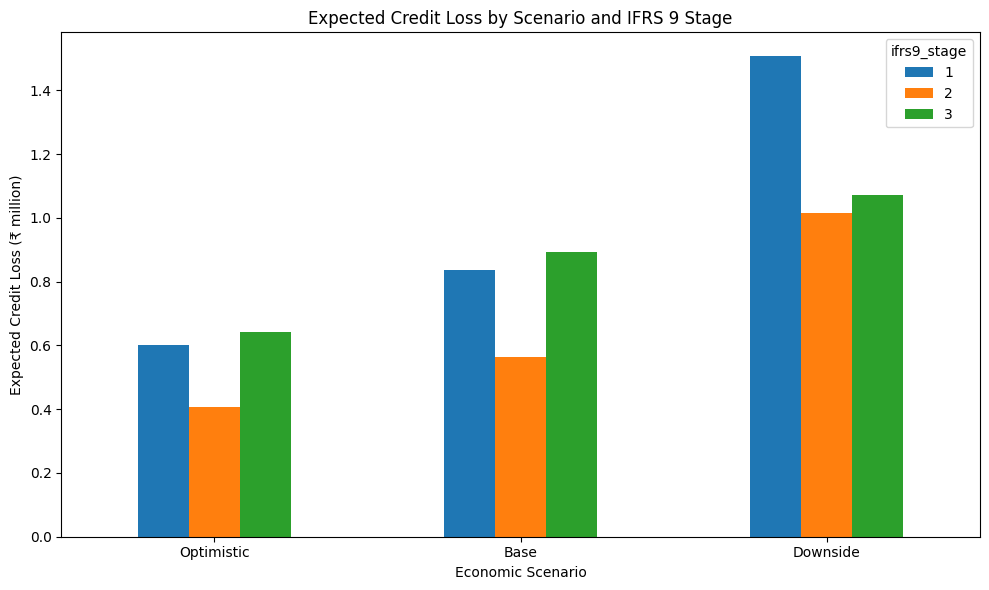

In [668]:
# ============================================================
# CELL 137 — SCENARIO ECL BY IFRS 9 STAGE
# ============================================================

pivot_stage = scenario_stage.pivot(
    index="scenario",
    columns="ifrs9_stage",
    values="total_ecl"
).reindex(
    ["Optimistic", "Base", "Downside"]
)

fig, ax = plt.subplots(figsize=(10, 6))

pivot_stage.div(
    1_000_000
).plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Expected Credit Loss by Scenario and IFRS 9 Stage"
)

ax.set_xlabel(
    "Economic Scenario"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [669]:
# ============================================================
# CELL 138 — SCENARIO PROBABILITIES
# ============================================================

scenario_probabilities = {
    "Optimistic": 0.20,
    "Base": 0.60,
    "Downside": 0.20
}

print("Scenario probabilities:")

for scenario, probability in scenario_probabilities.items():
    print(
        f"{scenario}: {probability:.0%}"
    )

print(
    "\nProbability total:",
    sum(scenario_probabilities.values())
)

Scenario probabilities:
Optimistic: 20%
Base: 60%
Downside: 20%

Probability total: 1.0


In [670]:
# ============================================================
# CELL 139 — PROBABILITY-WEIGHTED ECL
# ============================================================

scenario_summary["probability"] = (
    scenario_summary["scenario"]
    .map(scenario_probabilities)
)

scenario_summary["weighted_ecl"] = (
    scenario_summary["total_ecl"]
    * scenario_summary["probability"]
)

probability_weighted_ecl = (
    scenario_summary["weighted_ecl"]
    .sum()
)

print(
    f"Probability-weighted ECL: "
    f"₹{probability_weighted_ecl:,.0f}"
)

display(
    scenario_summary.style.format({
        "total_ead": "₹{:,.0f}",
        "total_ecl": "₹{:,.0f}",
        "ecl_rate": "{:.2%}",
        "probability": "{:.0%}",
        "weighted_ecl": "₹{:,.0f}"
    })
)

Probability-weighted ECL: ₹2,424,836


,scenario,total_ead,total_ecl,ecl_rate,probability,weighted_ecl
0,Base,"₹243,508,767","₹2,293,504",0.94%,60%,"₹1,376,102"
1,Downside,"₹243,508,767","₹3,592,344",1.48%,20%,"₹718,469"
2,Optimistic,"₹243,508,767","₹1,651,323",0.68%,20%,"₹330,265"


In [671]:
# ============================================================
# CELL 140 — BASE VS PROBABILITY-WEIGHTED ECL
# ============================================================

base_ecl = scenario_summary.loc[
    scenario_summary["scenario"] == "Base",
    "total_ecl"
].iloc[0]

comparison = pd.DataFrame({
    "Measure": [
        "Base Scenario ECL",
        "Probability-Weighted ECL",
        "Difference"
    ],

    "Value": [
        base_ecl,
        probability_weighted_ecl,
        probability_weighted_ecl - base_ecl
    ]
})

display(
    comparison.style.format({
        "Value": "₹{:,.0f}"
    })
)

,Measure,Value
0,Base Scenario ECL,"₹2,293,504"
1,Probability-Weighted ECL,"₹2,424,836"
2,Difference,"₹131,332"


In [672]:
# ============================================================
# CELL 141 — DOWNSIDE STRESS IMPACT
# ============================================================

downside_ecl = scenario_summary.loc[
    scenario_summary["scenario"] == "Downside",
    "total_ecl"
].iloc[0]

stress_increase = (
    downside_ecl / base_ecl - 1
)

print(
    f"Base ECL: ₹{base_ecl:,.0f}"
)

print(
    f"Downside ECL: ₹{downside_ecl:,.0f}"
)

print(
    f"Increase under downside scenario: "
    f"{stress_increase:.2%}"
)

Base ECL: ₹2,293,504
Downside ECL: ₹3,592,344
Increase under downside scenario: 56.63%


In [673]:
# ============================================================
# CELL 142 — SCENARIO VALIDATION
# ============================================================

print("=" * 60)
print("MACROECONOMIC SCENARIO VALIDATION")
print("=" * 60)

probability_total = sum(
    scenario_probabilities.values()
)

missing_scenario_ecl = (
    scenario_data_all["scenario_ecl"]
    .isna()
    .sum()
)

negative_scenario_ecl = (
    scenario_data_all["scenario_ecl"] < 0
).sum()

print(
    "Scenario probability total:",
    probability_total
)

print(
    "Missing scenario ECL values:",
    missing_scenario_ecl
)

print(
    "Negative scenario ECL values:",
    negative_scenario_ecl
)

if (
    abs(probability_total - 1) < 0.0001
    and missing_scenario_ecl == 0
    and negative_scenario_ecl == 0
):
    print()
    print("✓ Scenario validation passed.")
else:
    print()
    print("⚠ Scenario validation requires review.")

MACROECONOMIC SCENARIO VALIDATION
Scenario probability total: 1.0
Missing scenario ECL values: 0
Negative scenario ECL values: 0

✓ Scenario validation passed.


In [674]:
# ============================================================
# CELL 143 — SAVE SCENARIO RESULTS
# ============================================================

scenario_data_all.to_csv(
    "ecl_macro_scenario_results.csv",
    index=False
)

scenario_summary.to_csv(
    "ecl_macro_scenario_summary.csv",
    index=False
)

scenario_stage.to_csv(
    "ecl_macro_scenario_by_stage.csv",
    index=False
)

print("Macroeconomic scenario results saved successfully.")

Macroeconomic scenario results saved successfully.


In [675]:
# ============================================================
# CELL 144 — FINAL SCENARIO SUMMARY
# ============================================================

print("=" * 60)
print("MACROECONOMIC ECL SUMMARY")
print("=" * 60)

print(
    f"Base Scenario ECL: "
    f"₹{base_ecl:,.0f}"
)

print(
    f"Downside Scenario ECL: "
    f"₹{downside_ecl:,.0f}"
)

print(
    f"Probability-Weighted ECL: "
    f"₹{probability_weighted_ecl:,.0f}"
)

print(
    f"Downside Stress Increase: "
    f"{stress_increase:.2%}"
)

print()

print("✓ Macroeconomic scenario analysis completed.")

MACROECONOMIC ECL SUMMARY
Base Scenario ECL: ₹2,293,504
Downside Scenario ECL: ₹3,592,344
Probability-Weighted ECL: ₹2,424,836
Downside Stress Increase: 56.63%

✓ Macroeconomic scenario analysis completed.


In [676]:
# ============================================================
# CELL 145 — CREATE STRESS-TEST DATASET
# ============================================================

stress_data = ecl_data.copy()

print("Stress-test dataset created successfully.")

display(
    stress_data[
        [
            "ifrs9_stage",
            "sector",
            "ecl_pd",
            "lgd",
            "ead"
        ]
    ].head(10)
)

Stress-test dataset created successfully.


,ifrs9_stage,sector,ecl_pd,lgd,ead
7536,1,Retail,0.080804,0.000000,217719.7890
3751,1,Manufacturing,0.018640,0.000000,31859.9295
3066,1,Services,0.042411,0.000000,67831.1550
19010,1,Retail,0.017750,0.029296,32120.6445
13607,2,Retail,0.046145,0.073806,46328.2470
26247,1,Manufacturing,0.121823,0.110241,62038.9245
26886,1,Healthcare,0.017164,0.097758,99528.6180
19241,1,Services,0.031385,0.000000,56194.0575
15047,1,Services,0.041084,0.044629,21729.6450
2880,1,Technology,0.010335,0.085058,54104.9145


In [677]:
# ============================================================
# CELL 146 — DEFINE STRESS SCENARIOS
# ============================================================

stress_scenarios = {
    "Mild Stress": {
        "pd_multiplier": 1.25,
        "lgd_multiplier": 1.10,
        "ead_multiplier": 1.05
    },

    "Severe Stress": {
        "pd_multiplier": 1.50,
        "lgd_multiplier": 1.20,
        "ead_multiplier": 1.10
    },

    "Extreme Stress": {
        "pd_multiplier": 2.00,
        "lgd_multiplier": 1.35,
        "ead_multiplier": 1.20
    }
}

for scenario, assumptions in stress_scenarios.items():

    print(
        f"{scenario}: "
        f"PD × {assumptions['pd_multiplier']:.2f}, "
        f"LGD × {assumptions['lgd_multiplier']:.2f}, "
        f"EAD × {assumptions['ead_multiplier']:.2f}"
    )

Mild Stress: PD × 1.25, LGD × 1.10, EAD × 1.05
Severe Stress: PD × 1.50, LGD × 1.20, EAD × 1.10
Extreme Stress: PD × 2.00, LGD × 1.35, EAD × 1.20


In [678]:
# ============================================================
# CELL 147 — APPLY STRESS SCENARIOS
# ============================================================

stress_results = []

for scenario_name, assumptions in stress_scenarios.items():

    temp = stress_data.copy()

    # Stress PD
    temp["stress_pd"] = (
        temp["ecl_pd"]
        * assumptions["pd_multiplier"]
    )

    temp["stress_pd"] = np.clip(
        temp["stress_pd"],
        0,
        1
    )

    # Stress LGD
    temp["stress_lgd"] = (
        temp["lgd"]
        * assumptions["lgd_multiplier"]
    )

    temp["stress_lgd"] = np.clip(
        temp["stress_lgd"],
        0,
        1
    )

    # Stress EAD
    temp["stress_ead"] = (
        temp["ead"]
        * assumptions["ead_multiplier"]
    )

    # Stress ECL
    temp["stress_ecl"] = (
        temp["stress_pd"]
        * temp["stress_lgd"]
        * temp["stress_ead"]
    )

    temp["stress_scenario"] = scenario_name

    stress_results.append(temp)

stress_data_all = pd.concat(
    stress_results,
    ignore_index=True
)

print("Stress scenarios applied successfully.")

display(
    stress_data_all[
        [
            "stress_scenario",
            "ifrs9_stage",
            "stress_pd",
            "stress_lgd",
            "stress_ead",
            "stress_ecl"
        ]
    ].head(10).style.format({
        "stress_pd": "{:.2%}",
        "stress_lgd": "{:.2%}",
        "stress_ead": "₹{:,.0f}",
        "stress_ecl": "₹{:,.0f}"
    })
)

Stress scenarios applied successfully.


,stress_scenario,ifrs9_stage,stress_pd,stress_lgd,stress_ead,stress_ecl
0,Mild Stress,1,10.10%,0.00%,"₹228,606",₹0
1,Mild Stress,1,2.33%,0.00%,"₹33,453",₹0
2,Mild Stress,1,5.30%,0.00%,"₹71,223",₹0
3,Mild Stress,1,2.22%,3.22%,"₹33,727",₹24
4,Mild Stress,2,5.77%,8.12%,"₹48,645",₹228
5,Mild Stress,1,15.23%,12.13%,"₹65,141","₹1,203"
6,Mild Stress,1,2.15%,10.75%,"₹104,505",₹241
7,Mild Stress,1,3.92%,0.00%,"₹59,004",₹0
8,Mild Stress,1,5.14%,4.91%,"₹22,816",₹58
9,Mild Stress,1,1.29%,9.36%,"₹56,810",₹69


In [679]:
# ============================================================
# CELL 148 — STRESS-TEST SUMMARY
# ============================================================

stress_summary = (
    stress_data_all
    .groupby("stress_scenario")
    .agg(
        total_ead=("stress_ead", "sum"),
        total_ecl=("stress_ecl", "sum")
    )
    .reset_index()
)

stress_summary["ecl_rate"] = (
    stress_summary["total_ecl"]
    / stress_summary["total_ead"]
)

display(
    stress_summary.style.format({
        "total_ead": "₹{:,.0f}",
        "total_ecl": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,stress_scenario,total_ead,total_ecl,ecl_rate
0,Extreme Stress,"₹292,210,520","₹5,964,913",2.04%
1,Mild Stress,"₹255,684,205","₹3,053,544",1.19%
2,Severe Stress,"₹267,859,643","₹3,951,579",1.48%


In [680]:
# ============================================================
# CELL 149 — BASE VS STRESS ECL
# ============================================================

base_ecl = ecl_data[
    "expected_credit_loss"
].sum()

stress_summary["increase_vs_base"] = (
    stress_summary["total_ecl"]
    / base_ecl
    - 1
)

display(
    stress_summary.style.format({
        "total_ead": "₹{:,.0f}",
        "total_ecl": "₹{:,.0f}",
        "ecl_rate": "{:.2%}",
        "increase_vs_base": "{:.2%}"
    })
)

,stress_scenario,total_ead,total_ecl,ecl_rate,increase_vs_base
0,Extreme Stress,"₹292,210,520","₹5,964,913",2.04%,160.08%
1,Mild Stress,"₹255,684,205","₹3,053,544",1.19%,33.14%
2,Severe Stress,"₹267,859,643","₹3,951,579",1.48%,72.29%


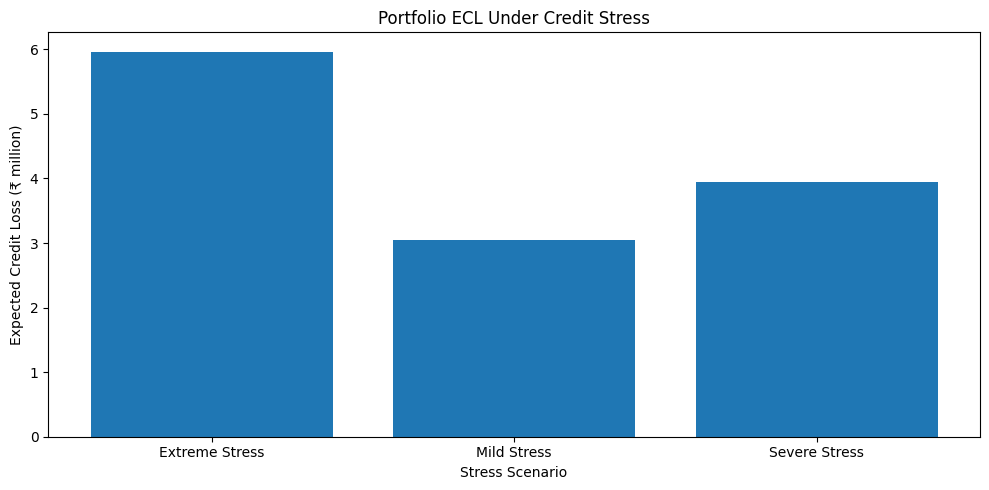

In [681]:
# ============================================================
# CELL 150 — STRESS ECL CHART
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    stress_summary["stress_scenario"],
    stress_summary["total_ecl"] / 1_000_000
)

ax.set_title(
    "Portfolio ECL Under Credit Stress"
)

ax.set_xlabel(
    "Stress Scenario"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.tight_layout()
plt.show()

In [682]:
# ============================================================
# CELL 151 — STRESS ECL BY IFRS 9 STAGE
# ============================================================

stress_by_stage = (
    stress_data_all
    .groupby(
        [
            "stress_scenario",
            "ifrs9_stage"
        ]
    )
    .agg(
        total_ecl=("stress_ecl", "sum"),
        total_ead=("stress_ead", "sum")
    )
    .reset_index()
)

stress_by_stage["ecl_rate"] = (
    stress_by_stage["total_ecl"]
    / stress_by_stage["total_ead"]
)

display(
    stress_by_stage.style.format({
        "total_ecl": "₹{:,.0f}",
        "total_ead": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,stress_scenario,ifrs9_stage,total_ecl,total_ead,ecl_rate
0,Extreme Stress,1,"₹2,711,155","₹243,073,749",1.12%
1,Extreme Stress,2,"₹1,807,950","₹38,443,901",4.70%
2,Extreme Stress,3,"₹1,445,808","₹10,692,870",13.52%
3,Mild Stress,1,"₹1,208,096","₹212,689,531",0.57%
4,Mild Stress,2,"₹814,641","₹33,638,413",2.42%
5,Mild Stress,3,"₹1,030,807","₹9,356,261",11.02%
6,Severe Stress,1,"₹1,656,817","₹222,817,603",0.74%
7,Severe Stress,2,"₹1,116,696","₹35,240,242",3.17%
8,Severe Stress,3,"₹1,178,065","₹9,801,797",12.02%


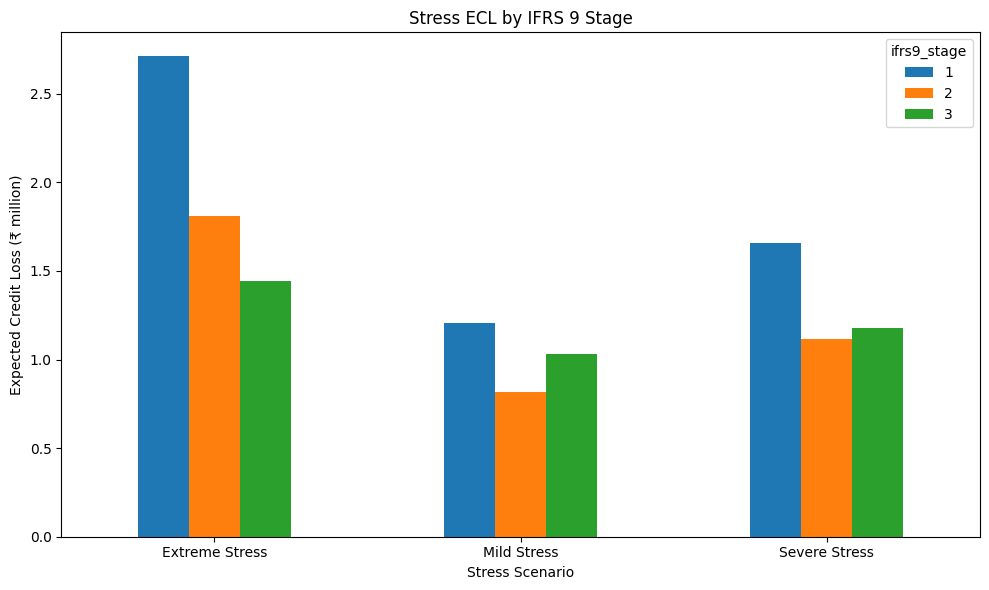

In [683]:
# ============================================================
# CELL 152 — STRESS ECL BY IFRS 9 STAGE
# ============================================================

pivot_stress_stage = stress_by_stage.pivot(
    index="stress_scenario",
    columns="ifrs9_stage",
    values="total_ecl"
)

fig, ax = plt.subplots(figsize=(10, 6))

pivot_stress_stage.div(
    1_000_000
).plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Stress ECL by IFRS 9 Stage"
)

ax.set_xlabel(
    "Stress Scenario"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [684]:
# ============================================================
# CELL 153 — STRESS ECL BY SECTOR
# ============================================================

stress_by_sector = (
    stress_data_all
    .groupby(
        [
            "stress_scenario",
            "sector"
        ]
    )
    .agg(
        total_ecl=("stress_ecl", "sum"),
        total_ead=("stress_ead", "sum")
    )
    .reset_index()
)

stress_by_sector["ecl_rate"] = (
    stress_by_sector["total_ecl"]
    / stress_by_sector["total_ead"]
)

display(
    stress_by_sector.style.format({
        "total_ecl": "₹{:,.0f}",
        "total_ead": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,stress_scenario,sector,total_ecl,total_ead,ecl_rate
0,Extreme Stress,Healthcare,"₹1,137,925","₹57,852,954",1.97%
1,Extreme Stress,Manufacturing,"₹1,448,448","₹58,949,344",2.46%
2,Extreme Stress,Retail,"₹1,285,539","₹57,050,761",2.25%
3,Extreme Stress,Services,"₹984,348","₹59,533,282",1.65%
4,Extreme Stress,Technology,"₹1,108,653","₹58,824,179",1.88%
5,Mild Stress,Healthcare,"₹590,612","₹50,621,335",1.17%
6,Mild Stress,Manufacturing,"₹724,090","₹51,580,676",1.40%
7,Mild Stress,Retail,"₹671,135","₹49,919,416",1.34%
8,Mild Stress,Services,"₹517,728","₹52,091,622",0.99%
9,Mild Stress,Technology,"₹549,979","₹51,471,156",1.07%


In [685]:
# ============================================================
# CELL 154 — SEVERE STRESS BY SECTOR
# ============================================================

severe_sector = (
    stress_by_sector[
        stress_by_sector["stress_scenario"]
        == "Severe Stress"
    ]
    .sort_values(
        "total_ecl",
        ascending=False
    )
)

display(
    severe_sector.style.format({
        "total_ecl": "₹{:,.0f}",
        "total_ead": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,stress_scenario,sector,total_ecl,total_ead,ecl_rate
11,Severe Stress,Manufacturing,"₹947,782","₹54,036,899",1.75%
12,Severe Stress,Retail,"₹861,914","₹52,296,531",1.65%
10,Severe Stress,Healthcare,"₹759,056","₹53,031,875",1.43%
14,Severe Stress,Technology,"₹720,987","₹53,922,164",1.34%
13,Severe Stress,Services,"₹661,840","₹54,572,175",1.21%


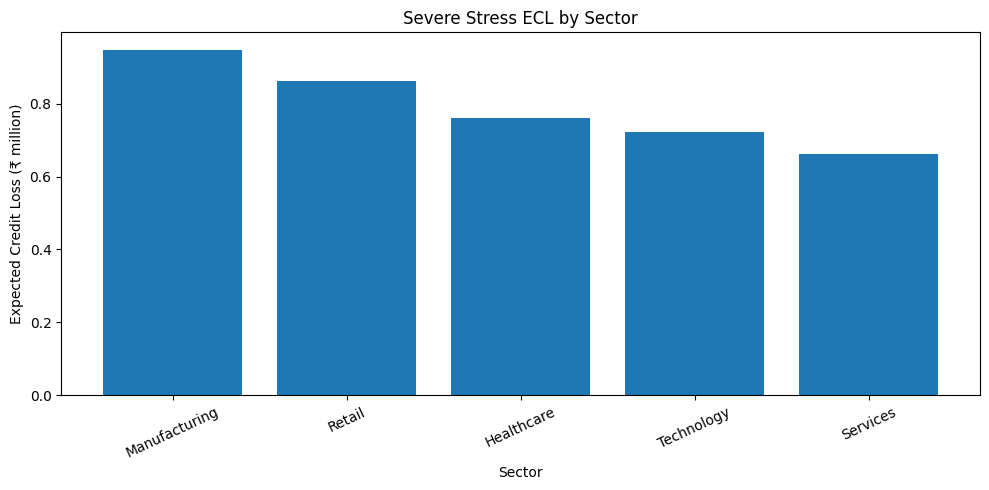

In [686]:
# ============================================================
# CELL 155 — SEVERE STRESS ECL BY SECTOR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    severe_sector["sector"],
    severe_sector["total_ecl"] / 1_000_000
)

ax.set_title(
    "Severe Stress ECL by Sector"
)

ax.set_xlabel(
    "Sector"
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)"
)

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [687]:
# ============================================================
# CELL 156 — ECL CONCENTRATION ANALYSIS
# ============================================================

concentration = severe_sector.copy()

total_severe_ecl = (
    concentration["total_ecl"].sum()
)

concentration["ecl_contribution"] = (
    concentration["total_ecl"]
    / total_severe_ecl
)

concentration["cumulative_ecl_contribution"] = (
    concentration["ecl_contribution"]
    .cumsum()
)

display(
    concentration[
        [
            "sector",
            "total_ecl",
            "ecl_contribution",
            "cumulative_ecl_contribution"
        ]
    ].style.format({
        "total_ecl": "₹{:,.0f}",
        "ecl_contribution": "{:.2%}",
        "cumulative_ecl_contribution": "{:.2%}"
    })
)

,sector,total_ecl,ecl_contribution,cumulative_ecl_contribution
11,Manufacturing,"₹947,782",23.98%,23.98%
12,Retail,"₹861,914",21.81%,45.80%
10,Healthcare,"₹759,056",19.21%,65.01%
14,Technology,"₹720,987",18.25%,83.25%
13,Services,"₹661,840",16.75%,100.00%


In [688]:
# ============================================================
# CELL 157 — TOP RISK CONTRIBUTORS
# ============================================================

top_risk_sectors = (
    concentration
    .head(3)
)

print("Top 3 sectors by severe-stress ECL:")

display(
    top_risk_sectors[
        [
            "sector",
            "total_ecl",
            "ecl_contribution"
        ]
    ].style.format({
        "total_ecl": "₹{:,.0f}",
        "ecl_contribution": "{:.2%}"
    })
)

Top 3 sectors by severe-stress ECL:


,sector,total_ecl,ecl_contribution
11,Manufacturing,"₹947,782",23.98%
12,Retail,"₹861,914",21.81%
10,Healthcare,"₹759,056",19.21%


In [689]:
# ============================================================
# CELL 158 — STRESS-TEST VALIDATION
# ============================================================

print("=" * 60)
print("STRESS-TEST VALIDATION")
print("=" * 60)

missing_stress_ecl = (
    stress_data_all["stress_ecl"]
    .isna()
    .sum()
)

negative_stress_ecl = (
    stress_data_all["stress_ecl"] < 0
).sum()

invalid_stress_pd = (
    (
        stress_data_all["stress_pd"] < 0
    )
    |
    (
        stress_data_all["stress_pd"] > 1
    )
).sum()

invalid_stress_lgd = (
    (
        stress_data_all["stress_lgd"] < 0
    )
    |
    (
        stress_data_all["stress_lgd"] > 1
    )
).sum()

print(
    "Missing stress ECL values:",
    missing_stress_ecl
)

print(
    "Negative stress ECL values:",
    negative_stress_ecl
)

print(
    "Invalid stress PD values:",
    invalid_stress_pd
)

print(
    "Invalid stress LGD values:",
    invalid_stress_lgd
)

if (
    missing_stress_ecl == 0
    and negative_stress_ecl == 0
    and invalid_stress_pd == 0
    and invalid_stress_lgd == 0
):
    print()
    print("✓ Stress-test validation passed.")
else:
    print()
    print("⚠ Stress-test validation requires review.")

STRESS-TEST VALIDATION
Missing stress ECL values: 0
Negative stress ECL values: 0
Invalid stress PD values: 0
Invalid stress LGD values: 0

✓ Stress-test validation passed.


In [690]:
# ============================================================
# CELL 159 — SAVE STRESS-TEST RESULTS
# ============================================================

stress_data_all.to_csv(
    "credit_stress_test_loan_results.csv",
    index=False
)

stress_summary.to_csv(
    "credit_stress_test_summary.csv",
    index=False
)

stress_by_stage.to_csv(
    "credit_stress_test_by_stage.csv",
    index=False
)

stress_by_sector.to_csv(
    "credit_stress_test_by_sector.csv",
    index=False
)

print("Stress-test results saved successfully.")

Stress-test results saved successfully.


In [691]:
# ============================================================
# CELL 160 — FINAL RISK SUMMARY
# ============================================================

print("=" * 60)
print("PORTFOLIO CREDIT RISK SUMMARY")
print("=" * 60)

print(
    f"Base ECL: ₹{base_ecl:,.0f}"
)

for scenario in [
    "Mild Stress",
    "Severe Stress",
    "Extreme Stress"
]:

    scenario_ecl = stress_summary.loc[
        stress_summary["stress_scenario"] == scenario,
        "total_ecl"
    ].iloc[0]

    increase = (
        scenario_ecl / base_ecl - 1
    )

    print(
        f"{scenario}: "
        f"₹{scenario_ecl:,.0f} "
        f"({increase:+.2%} vs Base)"
    )

print()

print(
    "✓ Portfolio stress testing completed."
)

PORTFOLIO CREDIT RISK SUMMARY
Base ECL: ₹2,293,504
Mild Stress: ₹3,053,544 (+33.14% vs Base)
Severe Stress: ₹3,951,579 (+72.29% vs Base)
Extreme Stress: ₹5,964,913 (+160.08% vs Base)

✓ Portfolio stress testing completed.


In [692]:
# ============================================================
# CELL 161 — FINAL PORTFOLIO METRICS
# ============================================================

# Core portfolio metrics
total_loans = len(ecl_data)

total_exposure = ecl_data["current_exposure"].sum()

total_ead = ecl_data["ead"].sum()

total_ecl = ecl_data["expected_credit_loss"].sum()

portfolio_ecl_rate = (
    total_ecl / total_ead
)

default_count = (
    ecl_data["actual_default"] == 1
).sum()

default_rate = (
    ecl_data["actual_default"].mean()
)

stage_1_count = (
    ecl_data["ifrs9_stage"] == 1
).sum()

stage_2_count = (
    ecl_data["ifrs9_stage"] == 2
).sum()

stage_3_count = (
    ecl_data["ifrs9_stage"] == 3
).sum()

print("=" * 65)
print("FINAL CREDIT RISK PORTFOLIO METRICS")
print("=" * 65)

print(f"Total Loans:              {total_loans:,}")
print(f"Current Exposure:         ₹{total_exposure:,.0f}")
print(f"Total EAD:                ₹{total_ead:,.0f}")
print(f"Total Expected Loss:      ₹{total_ecl:,.0f}")
print(f"Portfolio ECL Rate:       {portfolio_ecl_rate:.2%}")
print(f"Default Count:            {default_count:,}")
print(f"Default Rate:             {default_rate:.2%}")

print()
print("IFRS 9 STAGE DISTRIBUTION")
print("-" * 65)

print(f"Stage 1:                  {stage_1_count:,}")
print(f"Stage 2:                  {stage_2_count:,}")
print(f"Stage 3:                  {stage_3_count:,}")

print()
print("✓ Portfolio metrics calculated successfully.")

FINAL CREDIT RISK PORTFOLIO METRICS
Total Loans:              6,000
Current Exposure:         ₹231,913,111
Total EAD:                ₹243,508,767
Total Expected Loss:      ₹2,293,504
Portfolio ECL Rate:       0.94%
Default Count:            233
Default Rate:             3.88%

IFRS 9 STAGE DISTRIBUTION
-----------------------------------------------------------------
Stage 1:                  4,998
Stage 2:                  769
Stage 3:                  233

✓ Portfolio metrics calculated successfully.


In [693]:
# ============================================================
# CELL 162 — IFRS 9 STAGE DISTRIBUTION
# ============================================================

stage_distribution = pd.DataFrame({
    "Stage": [
        "Stage 1",
        "Stage 2",
        "Stage 3"
    ],

    "Loans": [
        stage_1_count,
        stage_2_count,
        stage_3_count
    ]
})

stage_distribution["Percentage"] = (
    stage_distribution["Loans"]
    / total_loans
)

display(
    stage_distribution.style.format({
        "Percentage": "{:.2%}"
    })
)

,Stage,Loans,Percentage
0,Stage 1,4998,83.30%
1,Stage 2,769,12.82%
2,Stage 3,233,3.88%


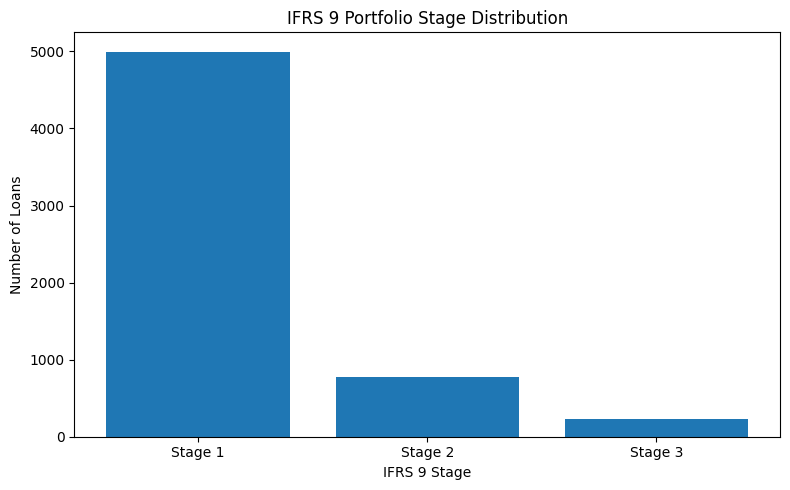

In [694]:
# ============================================================
# CELL 163 — IFRS 9 STAGE DISTRIBUTION CHART
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    stage_distribution["Stage"],
    stage_distribution["Loans"]
)

ax.set_title(
    "IFRS 9 Portfolio Stage Distribution"
)

ax.set_xlabel(
    "IFRS 9 Stage"
)

ax.set_ylabel(
    "Number of Loans"
)

plt.tight_layout()
plt.show()

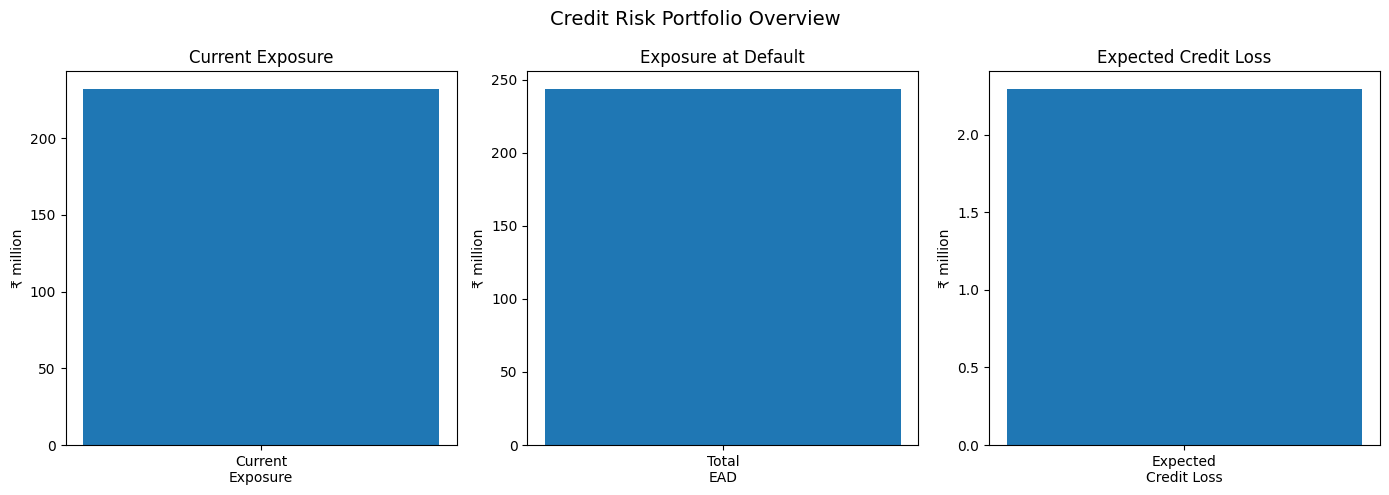

In [695]:
# ============================================================
# CELL 164 — ECL EXECUTIVE DASHBOARD
# ============================================================

# ECL is much smaller than total exposure/EAD.
# Therefore, we display the three metrics separately.

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5)
)

# Current Exposure
axes[0].bar(
    ["Current\nExposure"],
    [total_exposure / 1_000_000]
)

axes[0].set_title(
    "Current Exposure"
)

axes[0].set_ylabel(
    "₹ million"
)

# Total EAD
axes[1].bar(
    ["Total\nEAD"],
    [total_ead / 1_000_000]
)

axes[1].set_title(
    "Exposure at Default"
)

axes[1].set_ylabel(
    "₹ million"
)

# Expected Credit Loss
axes[2].bar(
    ["Expected\nCredit Loss"],
    [total_ecl / 1_000_000]
)

axes[2].set_title(
    "Expected Credit Loss"
)

axes[2].set_ylabel(
    "₹ million"
)

fig.suptitle(
    "Credit Risk Portfolio Overview",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [696]:
# ============================================================
# CELL 165 — FINAL ECL BY IFRS 9 STAGE
# ============================================================

final_ecl_stage = (
    ecl_data
    .groupby("ifrs9_stage")
    .agg(
        loans=("expected_credit_loss", "count"),
        ead=("ead", "sum"),
        ecl=("expected_credit_loss", "sum")
    )
    .reset_index()
)

final_ecl_stage["ecl_rate"] = (
    final_ecl_stage["ecl"]
    / final_ecl_stage["ead"]
)

display(
    final_ecl_stage.style.format({
        "ead": "₹{:,.0f}",
        "ecl": "₹{:,.0f}",
        "ecl_rate": "{:.2%}"
    })
)

,ifrs9_stage,loans,ead,ecl,ecl_rate
0,1,4998,"₹202,561,458","₹836,776",0.41%
1,2,769,"₹32,036,584","₹564,253",1.76%
2,3,233,"₹8,910,725","₹892,474",10.02%


In [697]:
# ============================================================
# CELL 166 — FINAL STRESS COMPARISON
# ============================================================

final_stress = stress_summary[
    [
        "stress_scenario",
        "total_ecl",
        "increase_vs_base"
    ]
].copy()

display(
    final_stress.style.format({
        "total_ecl": "₹{:,.0f}",
        "increase_vs_base": "{:+.2%}"
    })
)

,stress_scenario,total_ecl,increase_vs_base
0,Extreme Stress,"₹5,964,913",+160.08%
1,Mild Stress,"₹3,053,544",+33.14%
2,Severe Stress,"₹3,951,579",+72.29%


In [698]:
# ============================================================
# CELL 167 — HIGHEST RISK SECTOR
# ============================================================

# Identify the sector contributing the most ECL
# under the Severe Stress scenario.

highest_risk_sector = (
    concentration
    .sort_values(
        "total_ecl",
        ascending=False
    )
    .iloc[0]
)

print("=" * 60)
print("HIGHEST RISK SECTOR UNDER SEVERE STRESS")
print("=" * 60)

print(
    f"Sector: {highest_risk_sector['sector']}"
)

print(
    f"Severe Stress ECL: "
    f"₹{highest_risk_sector['total_ecl']:,.0f}"
)

print(
    f"ECL Contribution: "
    f"{highest_risk_sector['ecl_contribution']:.2%}"
)

HIGHEST RISK SECTOR UNDER SEVERE STRESS
Sector: Manufacturing
Severe Stress ECL: ₹947,782
ECL Contribution: 23.98%


In [699]:
# ============================================================
# CELL 168 — FINAL MODEL VALIDATION SUMMARY
# ============================================================

print("=" * 65)
print("MODEL VALIDATION SUMMARY")
print("=" * 65)

print("PD Model:")
print("✓ Logistic regression developed")
print("✓ ROC-AUC evaluated")
print("✓ Gini evaluated")
print("✓ KS statistic evaluated")
print("✓ Brier score evaluated")
print("✓ Calibration evaluated")

print()
print("LGD Model:")
print("✓ Recovery rate calculated")
print("✓ LGD calculated")
print("✓ LGD range validated")
print("✓ Missing values checked")

print()
print("EAD Model:")
print("✓ Current exposure calculated")
print("✓ Credit limit estimated")
print("✓ Undrawn commitment calculated")
print("✓ CCF applied")
print("✓ EAD validated")

print()
print("ECL Model:")
print("✓ PD × LGD × EAD calculated")
print("✓ Stage-specific treatment applied")
print("✓ Portfolio ECL calculated")
print("✓ Scenario analysis completed")
print("✓ Stress testing completed")

print()
print("✓ Model validation review completed.")

MODEL VALIDATION SUMMARY
PD Model:
✓ Logistic regression developed
✓ ROC-AUC evaluated
✓ Gini evaluated
✓ KS statistic evaluated
✓ Brier score evaluated
✓ Calibration evaluated

LGD Model:
✓ Recovery rate calculated
✓ LGD calculated
✓ LGD range validated
✓ Missing values checked

EAD Model:
✓ Current exposure calculated
✓ Credit limit estimated
✓ Undrawn commitment calculated
✓ CCF applied
✓ EAD validated

ECL Model:
✓ PD × LGD × EAD calculated
✓ Stage-specific treatment applied
✓ Portfolio ECL calculated
✓ Scenario analysis completed
✓ Stress testing completed

✓ Model validation review completed.


In [700]:
# ============================================================
# CELL 169 — MODEL LIMITATIONS
# ============================================================

limitations = [
    "Portfolio data is synthetically generated.",
    "SICR classification is a simplified educational proxy.",
    "LGD uses a collateral-based recovery assumption.",
    "EAD uses a synthetic credit-limit and CCF assumption.",
    "Stage 3 ECL uses a simplified credit-impaired treatment.",
    "Macroeconomic scenarios use assumed PD/LGD multipliers.",
    "The model does not use actual bank historical loss data.",
    "The model is intended for educational and portfolio-analysis purposes."
]

print("=" * 65)
print("MODEL LIMITATIONS")
print("=" * 65)

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

MODEL LIMITATIONS
1. Portfolio data is synthetically generated.
2. SICR classification is a simplified educational proxy.
3. LGD uses a collateral-based recovery assumption.
4. EAD uses a synthetic credit-limit and CCF assumption.
5. Stage 3 ECL uses a simplified credit-impaired treatment.
6. Macroeconomic scenarios use assumed PD/LGD multipliers.
7. The model does not use actual bank historical loss data.
8. The model is intended for educational and portfolio-analysis purposes.


In [701]:
# ============================================================
# CELL 170 — FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("IFRS 9 EXPECTED CREDIT LOSS ENGINE")
print("=" * 70)

print()
print("PROJECT OBJECTIVE")
print("-" * 70)

print(
    "Develop a Python-based credit risk engine that estimates "
    "Expected Credit Loss under a simplified IFRS 9 framework."
)

print()
print("CORE COMPONENTS")
print("-" * 70)

print("1. Probability of Default (PD)")
print("2. IFRS 9 Stage Classification")
print("3. Loss Given Default (LGD)")
print("4. Exposure at Default (EAD)")
print("5. Expected Credit Loss (ECL)")
print("6. Forward-Looking Scenarios")
print("7. Portfolio Stress Testing")

print()
print("FINAL PORTFOLIO RESULTS")
print("-" * 70)

print(f"Loans:               {total_loans:,}")
print(f"Current Exposure:    ₹{total_exposure:,.0f}")
print(f"EAD:                 ₹{total_ead:,.0f}")
print(f"ECL:                 ₹{total_ecl:,.0f}")
print(f"ECL Rate:            {portfolio_ecl_rate:.2%}")

print()
print("✓ PROJECT ENGINE COMPLETED")

IFRS 9 EXPECTED CREDIT LOSS ENGINE

PROJECT OBJECTIVE
----------------------------------------------------------------------
Develop a Python-based credit risk engine that estimates Expected Credit Loss under a simplified IFRS 9 framework.

CORE COMPONENTS
----------------------------------------------------------------------
1. Probability of Default (PD)
2. IFRS 9 Stage Classification
3. Loss Given Default (LGD)
4. Exposure at Default (EAD)
5. Expected Credit Loss (ECL)
6. Forward-Looking Scenarios
7. Portfolio Stress Testing

FINAL PORTFOLIO RESULTS
----------------------------------------------------------------------
Loans:               6,000
Current Exposure:    ₹231,913,111
EAD:                 ₹243,508,767
ECL:                 ₹2,293,504
ECL Rate:            0.94%

✓ PROJECT ENGINE COMPLETED


In [702]:
# ============================================================
# CELL 171 — EXPORT FINAL RESULTS
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Total Loans",
        "Current Exposure",
        "Total EAD",
        "Expected Credit Loss",
        "ECL Rate",
        "Default Rate",
        "Stage 1 Loans",
        "Stage 2 Loans",
        "Stage 3 Loans"
    ],

    "Value": [
        total_loans,
        total_exposure,
        total_ead,
        total_ecl,
        portfolio_ecl_rate,
        default_rate,
        stage_1_count,
        stage_2_count,
        stage_3_count
    ]
})

final_results.to_csv(
    "IFRS9_ECL_Final_Portfolio_Summary.csv",
    index=False
)

print(
    "Final portfolio summary exported successfully."
)

Final portfolio summary exported successfully.


# IFRS 9 Expected Credit Loss (ECL) Credit Risk Engine

## Project Overview

This project develops a Python-based credit risk engine to estimate Expected Credit Loss (ECL) under a simplified IFRS 9 framework.

The model covers the complete credit-risk workflow:

1. Probability of Default (PD) modelling
2. IFRS 9 Stage 1, Stage 2 and Stage 3 classification
3. Loss Given Default (LGD) estimation
4. Exposure at Default (EAD) estimation
5. Expected Credit Loss calculation
6. Forward-looking economic scenarios
7. Portfolio credit stress testing
8. Portfolio and sector-level risk analysis

## Core ECL Framework

ECL is estimated using:

ECL = PD × LGD × EAD

The project applies:

- Stage 1 → 12-month ECL
- Stage 2 → Lifetime ECL
- Stage 3 → Credit-impaired treatment

The portfolio is also evaluated under optimistic, base, downside and severe stress scenarios.

## Important Note

This project uses a synthetic loan portfolio and simplified modelling assumptions for educational and portfolio-risk analysis purposes. It is not intended to represent a production banking IFRS 9 implementation.

# Methodology

## 1. Probability of Default (PD)

A logistic regression model is used to estimate the probability that a borrower will default.

Key borrower characteristics include:

- Credit score
- Debt-to-income ratio
- Income
- Loan amount
- Employment history
- Loan term
- Interest rate
- Loan-to-value ratio

Model performance is evaluated using:

- ROC-AUC
- Gini coefficient
- KS statistic
- Brier score
- Precision
- Recall
- F1 score
- Calibration analysis

## 2. IFRS 9 Staging

Borrowers are classified into three simplified IFRS 9 stages:

### Stage 1
Borrowers without a significant increase in credit risk.

12-month ECL is applied.

### Stage 2
Borrowers showing a significant increase in credit risk.

Lifetime ECL is applied.

### Stage 3
Credit-impaired/defaulted borrowers.

A simplified credit-impaired ECL treatment is applied.

## 3. LGD

Loss Given Default is estimated using collateral value and a collateral haircut.

LGD represents the percentage of exposure expected to be lost after considering estimated recoveries.

## 4. EAD

Exposure at Default is estimated using:

EAD = Current Exposure + CCF × Undrawn Commitment

A synthetic credit limit and CCF assumption are used because the project uses a synthetic dataset.

## 5. Expected Credit Loss

The simplified ECL calculation is:

ECL = PD × LGD × EAD

Stage-specific PD treatment is applied before calculating ECL.

## 6. Forward-Looking Scenarios

ECL is evaluated under:

- Optimistic scenario
- Base scenario
- Downside scenario

Scenario probabilities are then used to calculate probability-weighted ECL.

## 7. Stress Testing

The portfolio is tested under:

- Mild Stress
- Severe Stress
- Extreme Stress

PD, LGD and EAD are stressed simultaneously to estimate the potential increase in credit losses.

In [703]:
# ============================================================
# CELL 172 — FINAL PROJECT RESULTS
# ============================================================

print("=" * 70)
print("FINAL PROJECT RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# PORTFOLIO METRICS
# ------------------------------------------------------------

final_total_loans = len(ecl_data)

final_total_exposure = (
    ecl_data["current_exposure"].sum()
)

final_total_ead = (
    ecl_data["ead"].sum()
)

final_total_ecl = (
    ecl_data["expected_credit_loss"].sum()
)

final_ecl_rate = (
    final_total_ecl / final_total_ead
)

final_default_rate = (
    ecl_data["actual_default"].mean()
)

print(
    f"Portfolio Size:              "
    f"{final_total_loans:,} loans"
)

print(
    f"Current Exposure:            "
    f"₹{final_total_exposure:,.0f}"
)

print(
    f"Exposure at Default:         "
    f"₹{final_total_ead:,.0f}"
)

print(
    f"Expected Credit Loss:        "
    f"₹{final_total_ecl:,.0f}"
)

print(
    f"Portfolio ECL Rate:          "
    f"{final_ecl_rate:.2%}"
)

print(
    f"Default Rate:                "
    f"{final_default_rate:.2%}"
)

# ------------------------------------------------------------
# STRESS TEST RESULTS
# ------------------------------------------------------------

print()
print("STRESS TEST RESULTS")
print("-" * 70)

for scenario in [
    "Mild Stress",
    "Severe Stress",
    "Extreme Stress"
]:

    result = stress_summary[
        stress_summary["stress_scenario"] == scenario
    ]

    if not result.empty:

        result = result.iloc[0]

        print(
            f"{scenario}: "
            f"₹{result['total_ecl']:,.0f} "
            f"({result['increase_vs_base']:+.2%} vs Base)"
        )

print()
print("✓ Final results generated successfully.")

FINAL PROJECT RESULTS
Portfolio Size:              6,000 loans
Current Exposure:            ₹231,913,111
Exposure at Default:         ₹243,508,767
Expected Credit Loss:        ₹2,293,504
Portfolio ECL Rate:          0.94%
Default Rate:                3.88%

STRESS TEST RESULTS
----------------------------------------------------------------------
Mild Stress: ₹3,053,544 (+33.14% vs Base)
Severe Stress: ₹3,951,579 (+72.29% vs Base)
Extreme Stress: ₹5,964,913 (+160.08% vs Base)

✓ Final results generated successfully.


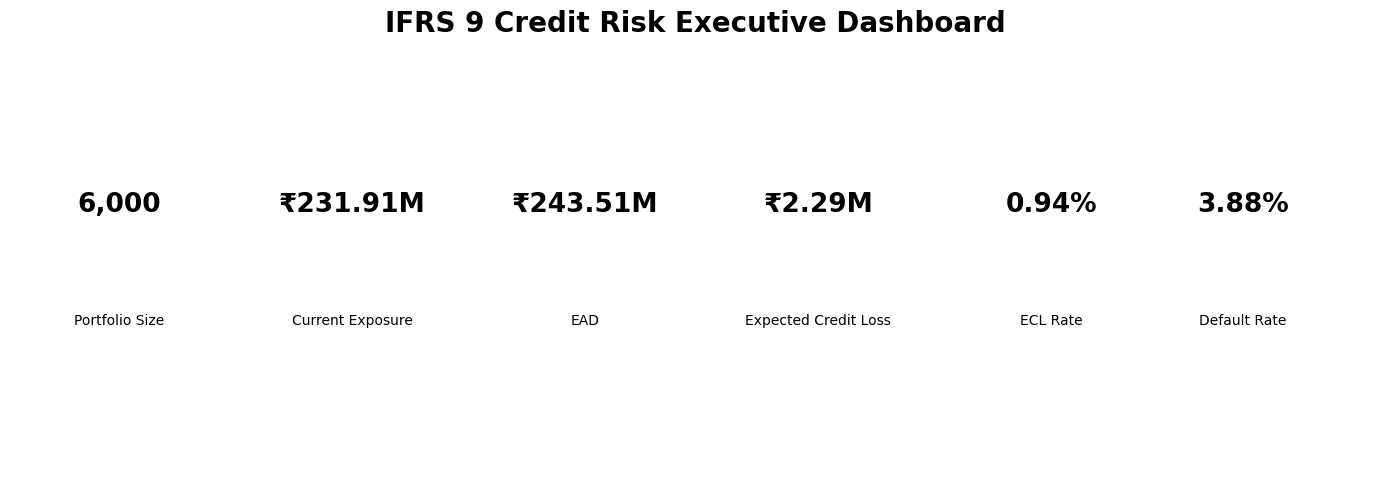

In [704]:
# ============================================================
# CELL 173 — EXECUTIVE CREDIT RISK DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# Core portfolio metrics
portfolio_size = len(ecl_data)

current_exposure = ecl_data["current_exposure"].sum()
total_ead = ecl_data["ead"].sum()
total_ecl = ecl_data["expected_credit_loss"].sum()

ecl_rate = total_ecl / total_ead
default_rate = ecl_data["actual_default"].mean()

# ------------------------------------------------------------
# Dashboard
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.axis("off")

fig.suptitle(
    "IFRS 9 Credit Risk Executive Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.95
)

metrics = [
    ("Portfolio Size", f"{portfolio_size:,}"),
    ("Current Exposure", f"₹{current_exposure/1e6:.2f}M"),
    ("EAD", f"₹{total_ead/1e6:.2f}M"),
    ("Expected Credit Loss", f"₹{total_ecl/1e6:.2f}M"),
    ("ECL Rate", f"{ecl_rate:.2%}"),
    ("Default Rate", f"{default_rate:.2%}")
]

positions = [
    0.08, 0.25, 0.42,
    0.59, 0.76, 0.90
]

for (label, value), x in zip(metrics, positions):

    ax.text(
        x,
        0.62,
        value,
        ha="center",
        va="center",
        fontsize=19,
        fontweight="bold",
        transform=ax.transAxes
    )

    ax.text(
        x,
        0.35,
        label,
        ha="center",
        va="center",
        fontsize=10,
        transform=ax.transAxes
    )

plt.tight_layout()
plt.show()

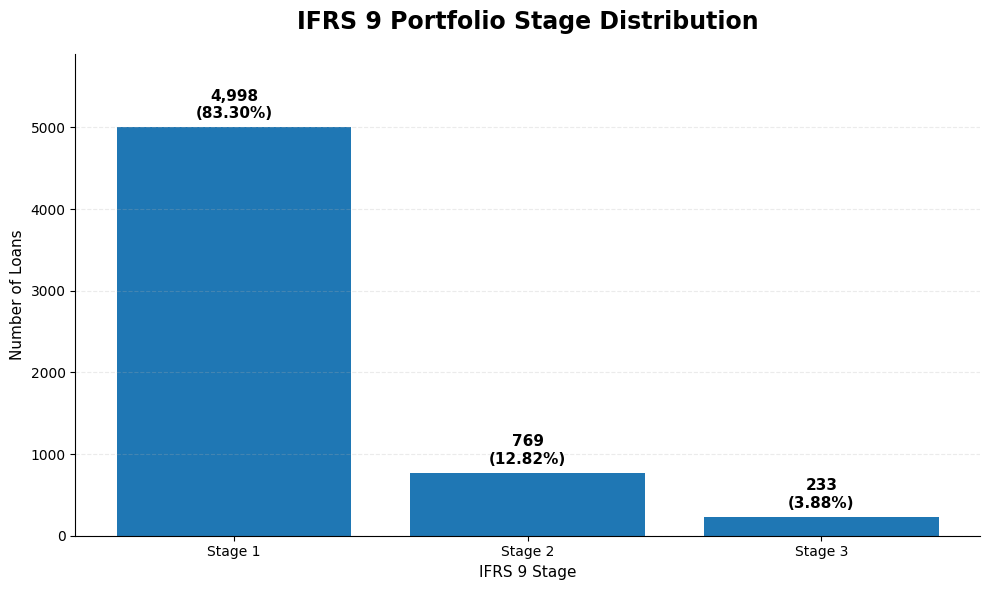

In [705]:
# ============================================================
# CELL 174 — IFRS 9 STAGE RISK PROFILE
# ============================================================

# Calculate stage distribution from the existing staging data
stage_counts = (
    staging_data["ifrs9_stage"]
    .value_counts()
    .reindex([1, 2, 3], fill_value=0)
)

stage_labels = [
    "Stage 1",
    "Stage 2",
    "Stage 3"
]

total_loans = stage_counts.sum()

stage_percentages = (
    stage_counts / total_loans * 100
)

# ------------------------------------------------------------
# VISUAL
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    stage_labels,
    stage_counts.values
)

ax.set_title(
    "IFRS 9 Portfolio Stage Distribution",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "IFRS 9 Stage",
    fontsize=11
)

ax.set_ylabel(
    "Number of Loans",
    fontsize=11
)

# Add loan count and percentage
for bar, count, pct in zip(
    bars,
    stage_counts.values,
    stage_percentages.values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(stage_counts.values) * 0.015,
        f"{int(count):,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_ylim(
    0,
    max(stage_counts.values) * 1.18
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

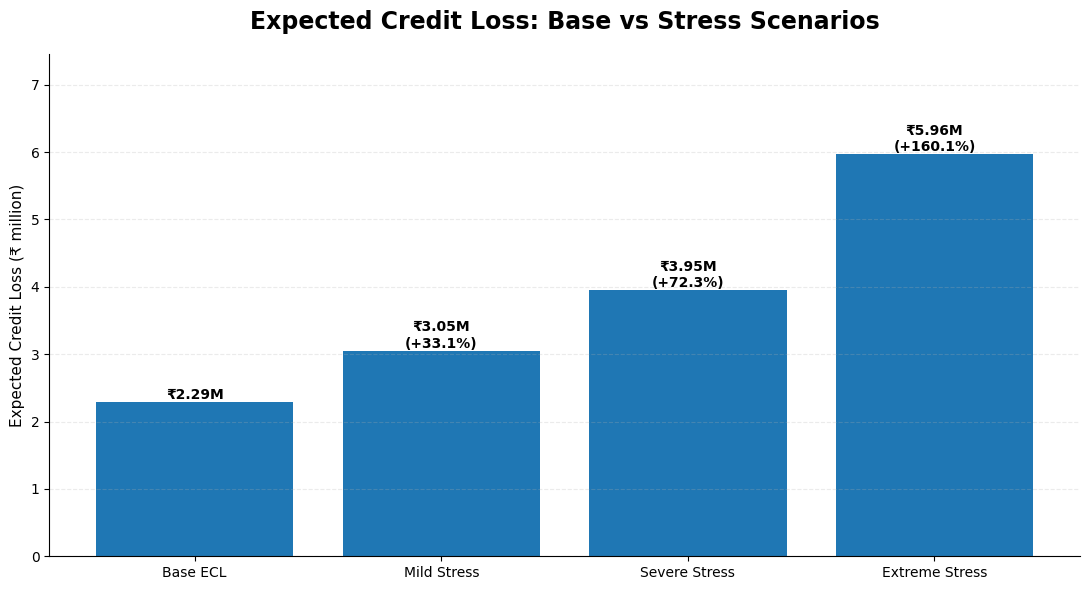

In [706]:
# ============================================================
# CELL 175 — BASE ECL VS STRESS SCENARIOS
# ============================================================

base_ecl = ecl_data["expected_credit_loss"].sum()

# Stress scenarios are alternative scenarios, not cumulative losses
scenario_ecl = stress_summary.set_index(
    "stress_scenario"
)["total_ecl"]

labels = [
    "Base ECL",
    "Mild Stress",
    "Severe Stress",
    "Extreme Stress"
]

values = [
    base_ecl,
    scenario_ecl["Mild Stress"],
    scenario_ecl["Severe Stress"],
    scenario_ecl["Extreme Stress"]
]

values_m = [value / 1_000_000 for value in values]

# Calculate increase relative to base
increases = [
    0,
    (values[1] / base_ecl) - 1,
    (values[2] / base_ecl) - 1,
    (values[3] / base_ecl) - 1
]

# ------------------------------------------------------------
# VISUAL
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    labels,
    values_m
)

ax.set_title(
    "Expected Credit Loss: Base vs Stress Scenarios",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_ylabel(
    "Expected Credit Loss (₹ million)",
    fontsize=11
)

# Add ECL value and increase above each bar
for bar, value, increase in zip(
    bars,
    values_m,
    increases
):

    if increase == 0:
        label = f"₹{value:.2f}M"
    else:
        label = f"₹{value:.2f}M\n(+{increase:.1%})"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylim(
    0,
    max(values_m) * 1.25
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

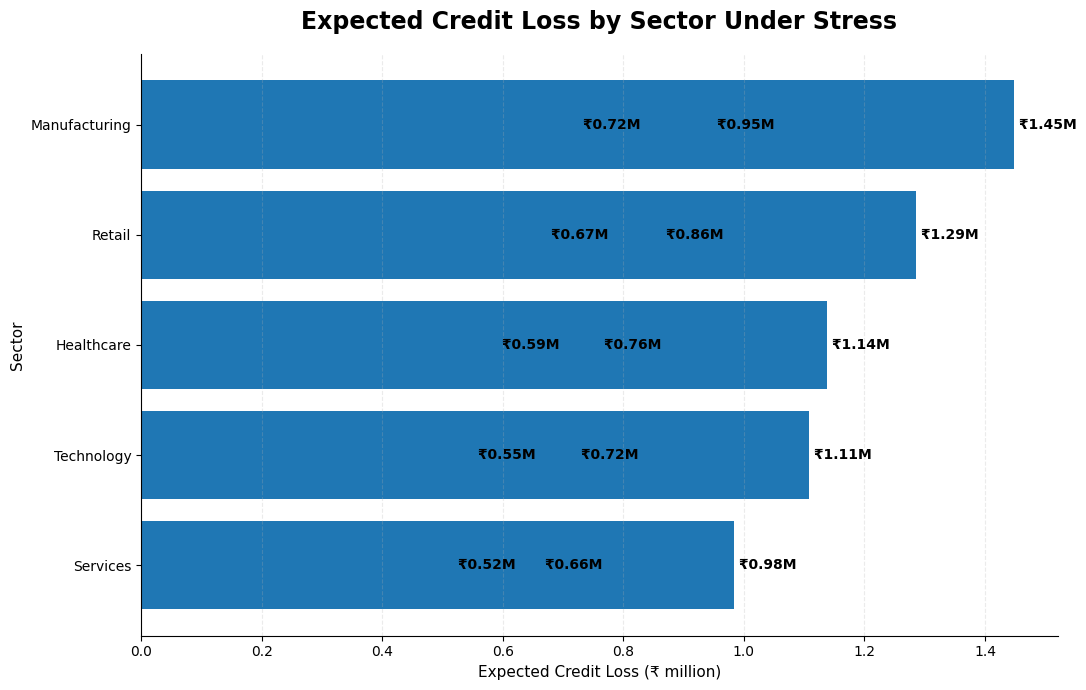

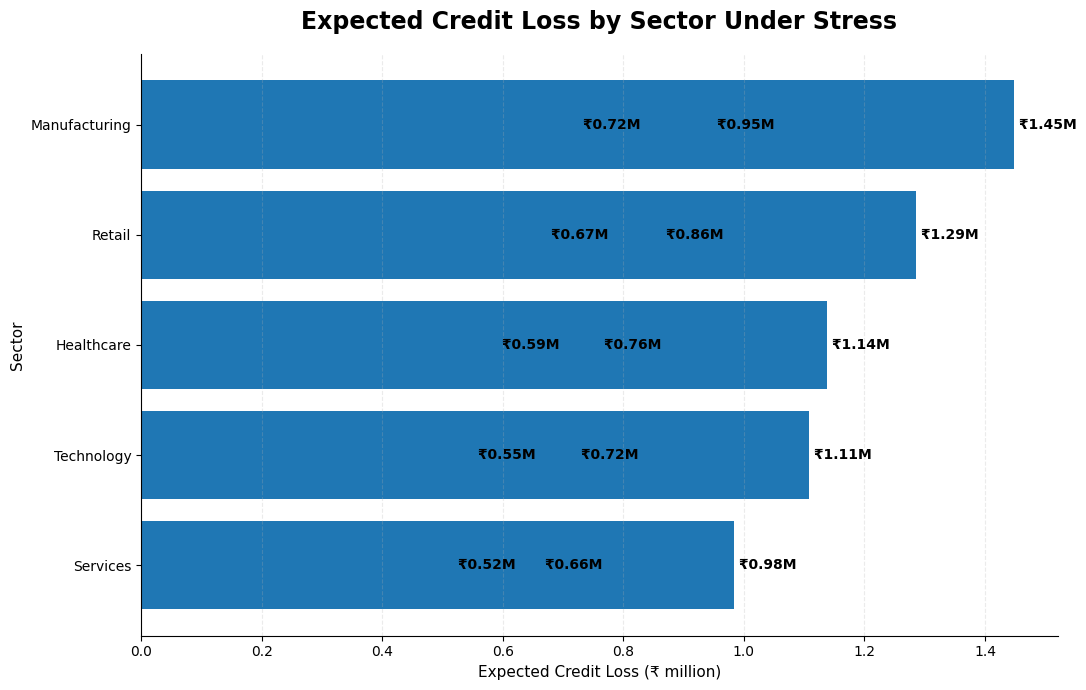

In [707]:
# ============================================================
# CELL 176 — SECTOR STRESS RISK PROFILE
# ============================================================

# Use the existing sector-level stress results
sector_data = stress_by_sector.copy()

# Identify the relevant columns
sector_col = next(
    col for col in sector_data.columns
    if "sector" in col.lower()
)

ecl_col = next(
    col for col in sector_data.columns
    if "ecl" in col.lower()
)

# Sort sectors by stressed ECL
sector_data = sector_data.sort_values(
    ecl_col,
    ascending=True
)

# ------------------------------------------------------------
# VISUAL
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    sector_data[sector_col].astype(str),
    sector_data[ecl_col] / 1_000_000
)

ax.set_title(
    "Expected Credit Loss by Sector Under Stress",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Expected Credit Loss (₹ million)",
    fontsize=11
)

ax.set_ylabel(
    "Sector",
    fontsize=11
)

# Add values
for bar in bars:

    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" ₹{width:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()# ============================================================
# CELL 176 — SECTOR STRESS RISK PROFILE
# ============================================================

# Use the existing sector-level stress results
sector_data = stress_by_sector.copy()

# Identify the relevant columns
sector_col = next(
    col for col in sector_data.columns
    if "sector" in col.lower()
)

ecl_col = next(
    col for col in sector_data.columns
    if "ecl" in col.lower()
)

# Sort sectors by stressed ECL
sector_data = sector_data.sort_values(
    ecl_col,
    ascending=True
)

# ------------------------------------------------------------
# VISUAL
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    sector_data[sector_col].astype(str),
    sector_data[ecl_col] / 1_000_000
)

ax.set_title(
    "Expected Credit Loss by Sector Under Stress",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Expected Credit Loss (₹ million)",
    fontsize=11
)

ax.set_ylabel(
    "Sector",
    fontsize=11
)

# Add values
for bar in bars:

    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" ₹{width:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

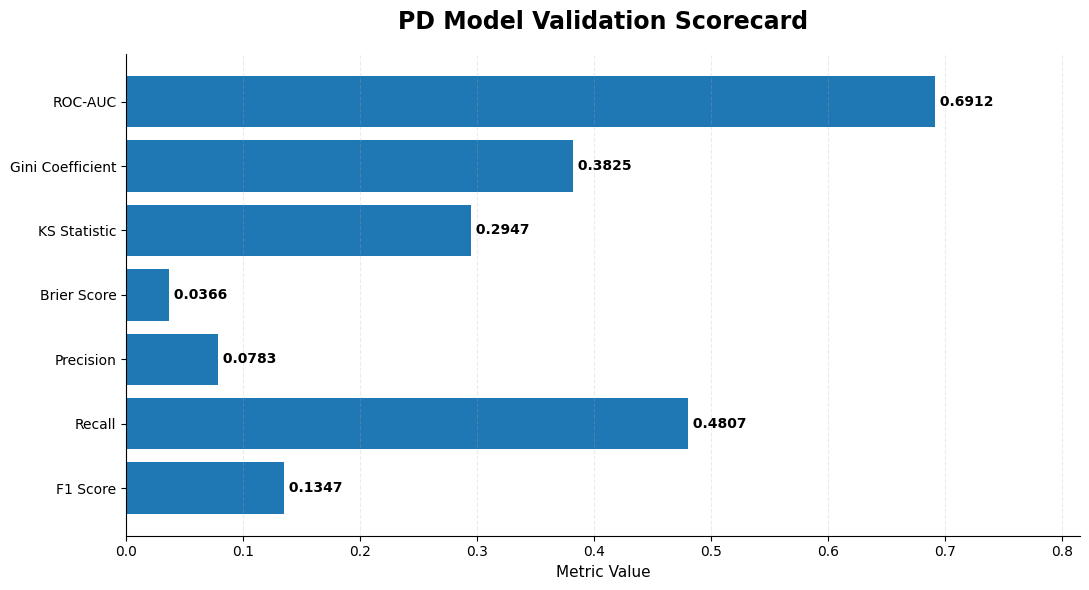

In [708]:
# ============================================================
# CELL 177 — PD MODEL VALIDATION SCORECARD
# ============================================================

# Existing PD model validation metrics
validation_metrics = {
    "ROC-AUC": roc_auc,
    "Gini Coefficient": (2 * roc_auc) - 1,
    "KS Statistic": ks_statistic,
    "Brier Score": brier_score,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_score
}

metrics = list(validation_metrics.keys())
values = list(validation_metrics.values())

# ------------------------------------------------------------
# VISUAL
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    metrics[::-1],
    values[::-1]
)

ax.set_title(
    "PD Model Validation Scorecard",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Metric Value",
    fontsize=11
)

# Add values to bars
for bar, value in zip(
    bars,
    values[::-1]
):

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlim(
    0,
    max(values) * 1.18
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Business Interpretation

## Portfolio Risk

The ECL engine estimates expected credit losses across the loan portfolio using Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD).

The portfolio is evaluated at both overall and IFRS 9 stage levels to identify where expected losses are concentrated.

## IFRS 9 Stage Risk

- **Stage 1:** Loans without a significant increase in credit risk. These exposures receive 12-month ECL treatment.
- **Stage 2:** Loans showing a significant increase in credit risk. These exposures receive lifetime ECL treatment.
- **Stage 3:** Credit-impaired exposures. These represent the highest level of credit deterioration and receive the model's simplified credit-impaired ECL treatment.

Stage 2 is particularly important because moving from 12-month ECL to lifetime ECL can materially increase the expected loss recognized on an exposure.

## Stress Testing

The portfolio is tested under mild, severe and extreme credit-risk scenarios.

The stress framework increases:

- Probability of Default (PD)
- Loss Given Default (LGD)
- Exposure at Default (EAD)

This allows the model to estimate how sensitive portfolio credit losses are to deteriorating credit conditions.

## Sector Risk

Sector-level analysis identifies which sectors contribute most to expected credit losses under severe stress.

This can help identify portfolio concentrations that may require closer monitoring or risk mitigation.

## Management Use

A similar credit-risk framework can support:

- Expected credit loss estimation
- Credit portfolio monitoring
- IFRS 9 stage analysis
- Stress testing
- Sector concentration analysis
- Credit-risk reporting

## Important Interpretation

The results should be interpreted as outputs from an educational quantitative risk model. The portfolio is synthetic and several IFRS 9 components are simplified. Therefore, the results should not be interpreted as actual bank provisioning estimates.

# Model Limitations

This project is designed as an educational quantitative credit-risk prototype. It is not a production banking IFRS 9 accounting system.

## Key Limitations

1. **Synthetic Dataset**

   The loan portfolio is artificially generated for modelling purposes rather than obtained from an actual financial institution.

2. **Simplified SICR Assessment**

   IFRS 9 Stage 2 classification uses simplified credit-risk deterioration rules rather than a complete bank-specific Significant Increase in Credit Risk framework.

3. **Simplified LGD Model**

   LGD is estimated primarily using collateral recovery assumptions. A production model would incorporate historical recoveries, workout costs, recovery timing and discounting.

4. **Simplified EAD Model**

   EAD uses a synthetic credit-limit, undrawn-commitment and Credit Conversion Factor (CCF) framework. Actual institutions would estimate CCFs using historical utilization and facility-specific behaviour.

5. **Simplified Stage 3 Treatment**

   Stage 3 ECL is simplified for educational purposes and does not implement a complete discounted cash-flow recovery model.

6. **Scenario-Based Macroeconomic Analysis**

   Forward-looking scenarios use assumed PD and LGD multipliers rather than statistically estimated relationships between credit losses and macroeconomic variables.

7. **Model Risk**

   The assumptions, synthetic data-generating process and model specifications can materially affect the resulting ECL estimates.

## Conclusion

The project demonstrates the structure of an IFRS 9 credit-risk modelling workflow and the interaction between PD, LGD, EAD, staging, ECL and stress testing.

The results should therefore be interpreted as quantitative research outputs rather than actual financial reporting or regulatory provisioning estimates.